# 0: Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import matplotlib.pyplot as mpl
import seaborn as sns
import copy
from sklearn.datasets import make_classification
%matplotlib inline

# 1: Import Data

In [4]:
patient_data = pd.read_csv(r"C:\Users\Miguel\Desktop\Dr.-House-IACD-main\Dr. House\Projeto final IACD\data\hcc_dataset.csv")

In [5]:
patient_data.head()

,Gender,Symptoms,Alcohol,HBsAg,HBeAg,HBcAb,HCVAb,Cirrhosis,Endemic,Smoking,...,ALP,TP,Creatinine,Nodules,Major_Dim,Dir_Bil,Iron,Sat,Ferritin,Class
0,Male,No,Yes,No,No,No,No,Yes,No,Yes,...,150,7.1,0.7,1,3.5,0.5,?,?,?,Lives
1,Female,?,No,No,No,No,Yes,Yes,?,?,...,?,?,?,1,1.8,?,?,?,?,Lives
2,Male,No,Yes,Yes,No,Yes,No,Yes,No,Yes,...,109,7,2.1,5,13,0.1,28,6,16,Lives
3,Male,Yes,Yes,No,No,No,No,Yes,No,Yes,...,174,8.1,1.11,2,15.7,0.2,?,?,?,Dies
4,Male,Yes,Yes,Yes,No,Yes,No,Yes,No,Yes,...,109,6.9,1.8,1,9,?,59,15,22,Lives


In [6]:
patient_data.shape

(165, 50)

In [9]:
patient_data.columns

Index(['Gender', 'Symptoms', 'Alcohol', 'HBsAg', 'HBeAg', 'HBcAb', 'HCVAb',
       'Cirrhosis', 'Endemic', 'Smoking', 'Diabetes', 'Obesity', 'Hemochro',
       'AHT', 'CRI', 'HIV', 'NASH', 'Varices', 'Spleno', 'PHT', 'PVT',
       'Metastasis', 'Hallmark', 'Age', 'Grams_day', 'Packs_year', 'PS',
       'Encephalopathy', 'Ascites', 'INR', 'AFP', 'Hemoglobin', 'MCV',
       'Leucocytes', 'Platelets', ' Albumin', 'Total_Bil', 'ALT', 'AST', 'GGT',
       'ALP', 'TP', 'Creatinine', 'Nodules', 'Major_Dim', 'Dir_Bil', 'Iron',
       'Sat', 'Ferritin', 'Class'],
      dtype='object')

In [10]:
numbers_data = patient_data[["Age", "Grams_day", "Packs_year", "INR", "AFP", "Hemoglobin", "MCV", "Leucocytes", "Platelets", " Albumin", "Total_Bil", "ALT", "AST", "GGT", "ALP", "TP", "Creatinine", "Nodules", "Major_Dim", "Dir_Bil", "Iron", "Sat", "Ferritin"]]
string_data = patient_data[["Gender", "Symptoms", "Alcohol", "HBsAg", "HBeAg", "HBcAb", "HCVAb", "Cirrhosis", 'Endemic', 'Smoking', 'Diabetes', 'Obesity',
       'Hemochro', 'AHT', 'CRI', 'HIV', 'NASH', 'Varices', 'Spleno', 'PHT',
       'PVT', 'Metastasis', 'Hallmark', "PS", 'Encephalopathy', 'Ascites', "Class"]]

In [11]:
pd.set_option('display.max_columns', None)
numbers_data.head()

,Age,Grams_day,Packs_year,INR,AFP,Hemoglobin,MCV,Leucocytes,Platelets,Albumin,Total_Bil,ALT,AST,GGT,ALP,TP,Creatinine,Nodules,Major_Dim,Dir_Bil,Iron,Sat,Ferritin
0,67,137,15,1.53,95,13.7,106.6,4.9,99,3.4,2.1,34,41,183,150,7.1,0.7,1,3.5,0.5,?,?,?
1,62,0,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,1,1.8,?,?,?,?
2,78,50,50,0.96,5.8,8.9,79.8,8.4,472,3.3,0.4,58,68,202,109,7,2.1,5,13,0.1,28,6,16
3,77,40,30,0.95,2440,13.4,97.1,9,279,3.7,0.4,16,64,94,174,8.1,1.11,2,15.7,0.2,?,?,?
4,76,100,30,0.94,49,14.3,95.1,6.4,199,4.1,0.7,147,306,173,109,6.9,1.8,1,9,?,59,15,22


In [12]:
nf = pd.DataFrame(numbers_data)

In [13]:
nf = nf.replace('?', np.nan)

In [14]:
nf = nf.astype(float)
nf_clean = copy.deepcopy(nf)
for column in nf_clean.columns:
    mean_value = nf_clean[column].mean()
    print(f"Mean of {column}: {mean_value}")
    nf_clean[column].fillna(mean_value, inplace=True)
int_columns = nf_clean[["Age","Grams_day", "Packs_year", "AFP", "Platelets", "ALT", "AST", "GGT", "ALP", "Nodules", "Iron", "Sat", "Ferritin"]]
float_columns = nf_clean[["INR","Hemoglobin", "MCV", "Leucocytes"," Albumin", "Total_Bil","TP", "Creatinine","Major_Dim", "Dir_Bil",]]

#Convert columns to int
for col in int_columns:
    nf_clean[col] = nf_clean[col].astype(int)

#Convert columns to float
for col in float_columns:
    nf_clean[col] = nf_clean[col].astype(float)
nf_clean.head()

Mean of Age: 64.69090909090909
Mean of Grams_day: 71.00854700854701
Mean of Packs_year: 20.464285714285715
Mean of INR: 1.4218509316770187
Mean of AFP: 19299.951146496816
Mean of Hemoglobin: 12.87901234567901
Mean of MCV: 95.11975308641975
Mean of Leucocytes: 1473.9615493827162
Mean of Platelets: 113206.442654321
Mean of  Albumin: 3.445534591194968
Mean of Total_Bil: 3.0879375000000002
Mean of ALT: 67.09316770186335
Mean of AST: 96.38271604938272
Mean of GGT: 268.02654320987654
Mean of ALP: 212.2116049382716
Mean of TP: 8.96103896103896
Mean of Creatinine: 1.1270886075949367
Mean of Nodules: 2.736196319018405
Mean of Major_Dim: 6.851172413793104
Mean of Dir_Bil: 1.9300000000000002
Mean of Iron: 85.59883720930233
Mean of Sat: 37.02894117647059
Mean of Ferritin: 438.9976470588236


KeyError: "['Albumin'] not in index"

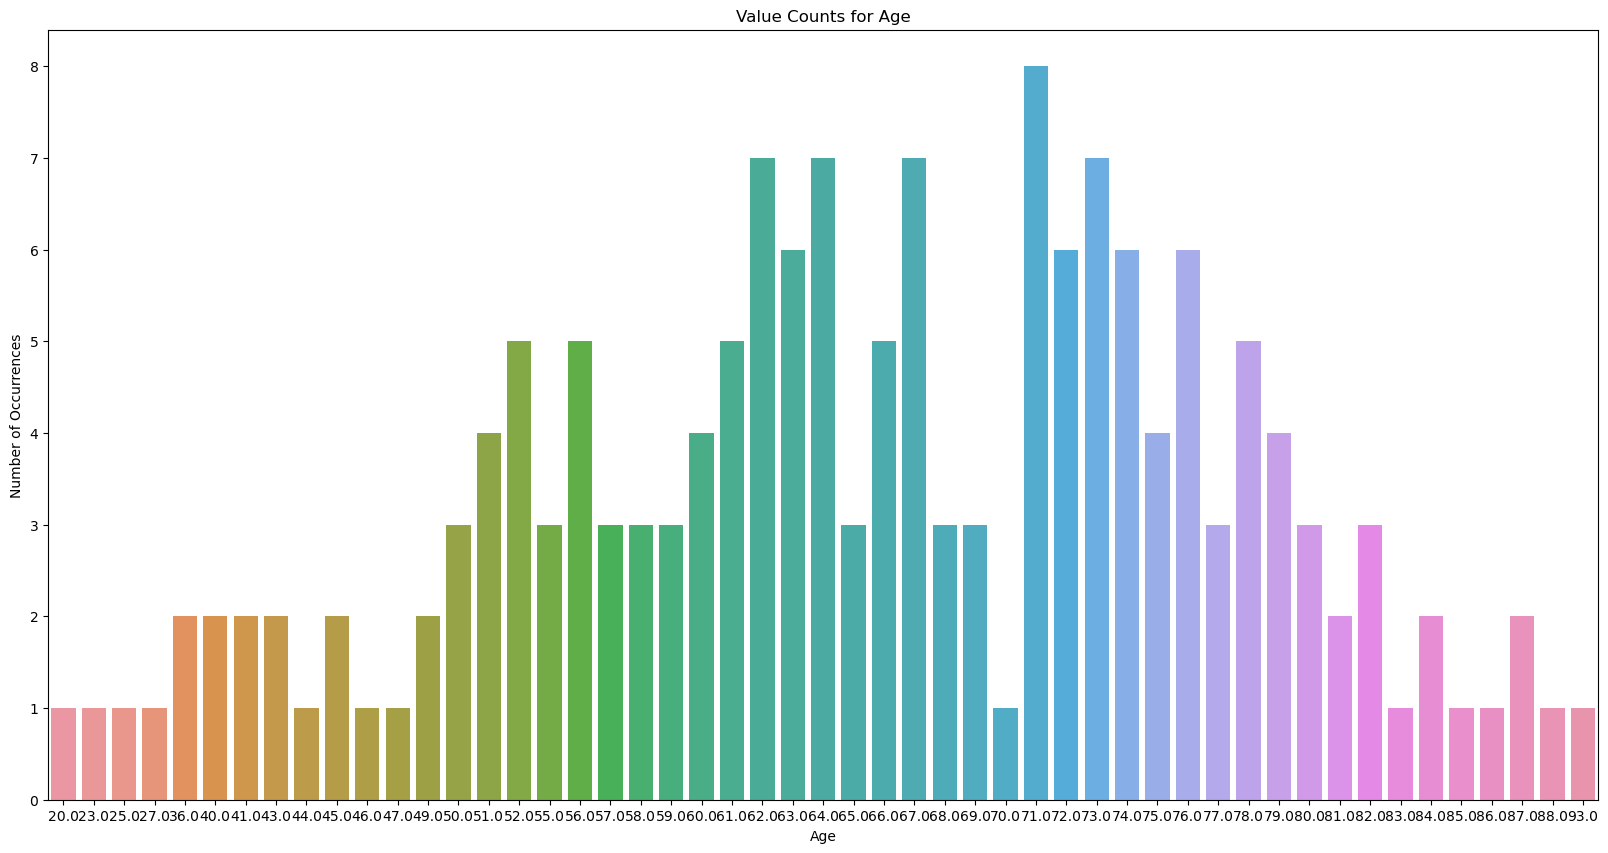

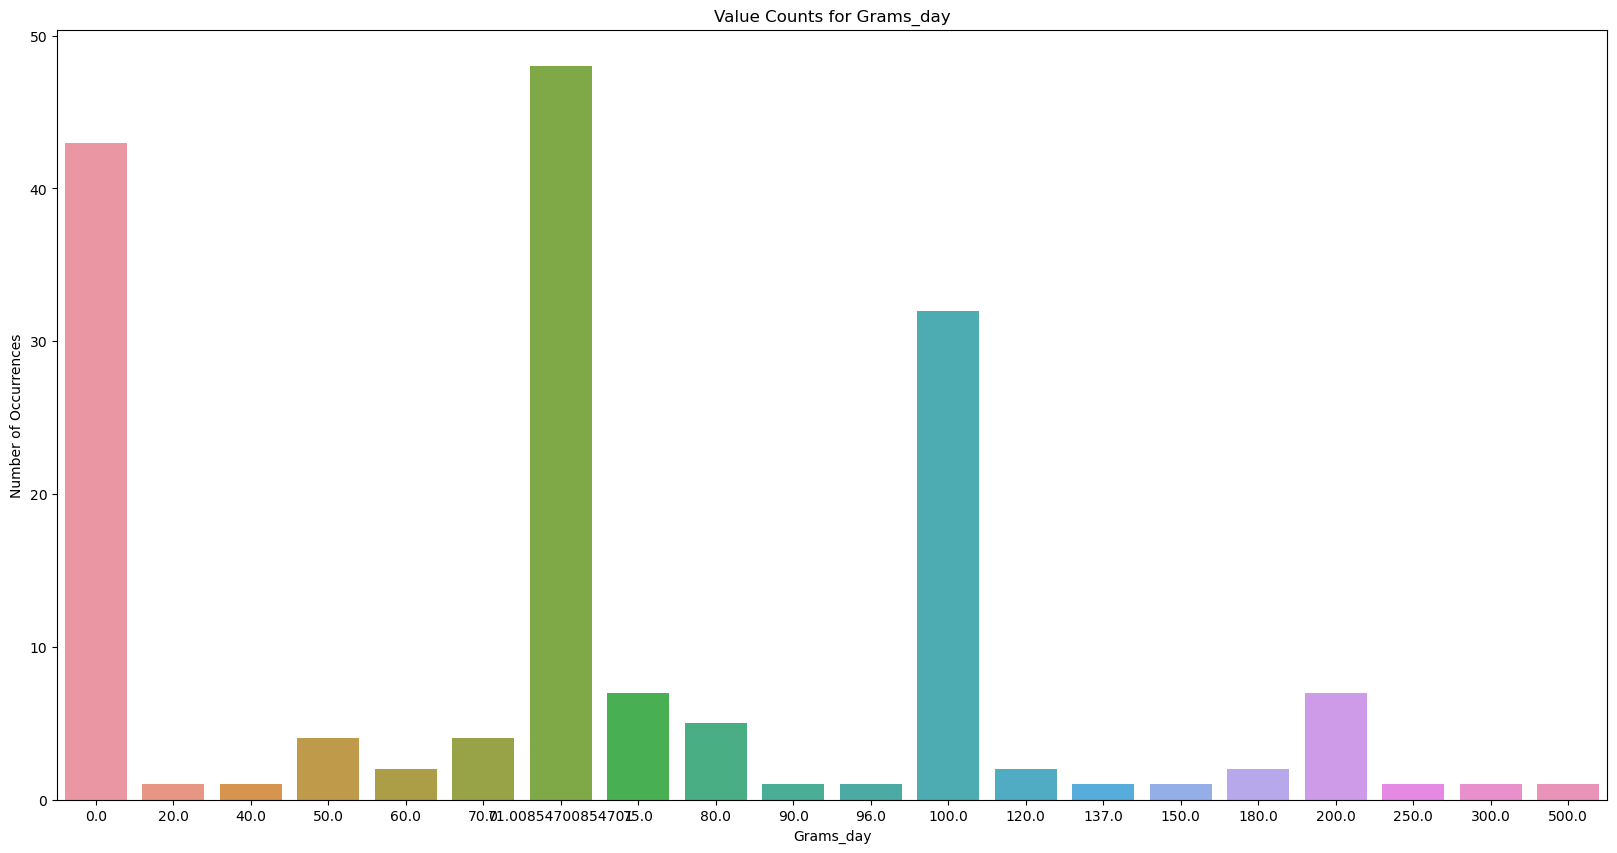

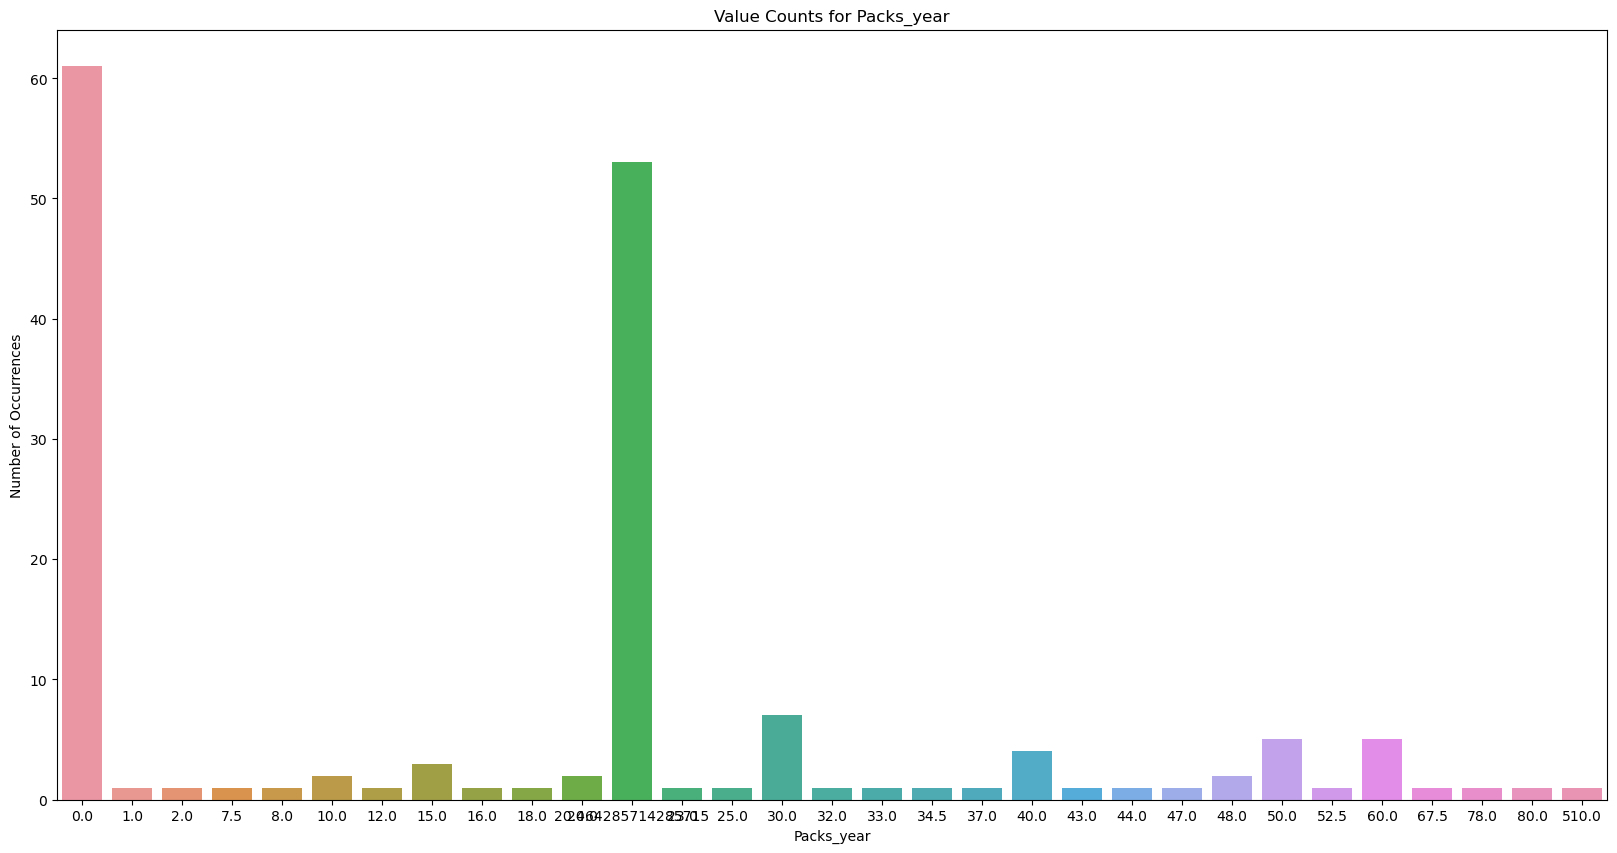

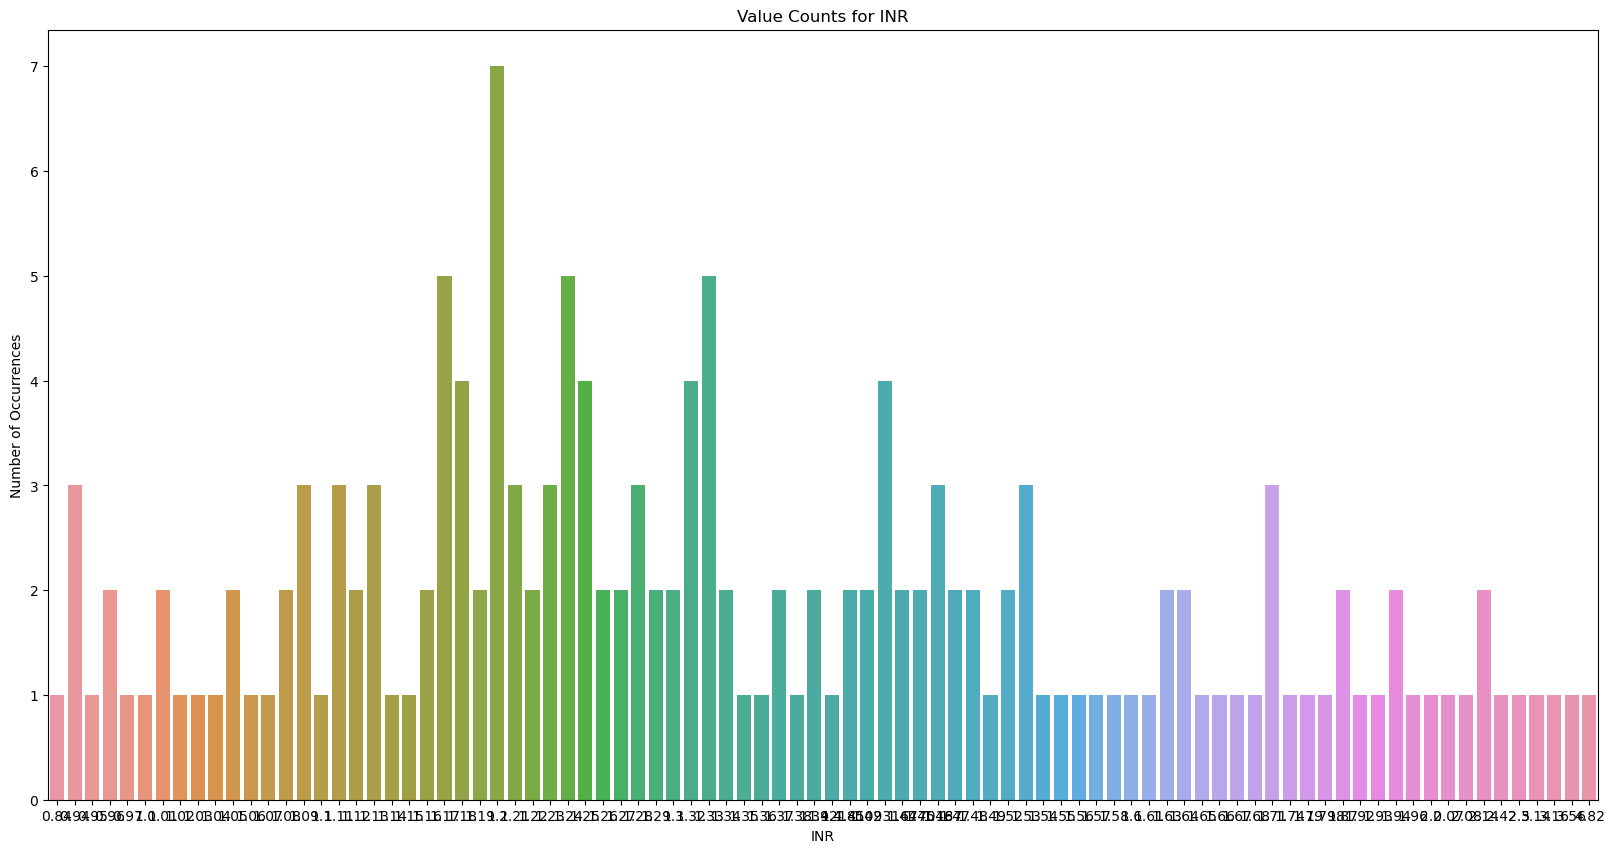

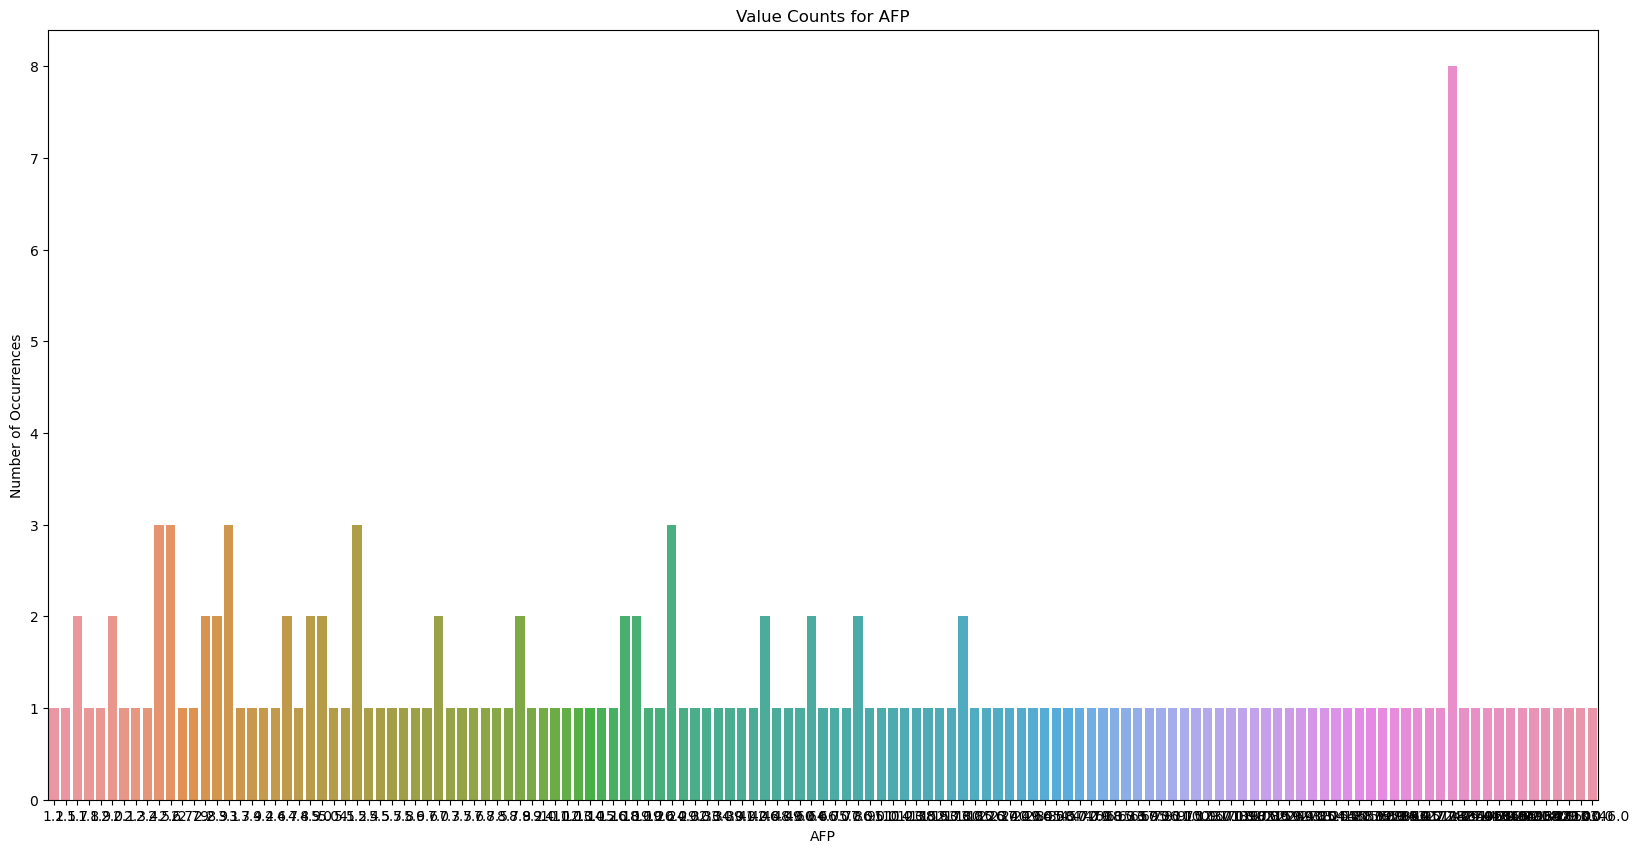

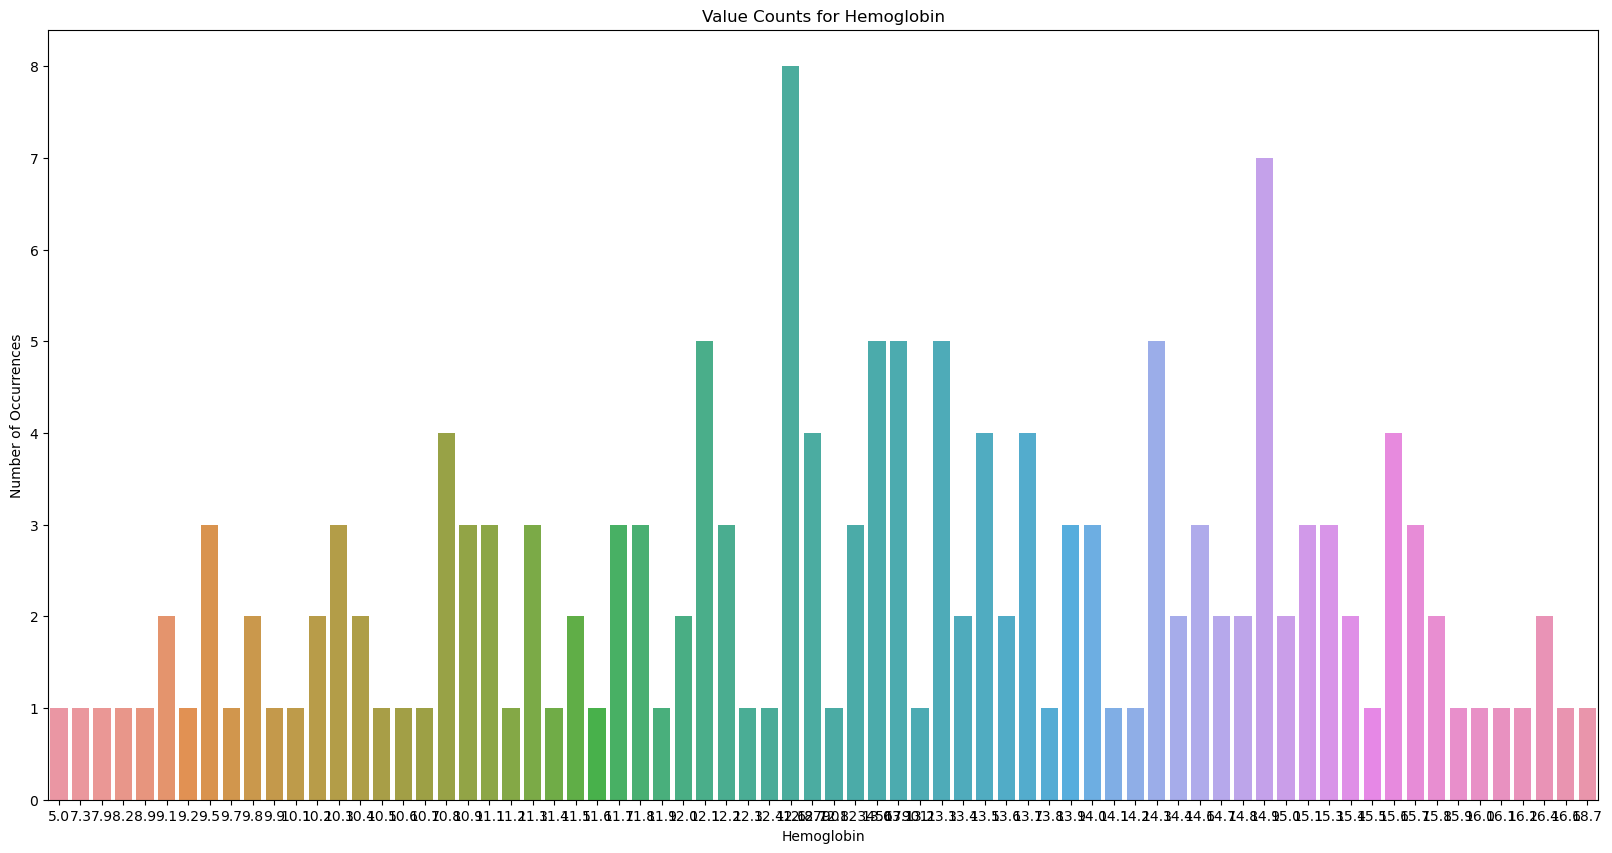

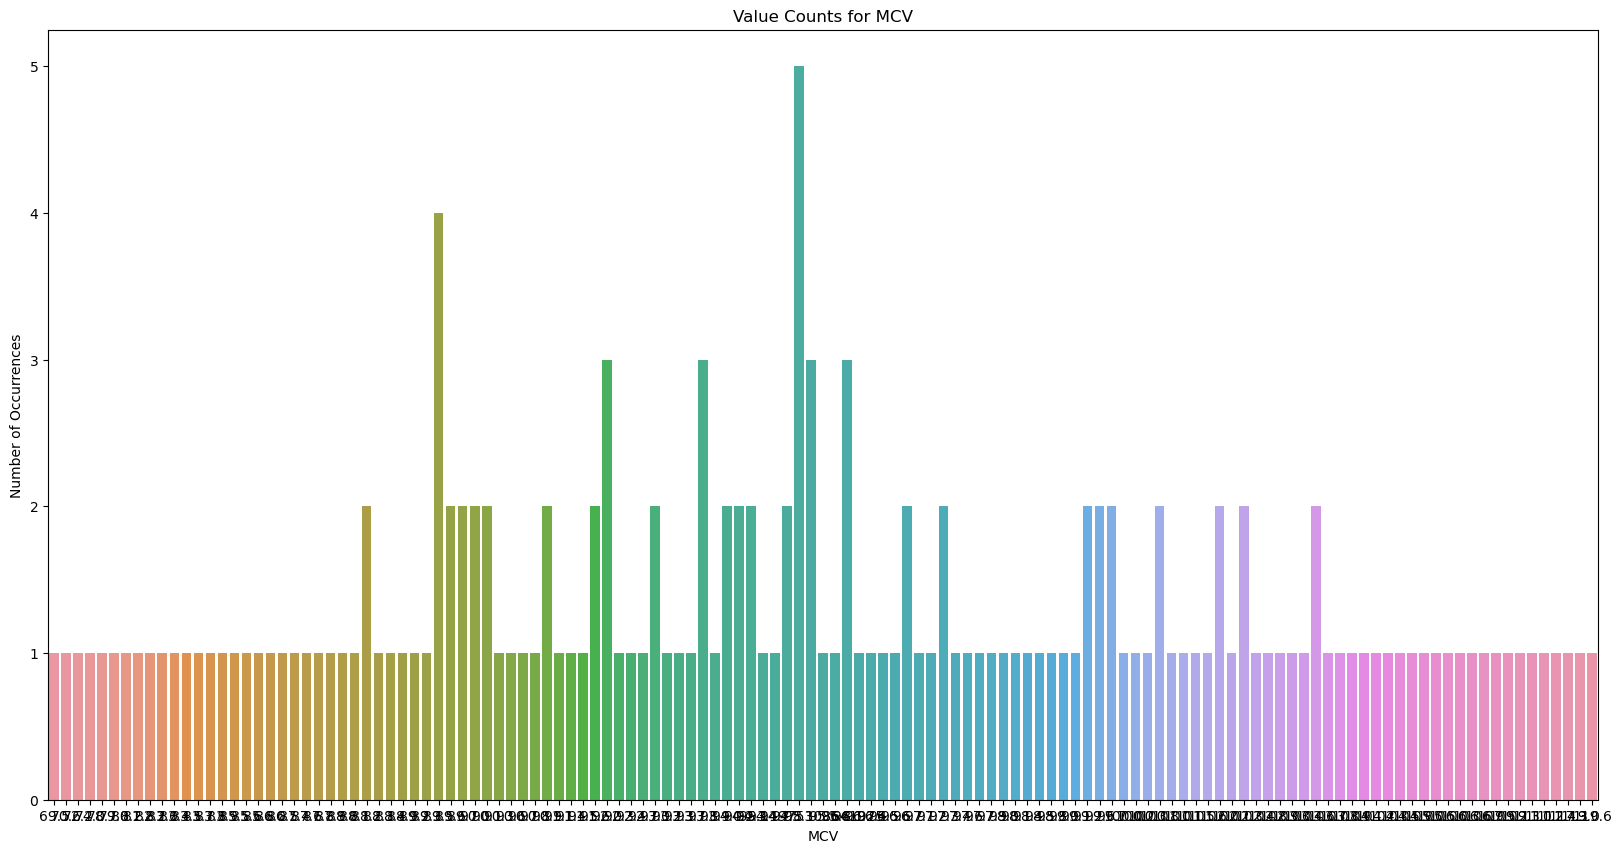

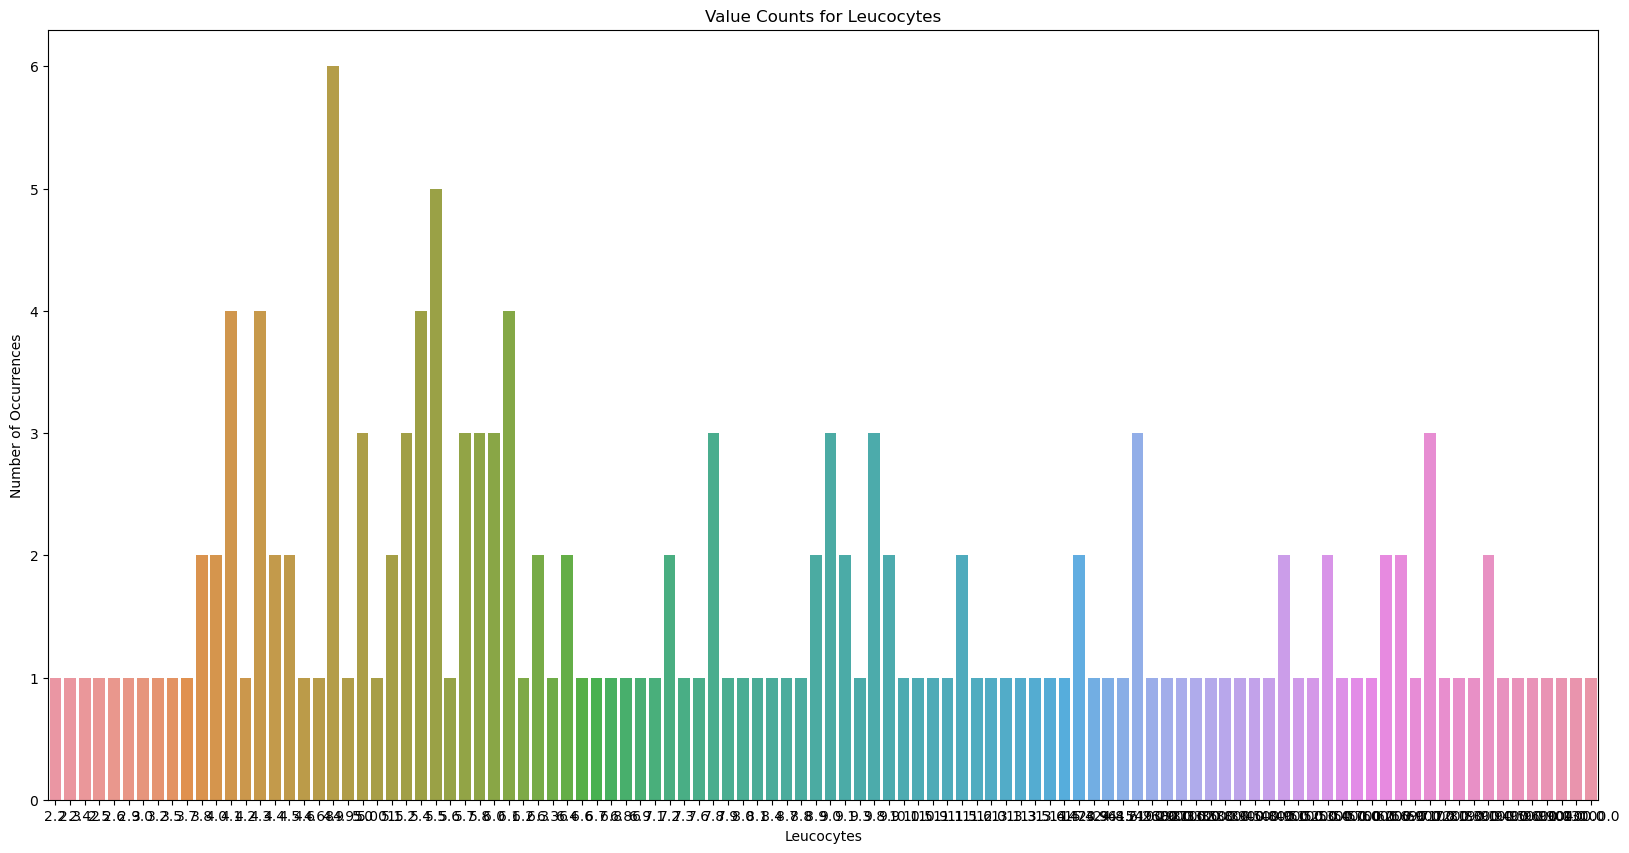

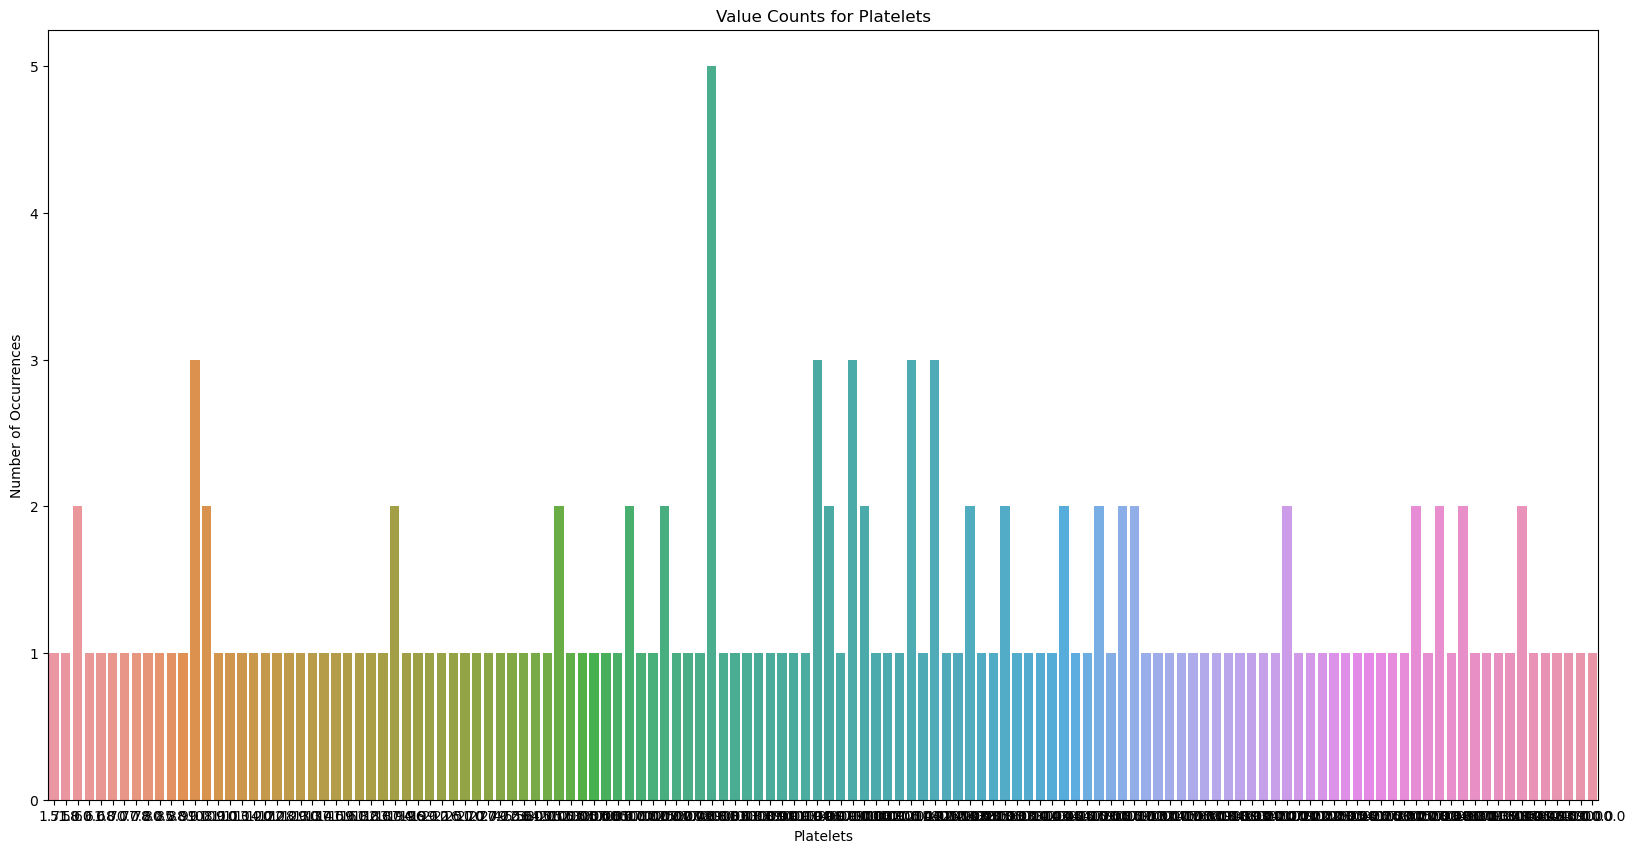

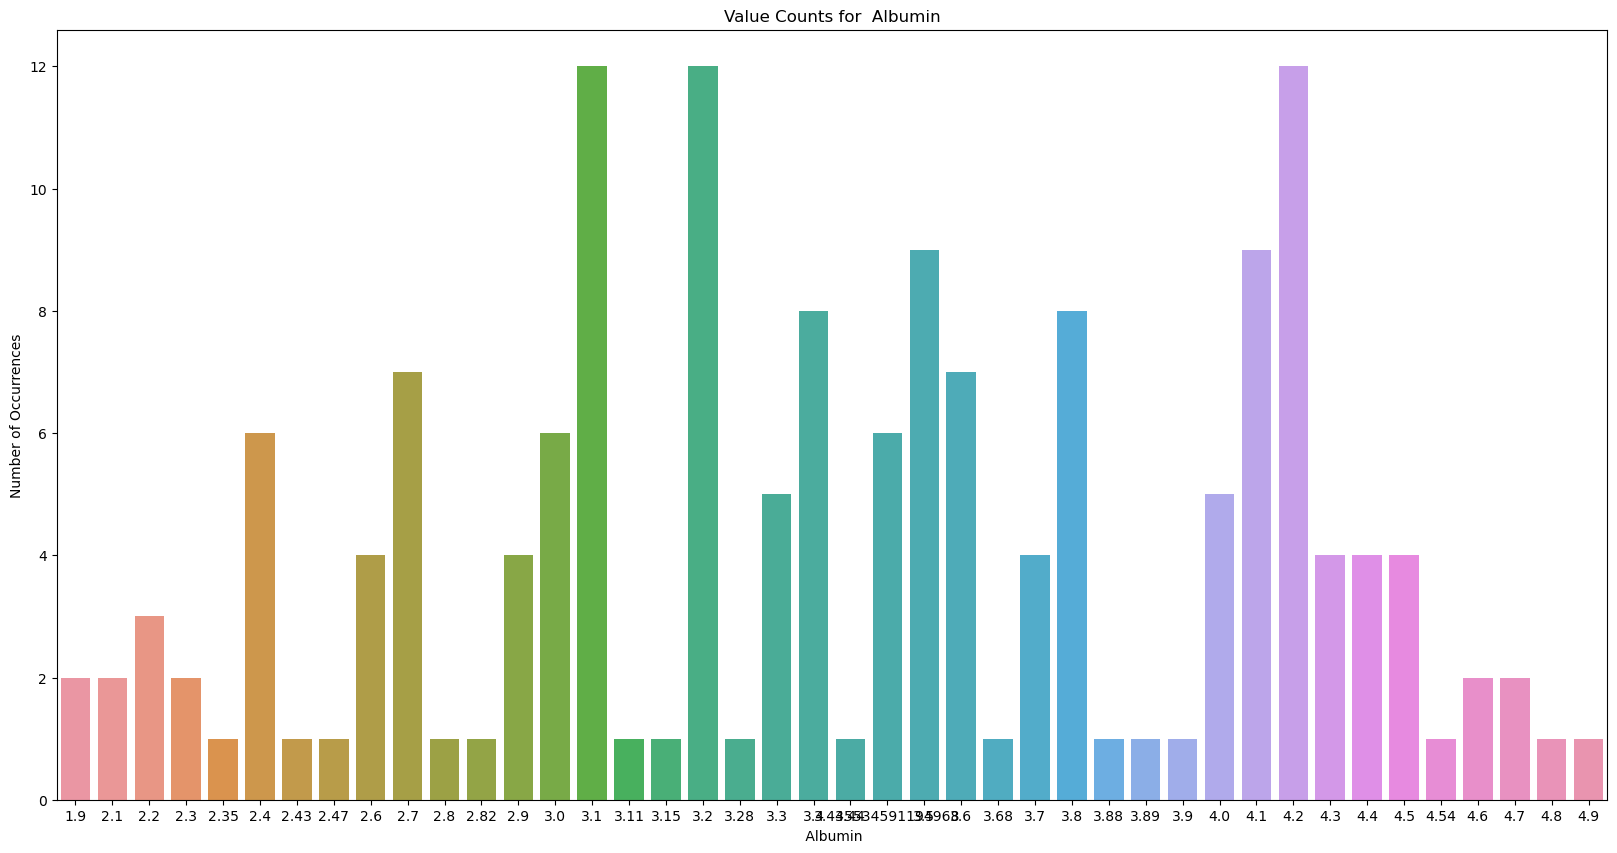

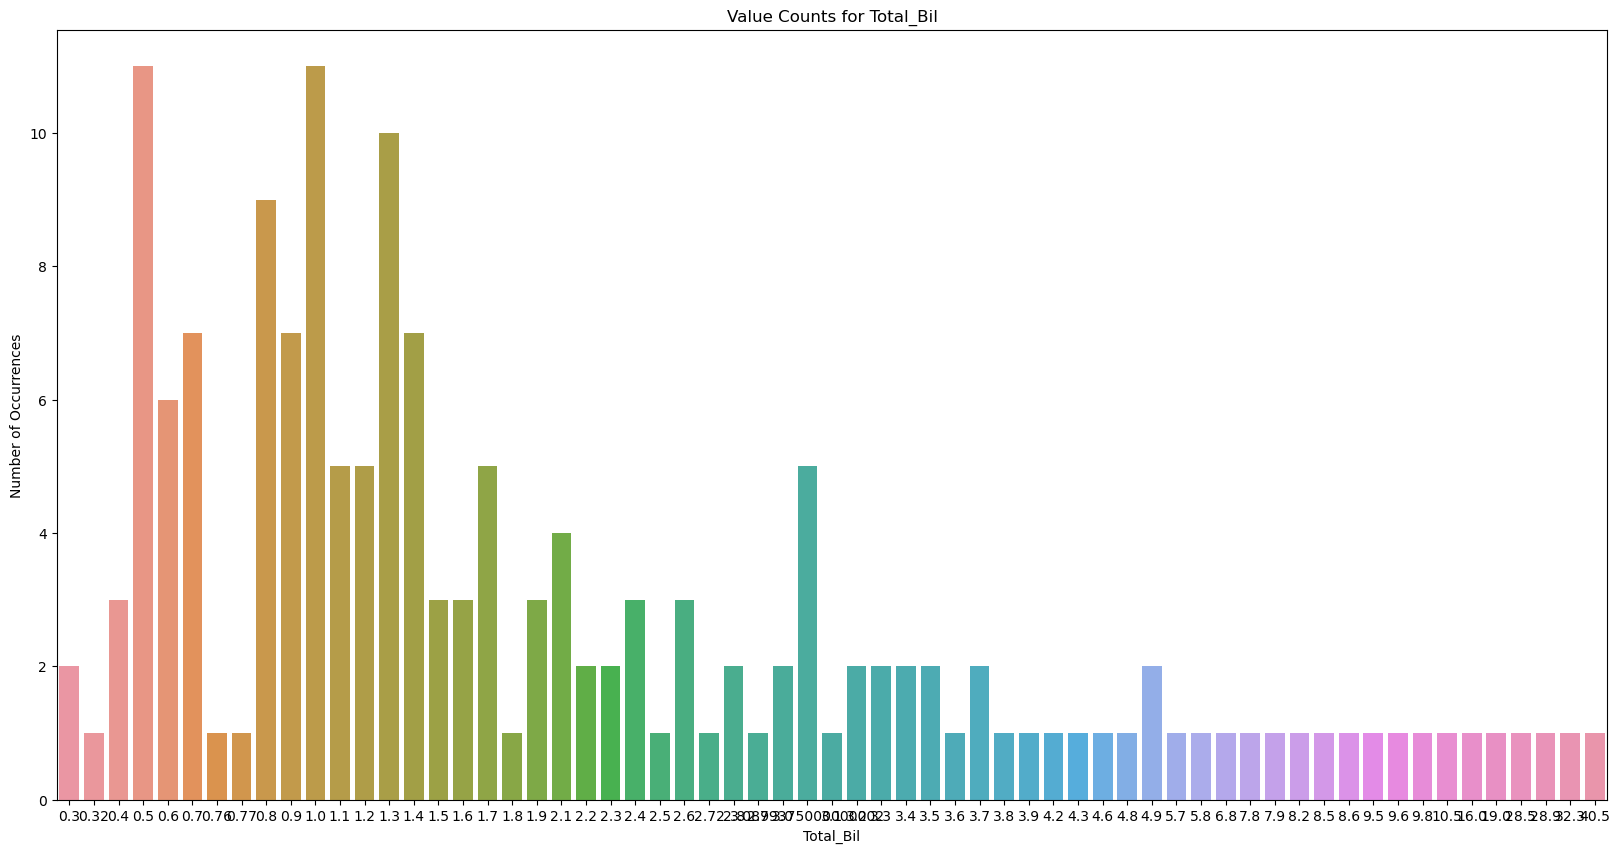

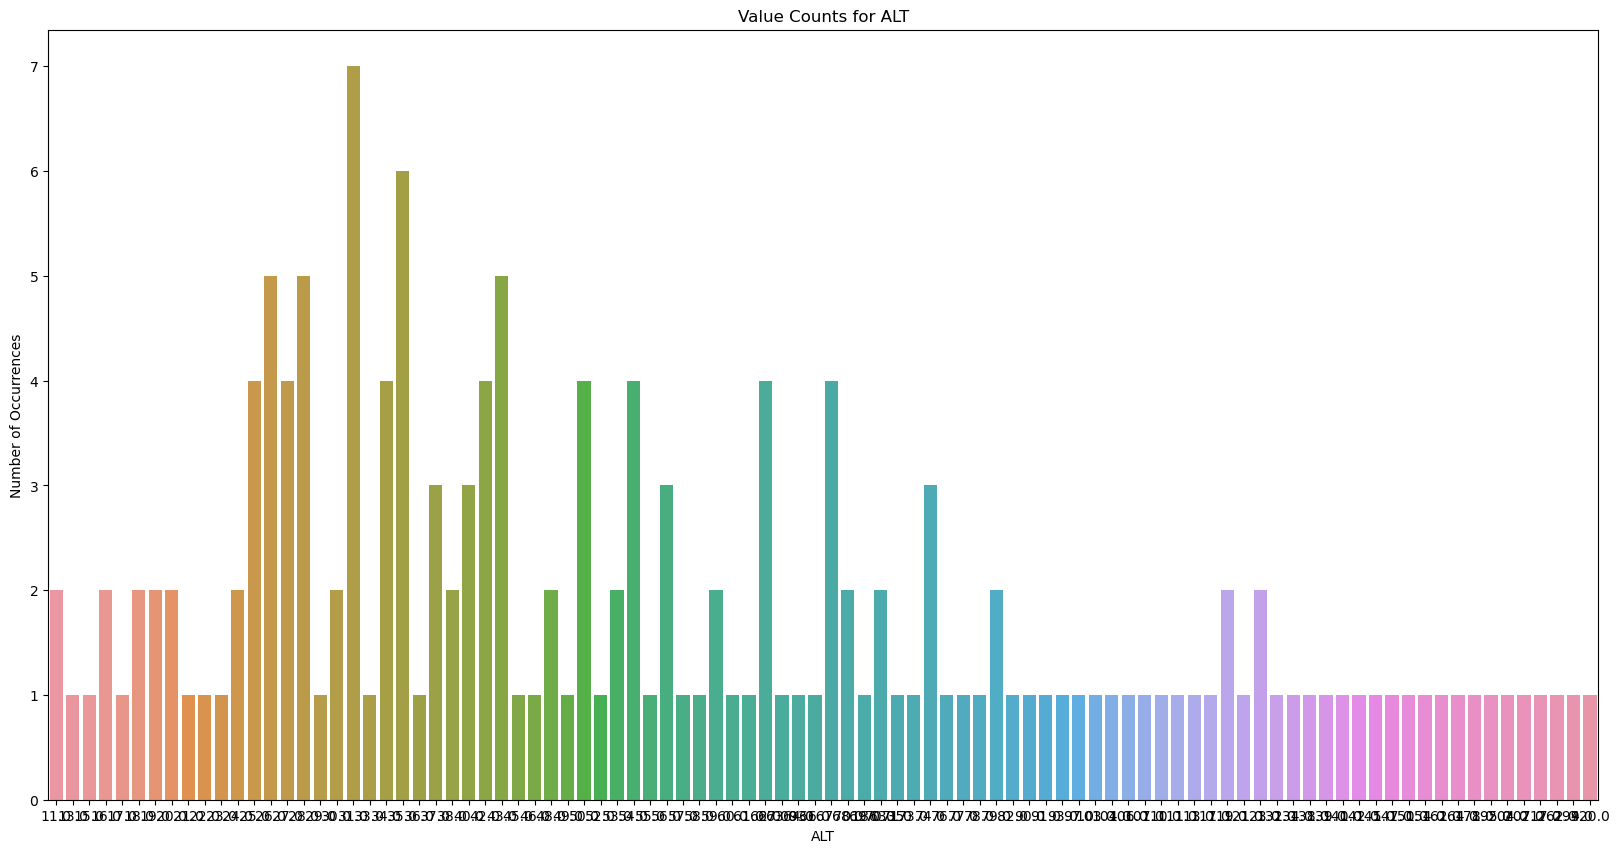

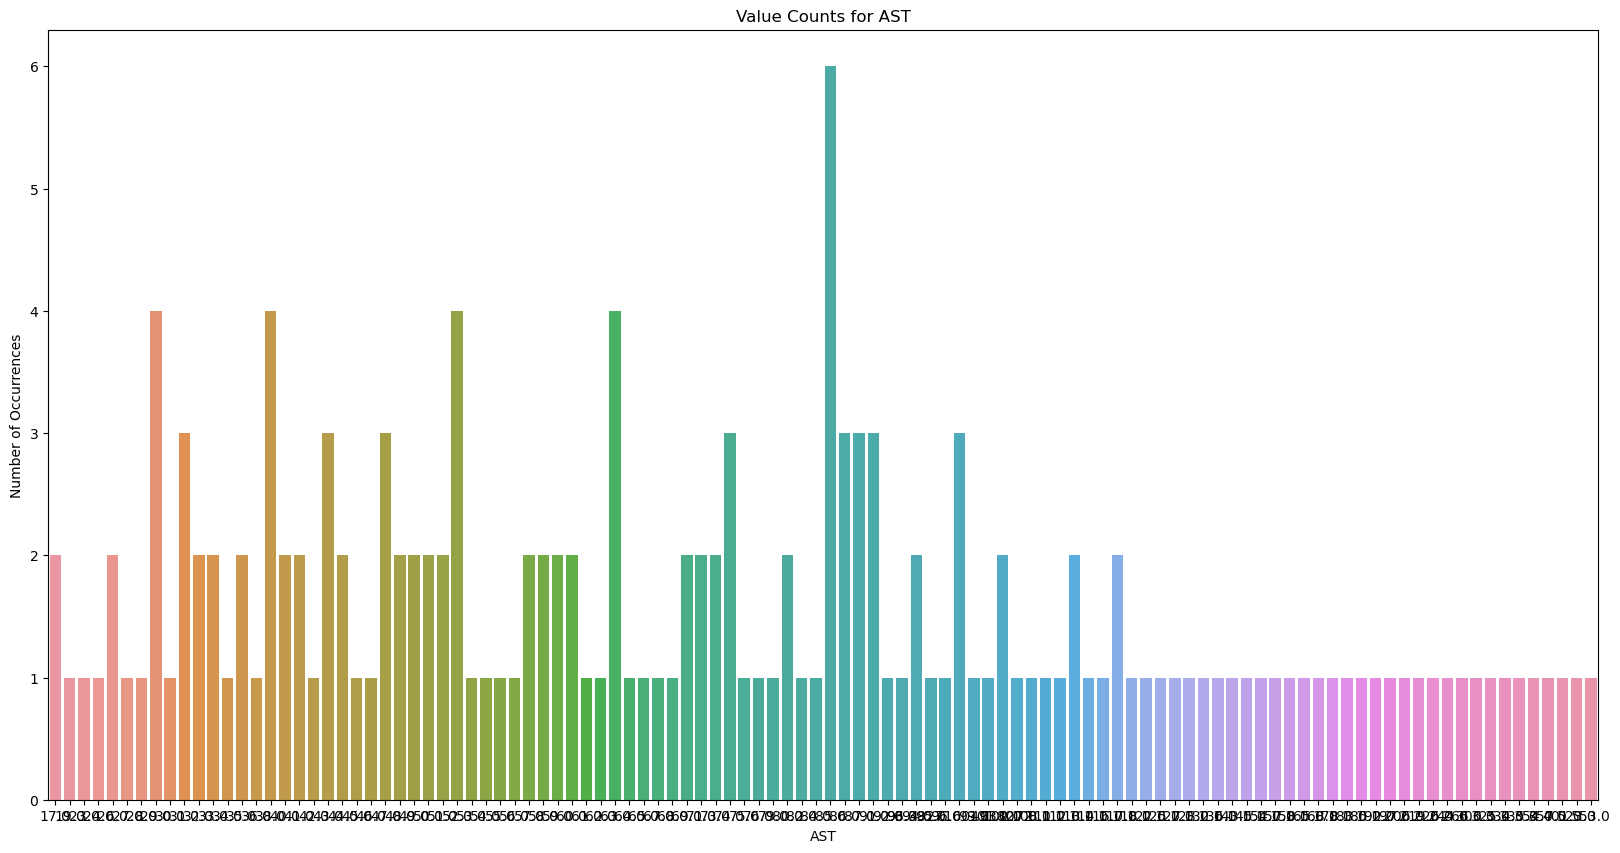

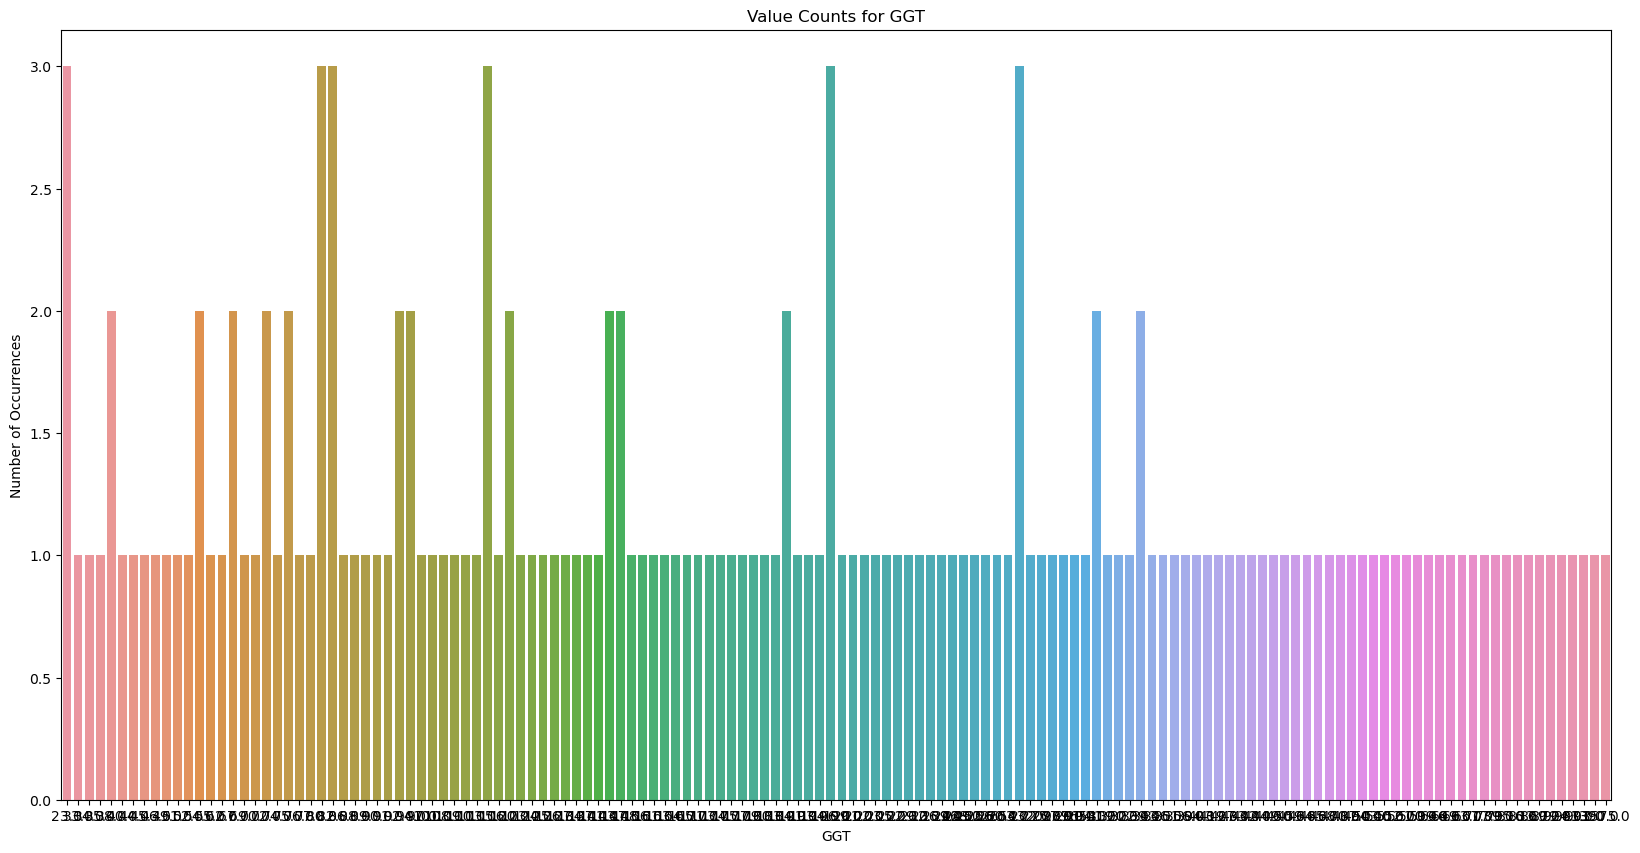

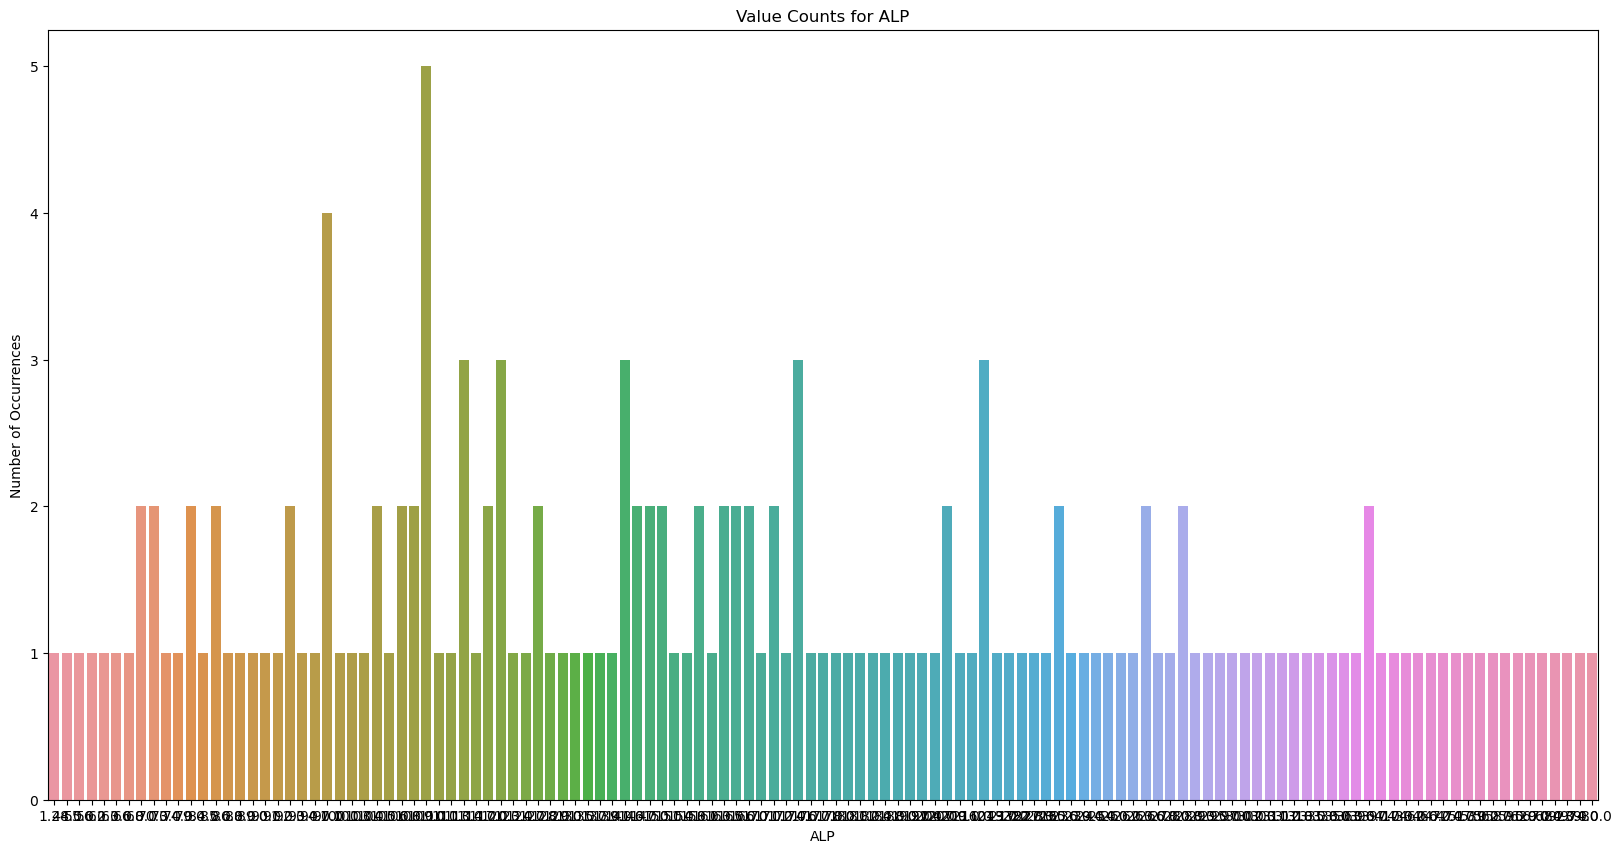

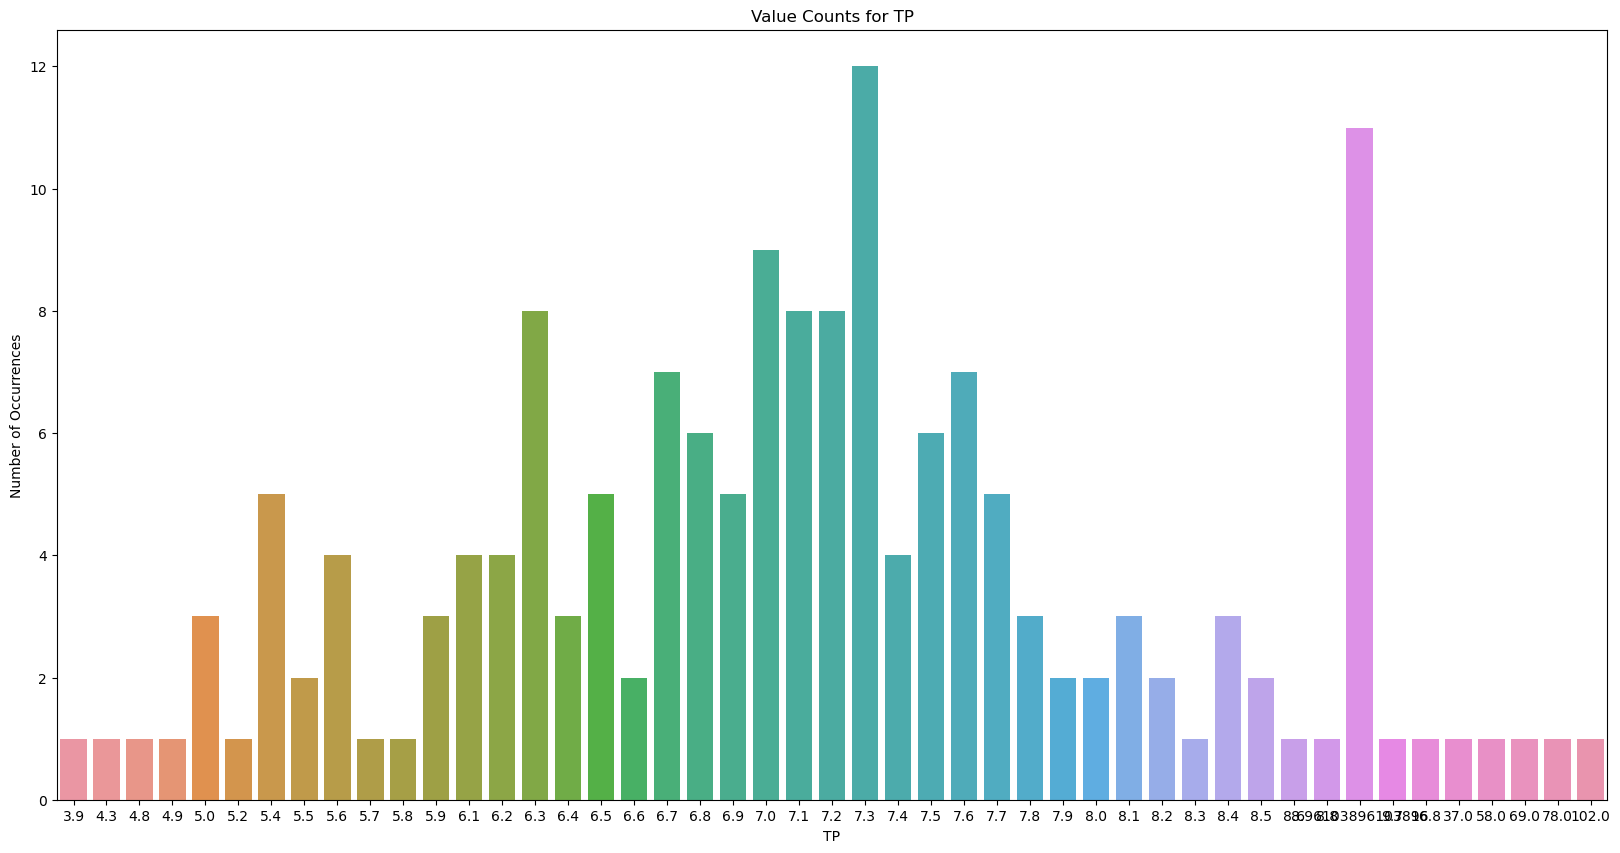

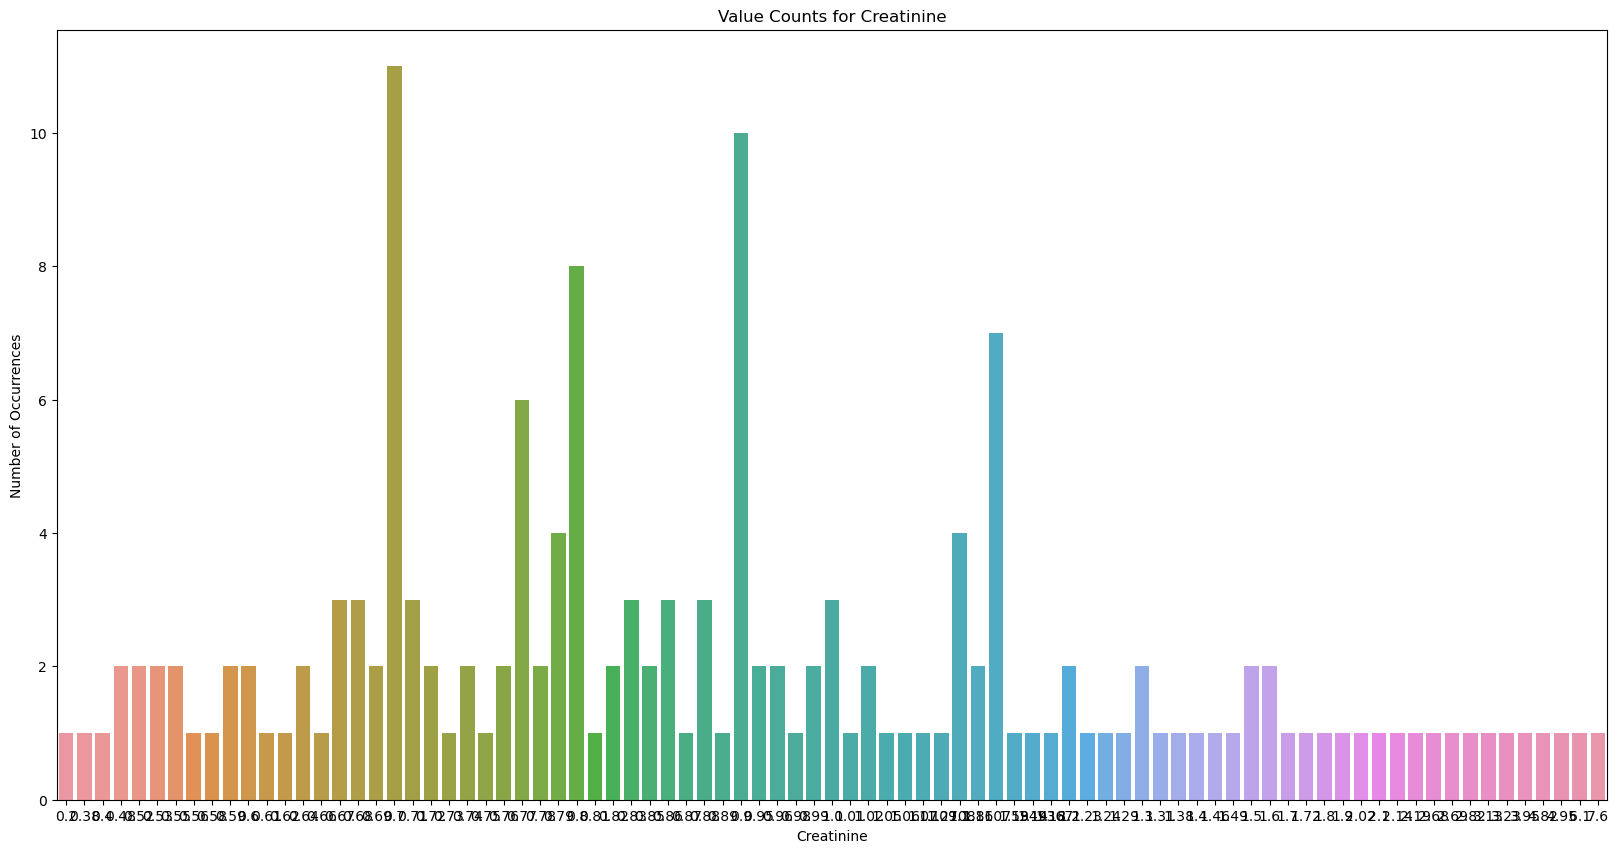

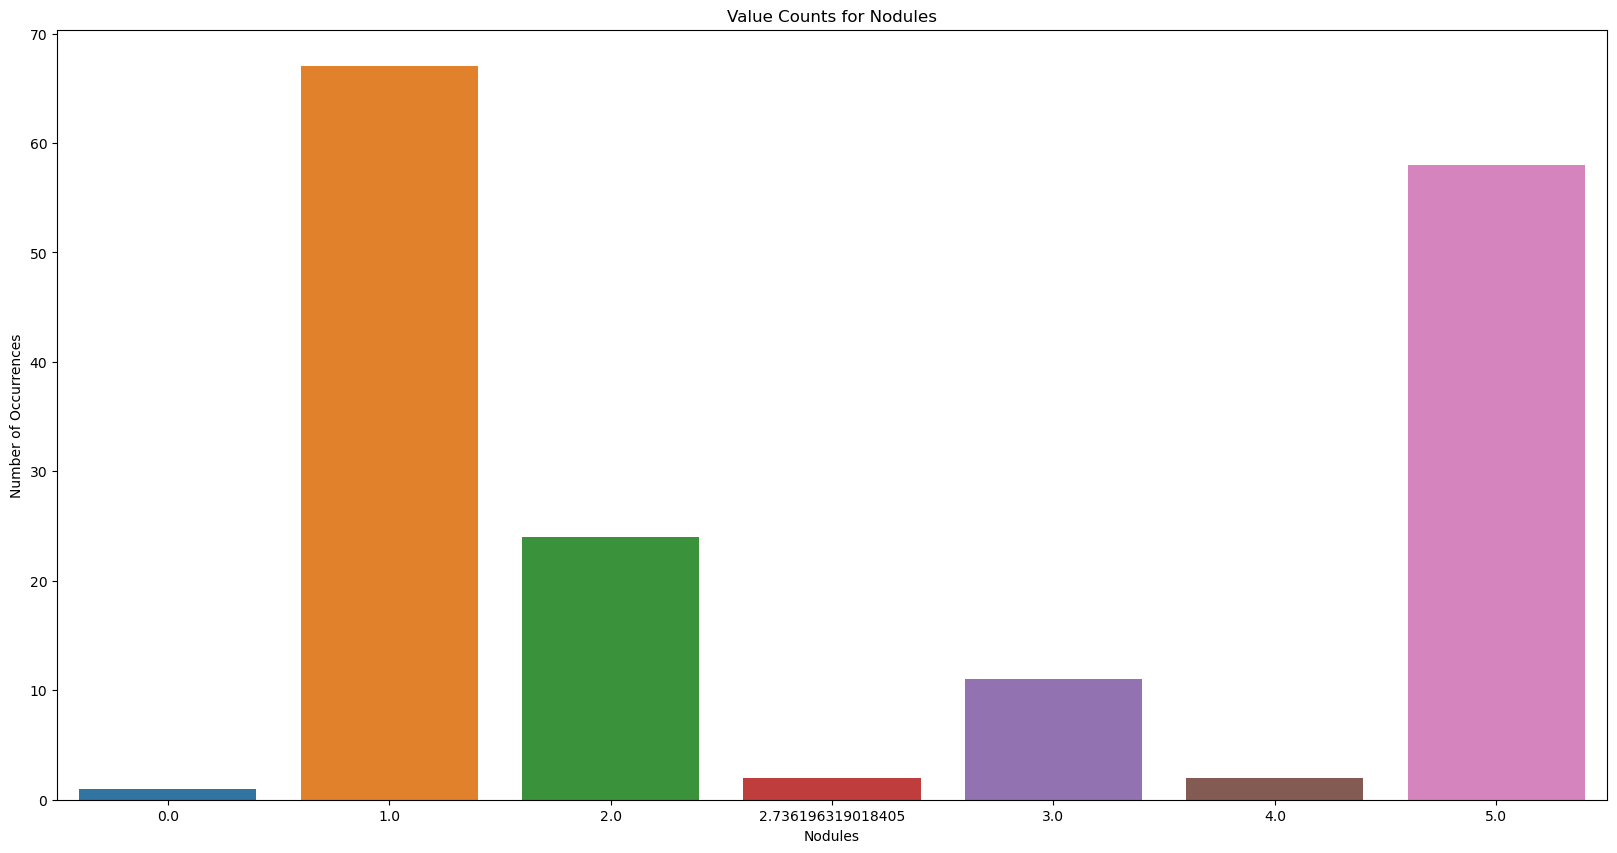

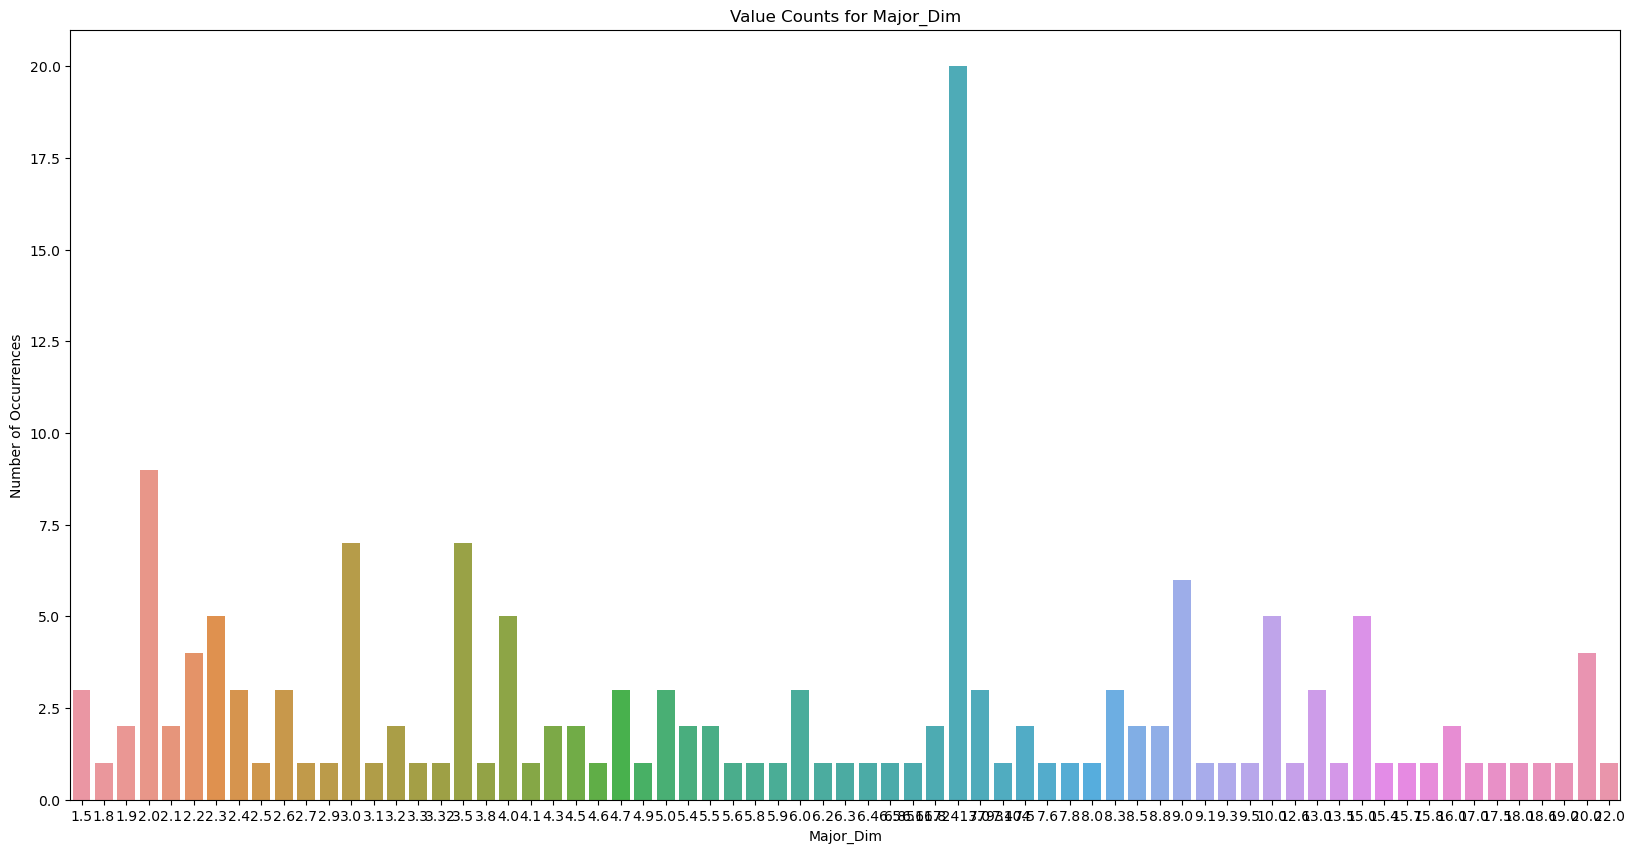

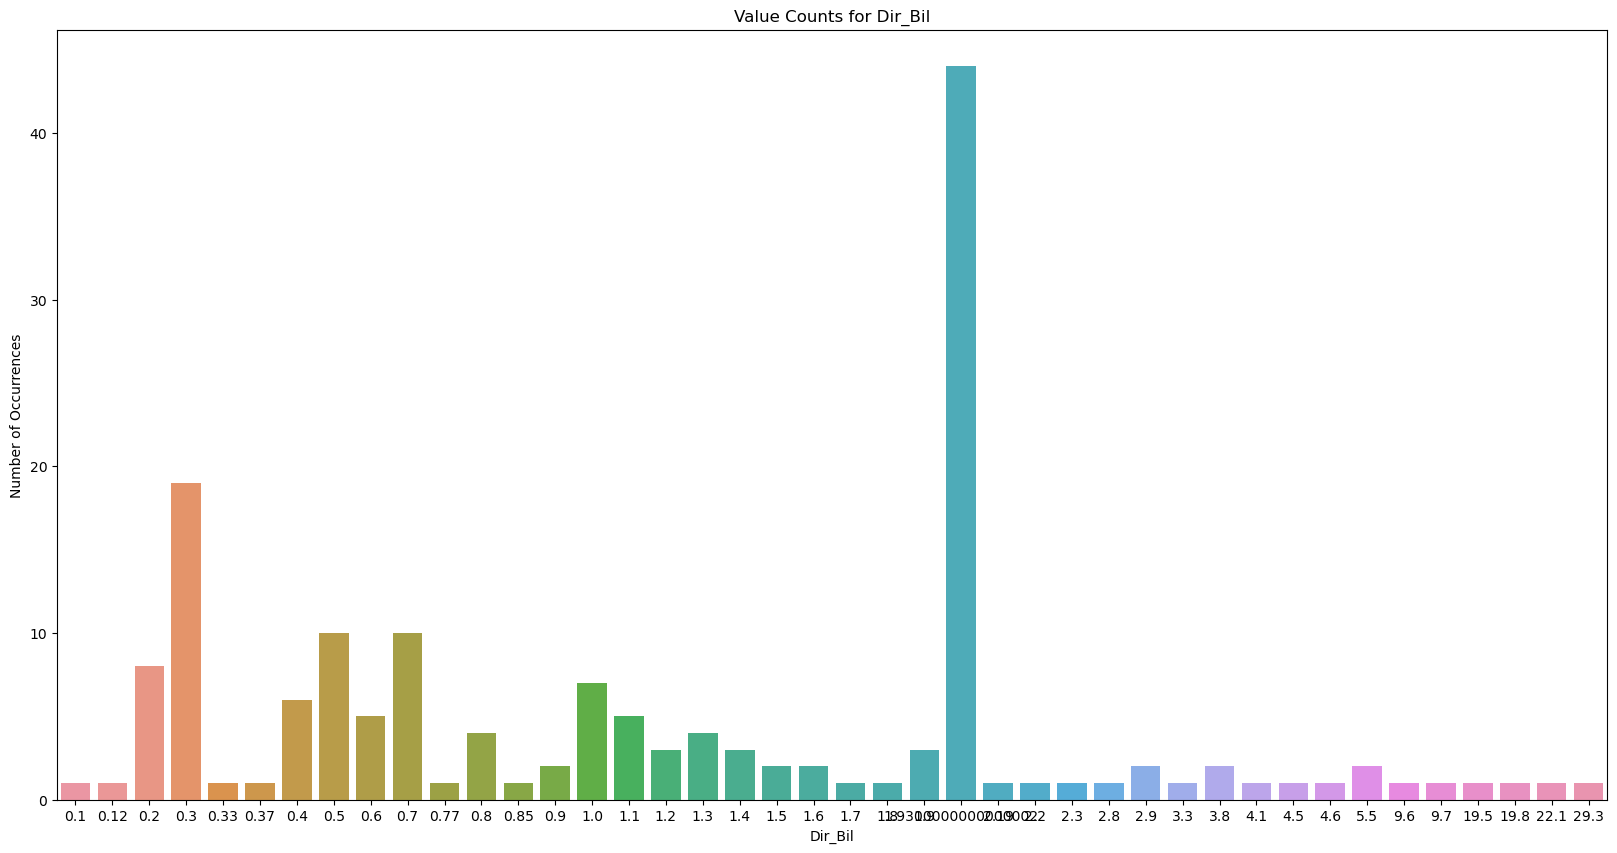

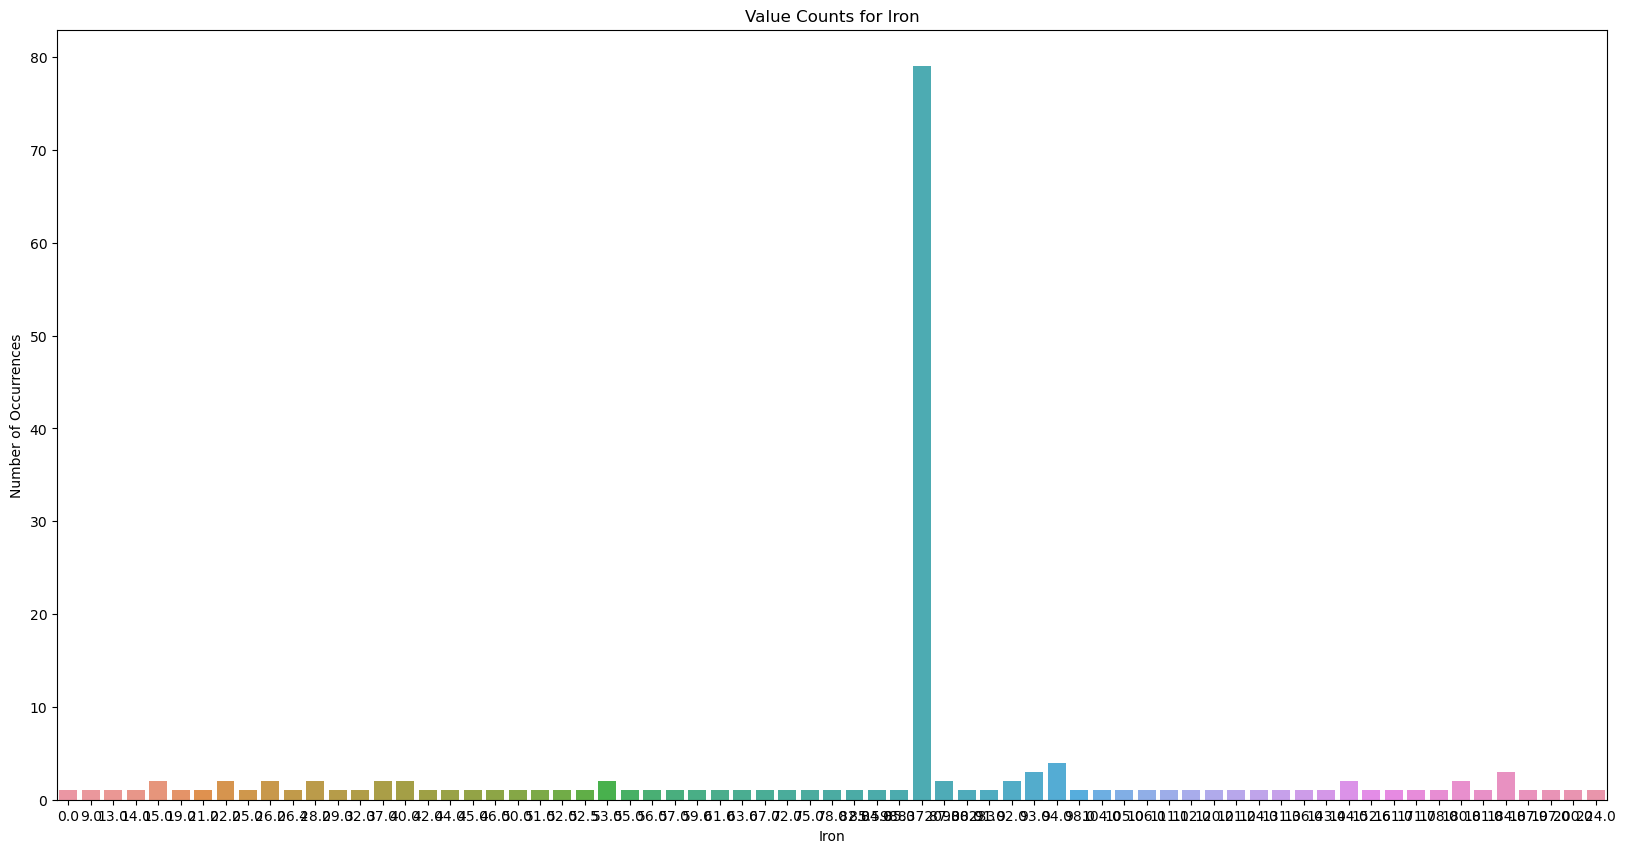

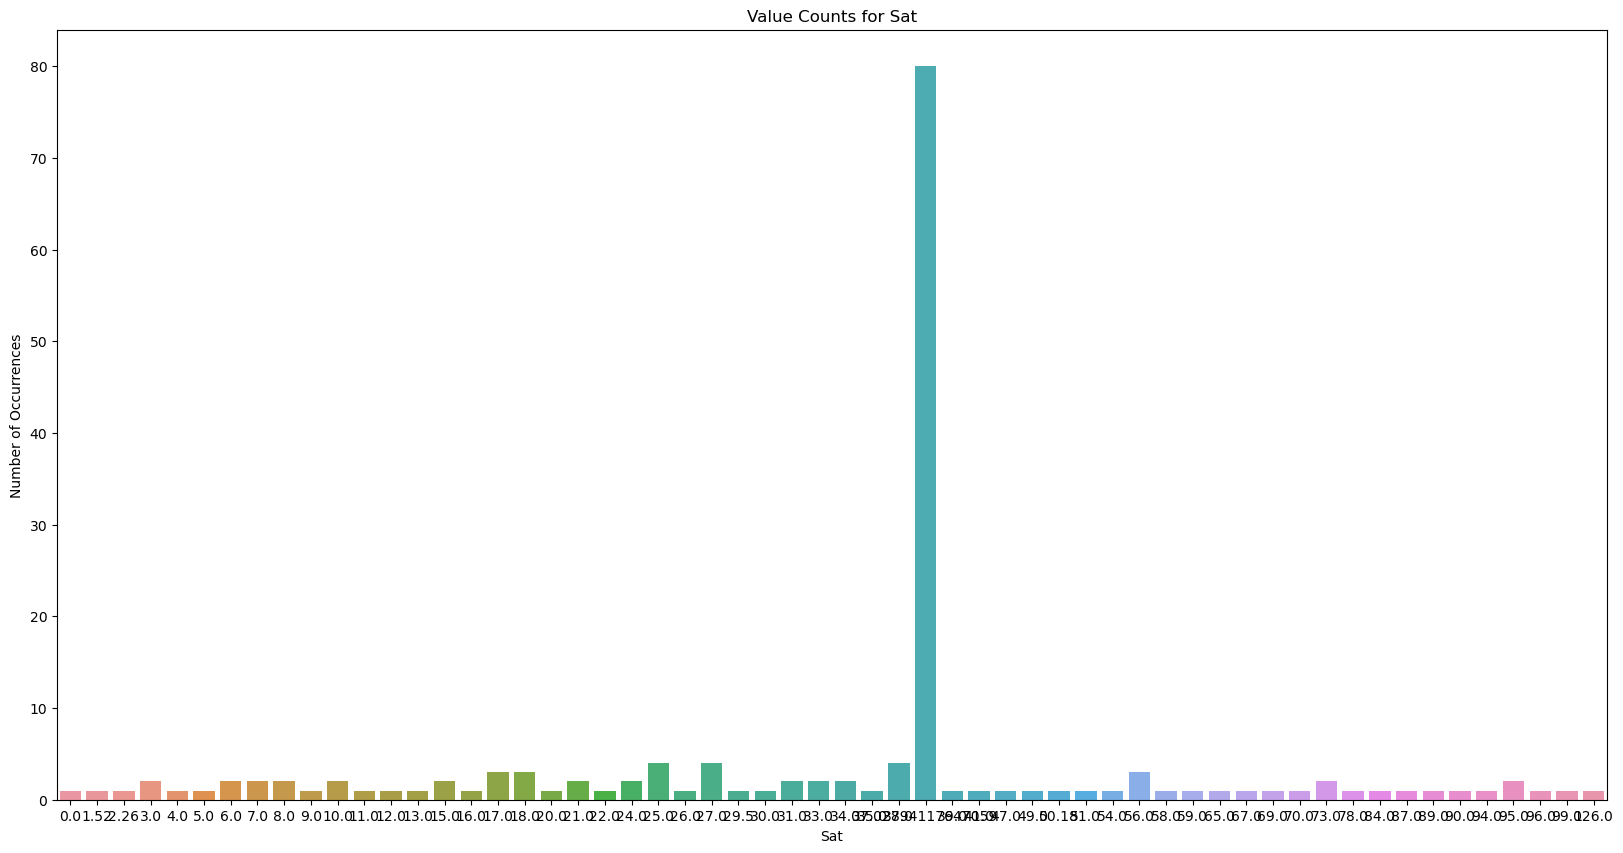

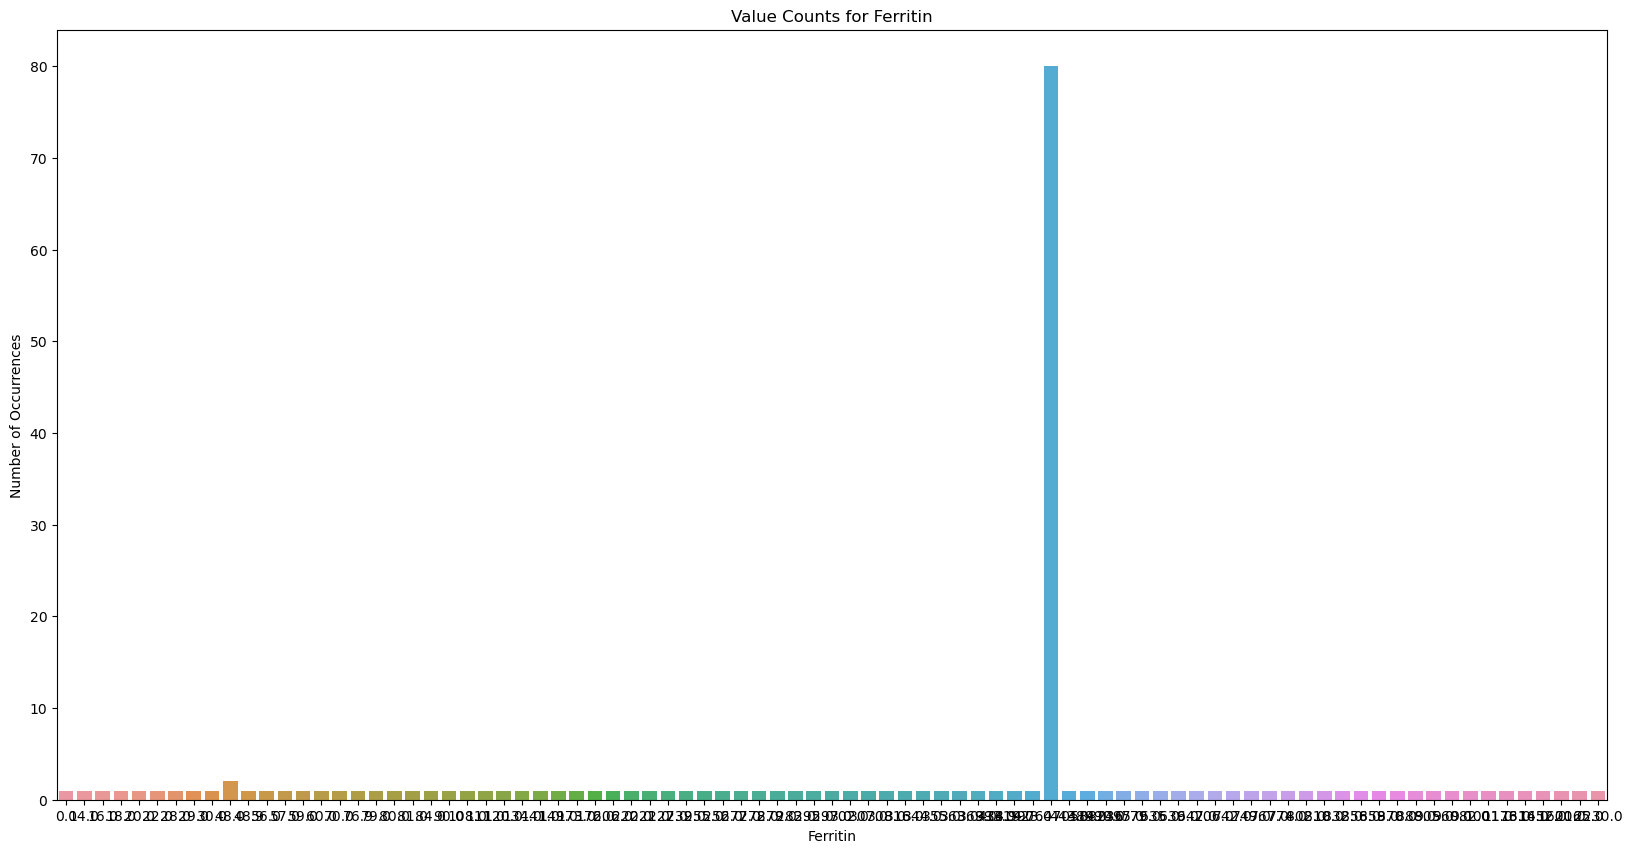

In [15]:
for column in nf_clean.columns:
    value_counts = nf_clean[column].value_counts().sort_index()

    # Plot the value counts
    plt.figure(figsize=(20, 10))
    sns.barplot(x=value_counts.index, y=value_counts.values)
    plt.title(f"Value Counts for {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Occurrences")
    plt.show()

array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'Grams_day'}>,
        <Axes: title={'center': 'Packs_year'}>,
        <Axes: title={'center': 'INR'}>, <Axes: title={'center': 'AFP'}>],
       [<Axes: title={'center': 'Hemoglobin'}>,
        <Axes: title={'center': 'MCV'}>,
        <Axes: title={'center': 'Leucocytes'}>,
        <Axes: title={'center': 'Platelets'}>,
        <Axes: title={'center': ' Albumin'}>],
       [<Axes: title={'center': 'Total_Bil'}>,
        <Axes: title={'center': 'ALT'}>, <Axes: title={'center': 'AST'}>,
        <Axes: title={'center': 'GGT'}>, <Axes: title={'center': 'ALP'}>],
       [<Axes: title={'center': 'TP'}>,
        <Axes: title={'center': 'Creatinine'}>,
        <Axes: title={'center': 'Nodules'}>,
        <Axes: title={'center': 'Major_Dim'}>,
        <Axes: title={'center': 'Dir_Bil'}>],
       [<Axes: title={'center': 'Iron'}>,
        <Axes: title={'center': 'Sat'}>,
        <Axes: title={'center': 'Ferritin'}>, <Axes: 

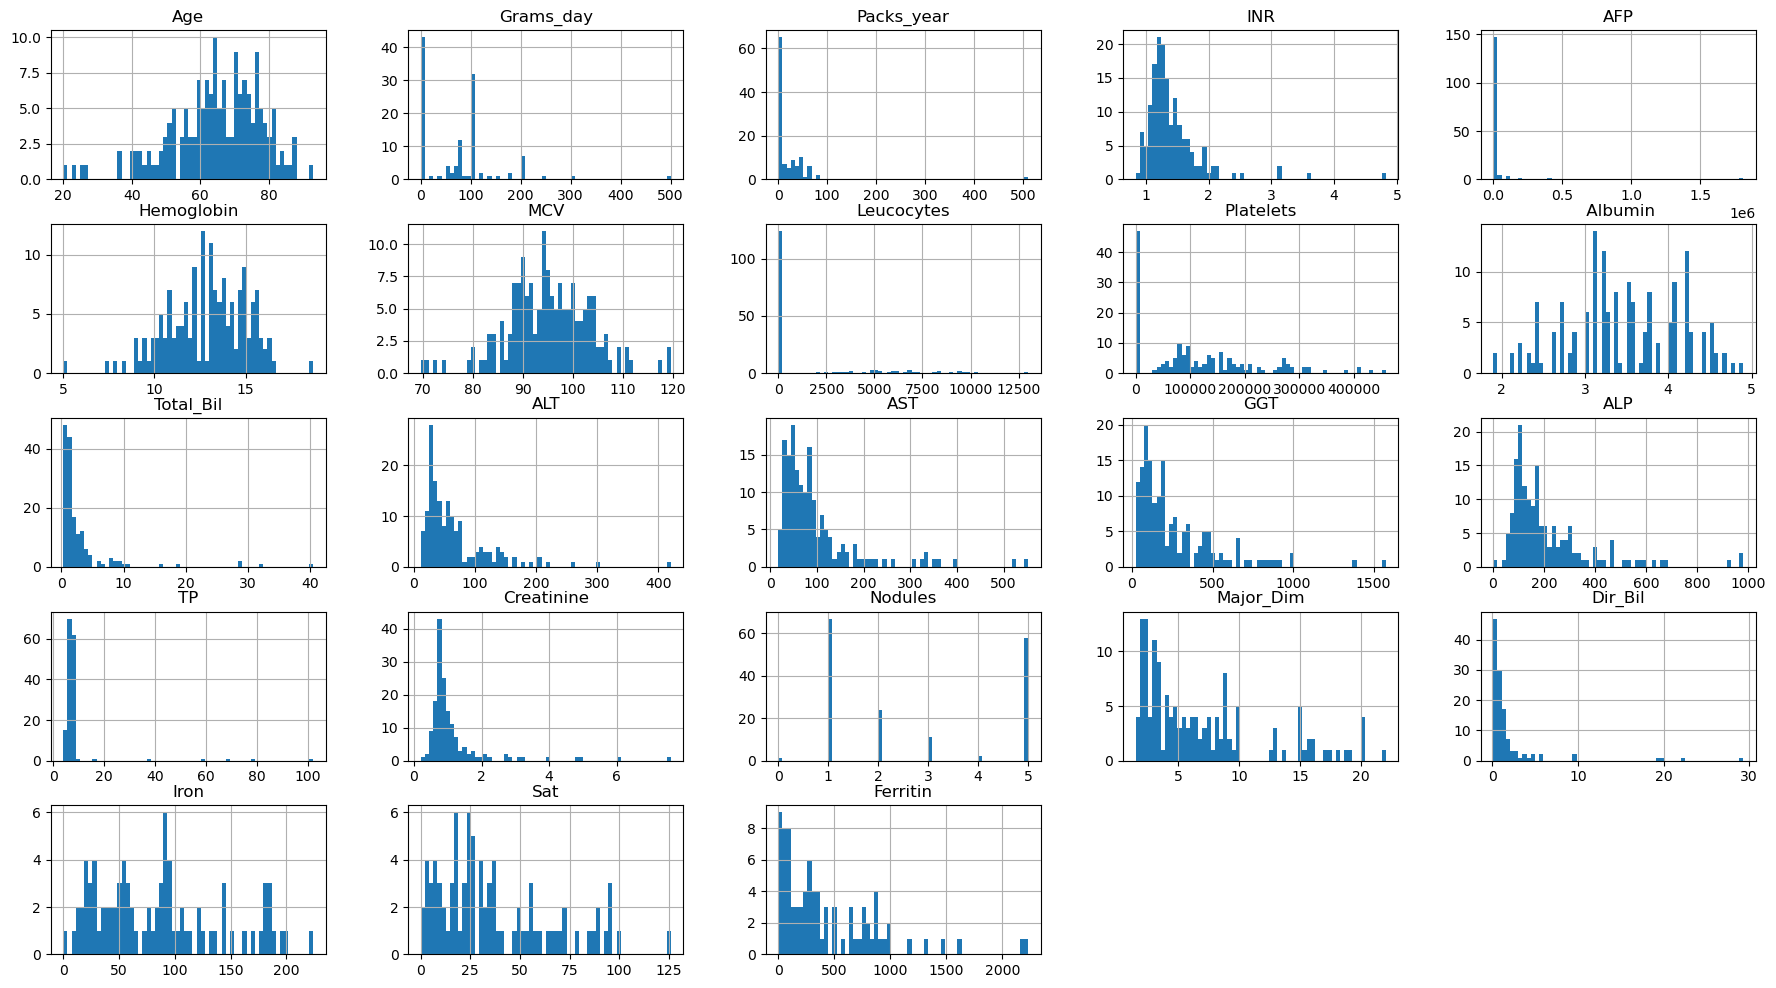

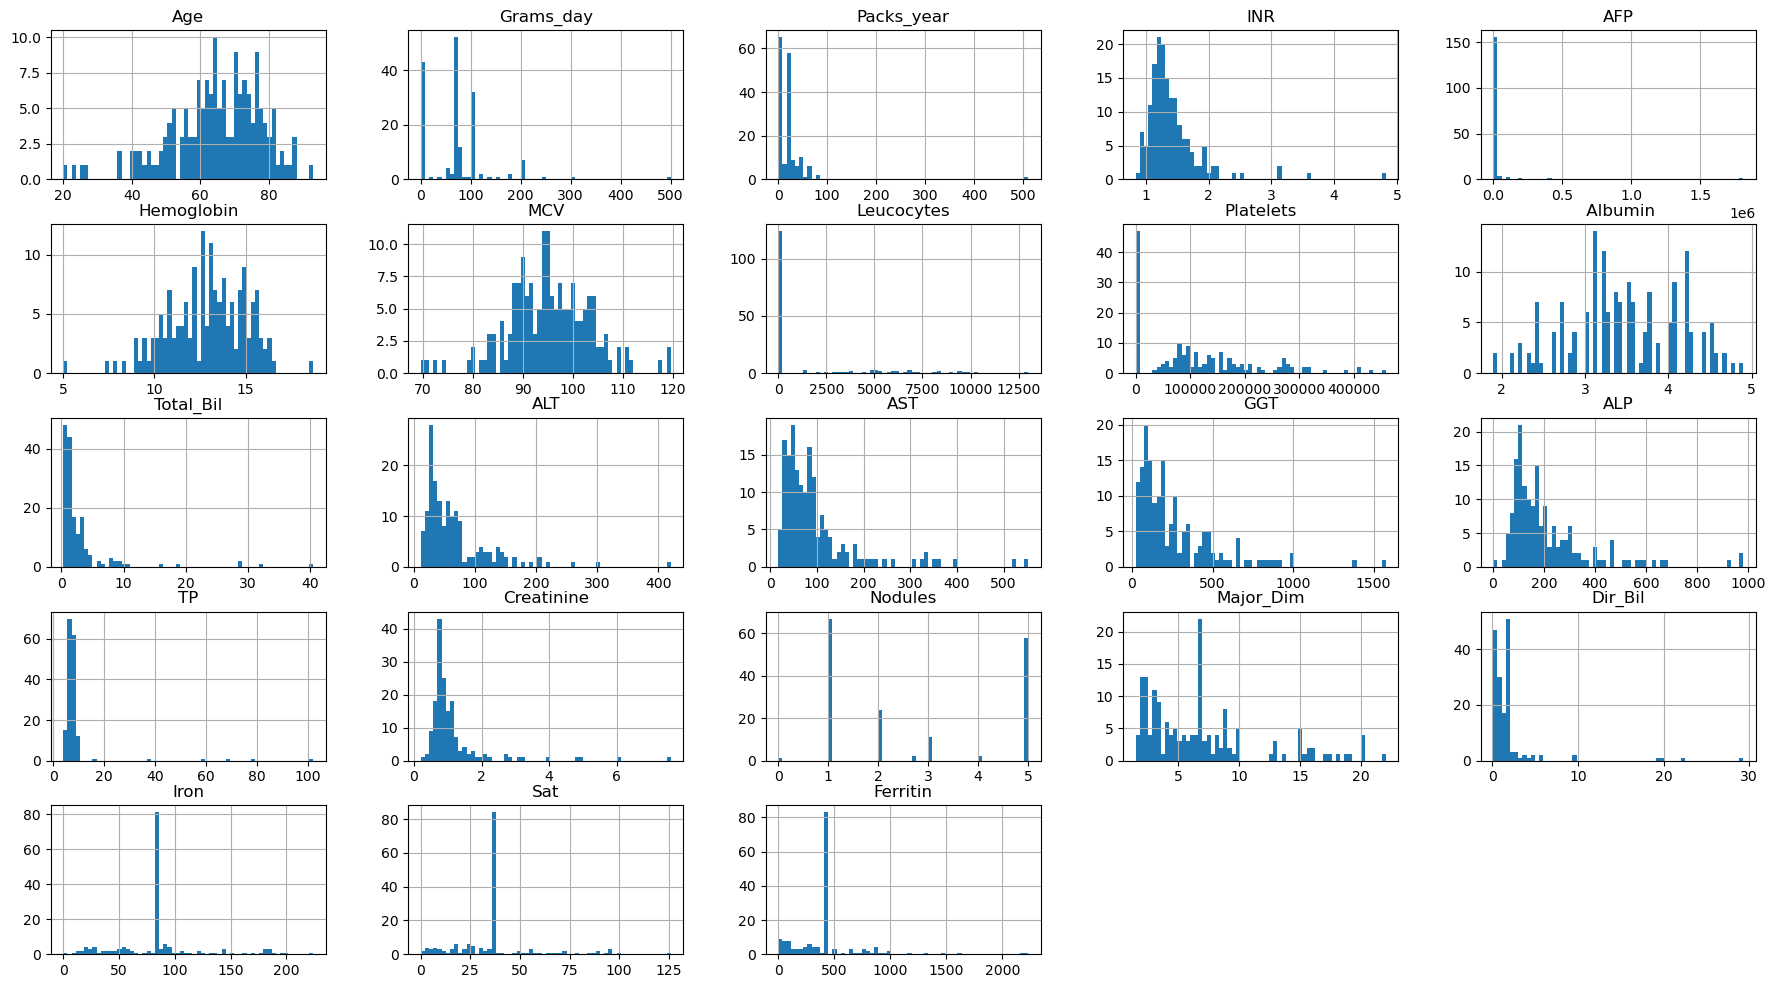

In [16]:
nf.hist(figsize=(22,12), bins=60)
nf_clean.hist(figsize=(22,12), bins=60)


Age:
  Lower Bound: 27.25
  Upper Bound: 103.75

Grams_day:
  Lower Bound: -175.0
  Upper Bound: 275.0

Packs_year:
  Lower Bound: -35.8125
  Upper Bound: 56.276785714285715

INR:
  Lower Bound: 0.5674999999999998
  Upper Bound: 2.1425

AFP:
  Lower Bound: -1691.9499999999998
  Upper Bound: 2672.1499999999996

Hemoglobin:
  Lower Bound: 6.075000000000001
  Upper Bound: 20.025

MCV:
  Lower Bound: 71.97500000000001
  Upper Bound: 118.32499999999999

Leucocytes:
  Lower Bound: -64.025
  Upper Bound: 113.725

Platelets:
  Lower Bound: -296757.5
  Upper Bound: 467027.5

 Albumin:
  Lower Bound: 1.5250000000000004
  Upper Bound: 5.574999999999999

Total_Bil:
  Lower Bound: -2.9288906250000006
  Upper Bound: 6.916828125

ALT:
  Lower Bound: -49.5
  Upper Bound: 157.5

AST:
  Lower Bound: -59.75
  Upper Bound: 214.75

GGT:
  Lower Bound: -347.25
  Upper Bound: 782.25

ALP:
  Lower Bound: -155.25
  Upper Bound: 524.25

TP:
  Lower Bound: 4.125000000000001
  Upper Bound: 9.975

Creatinine:
  Lo

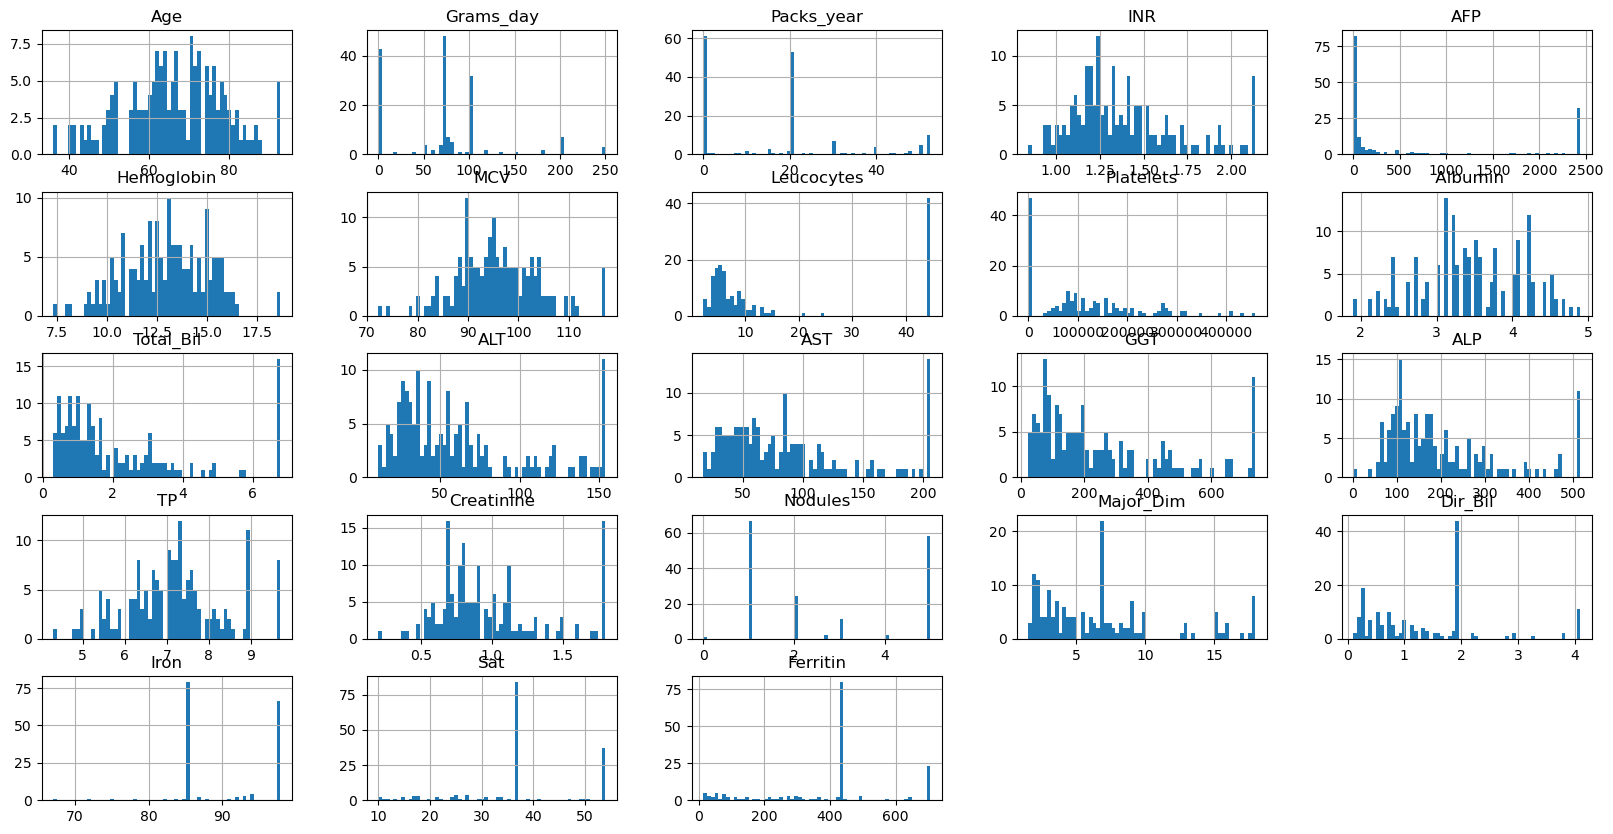

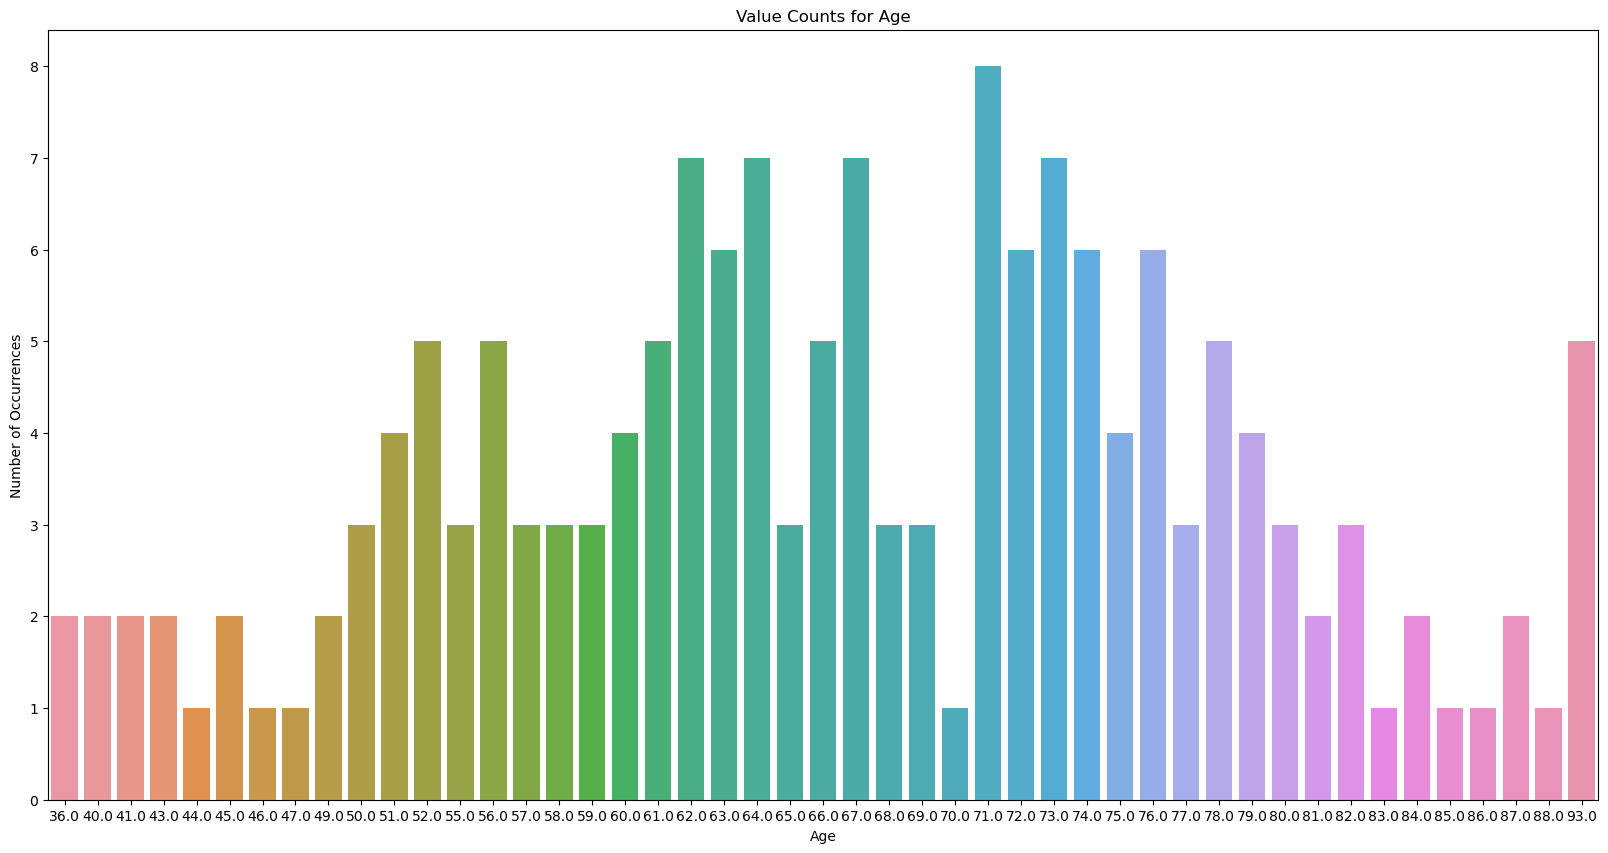

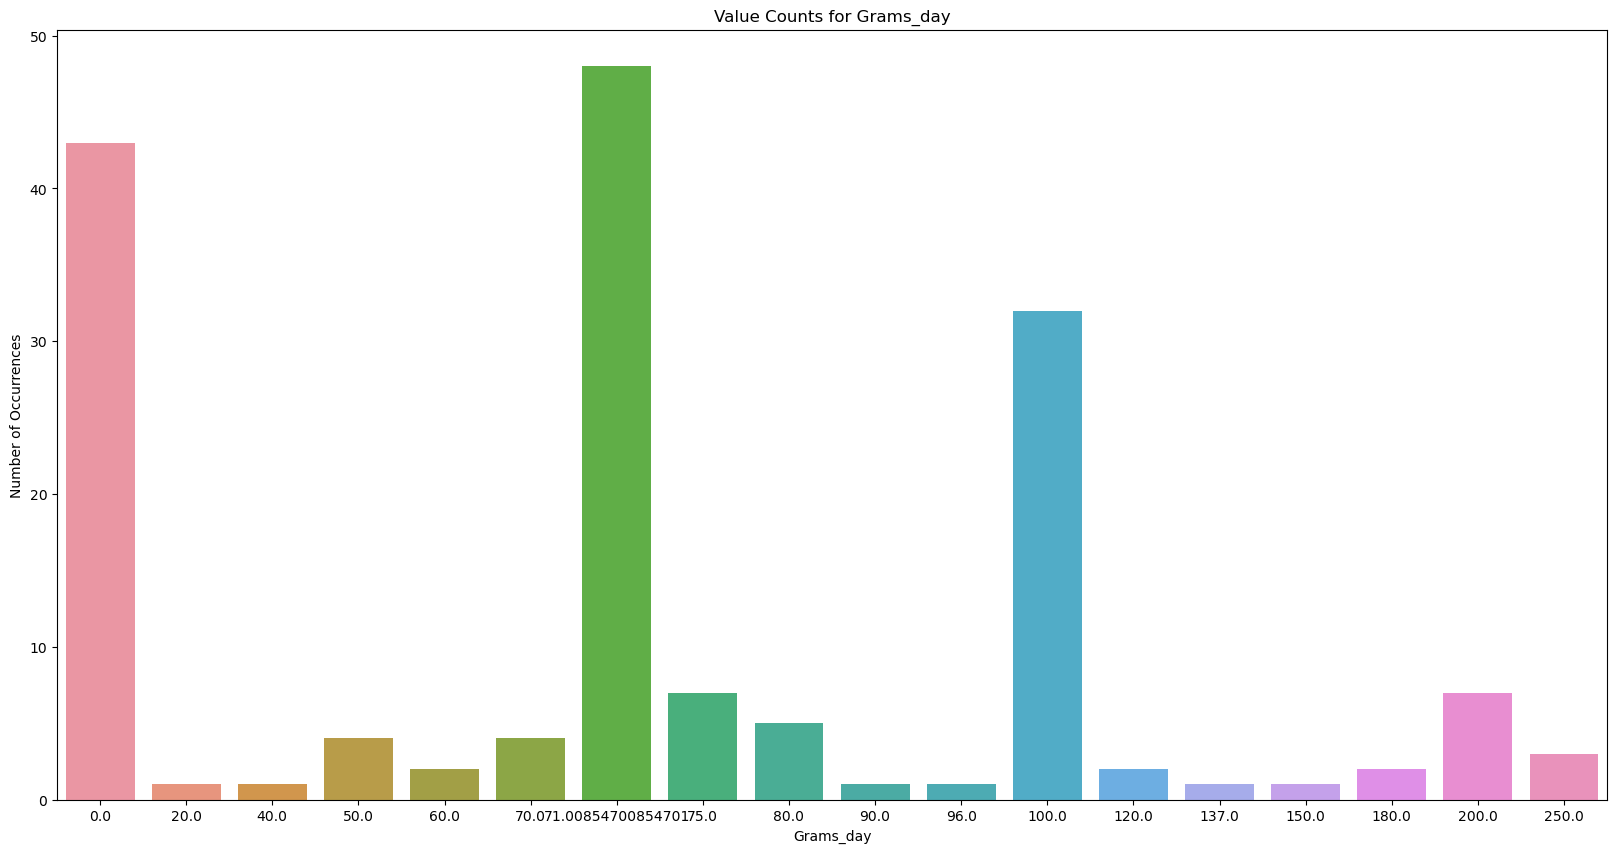

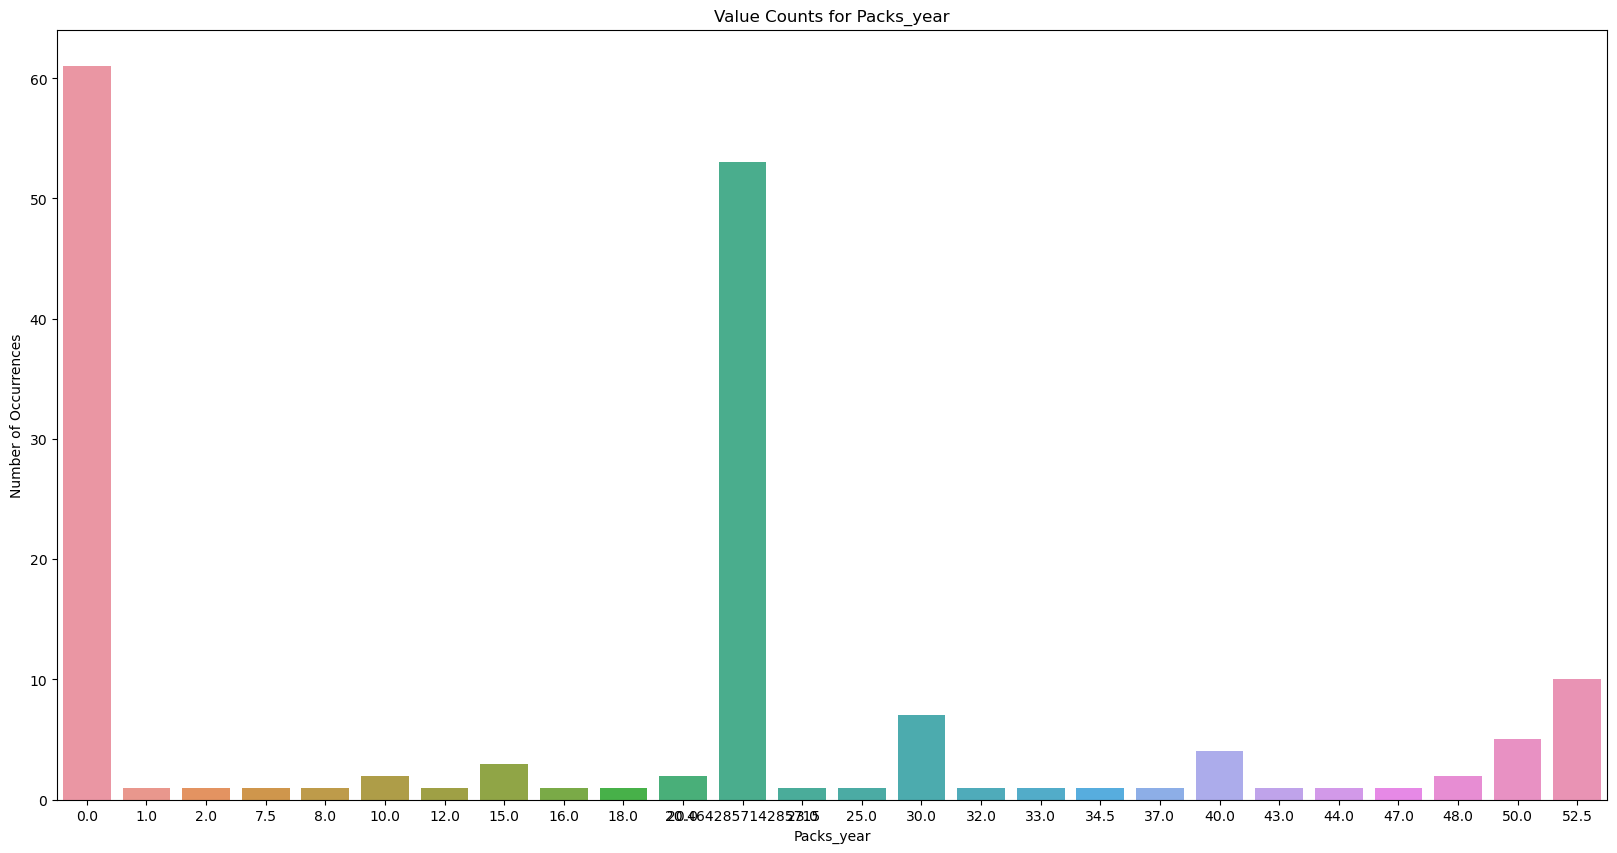

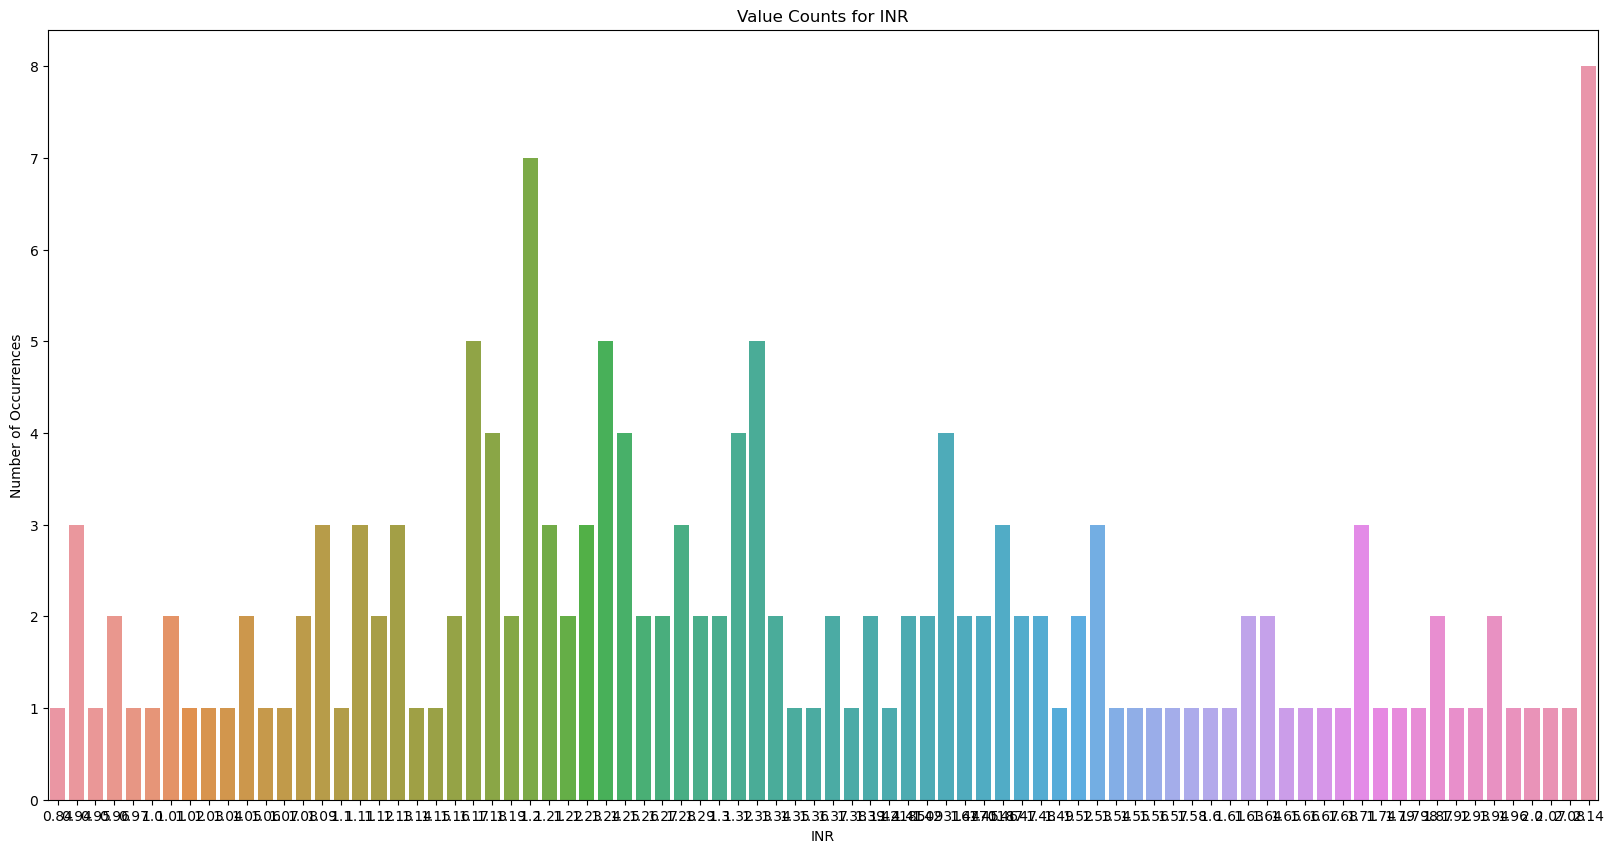

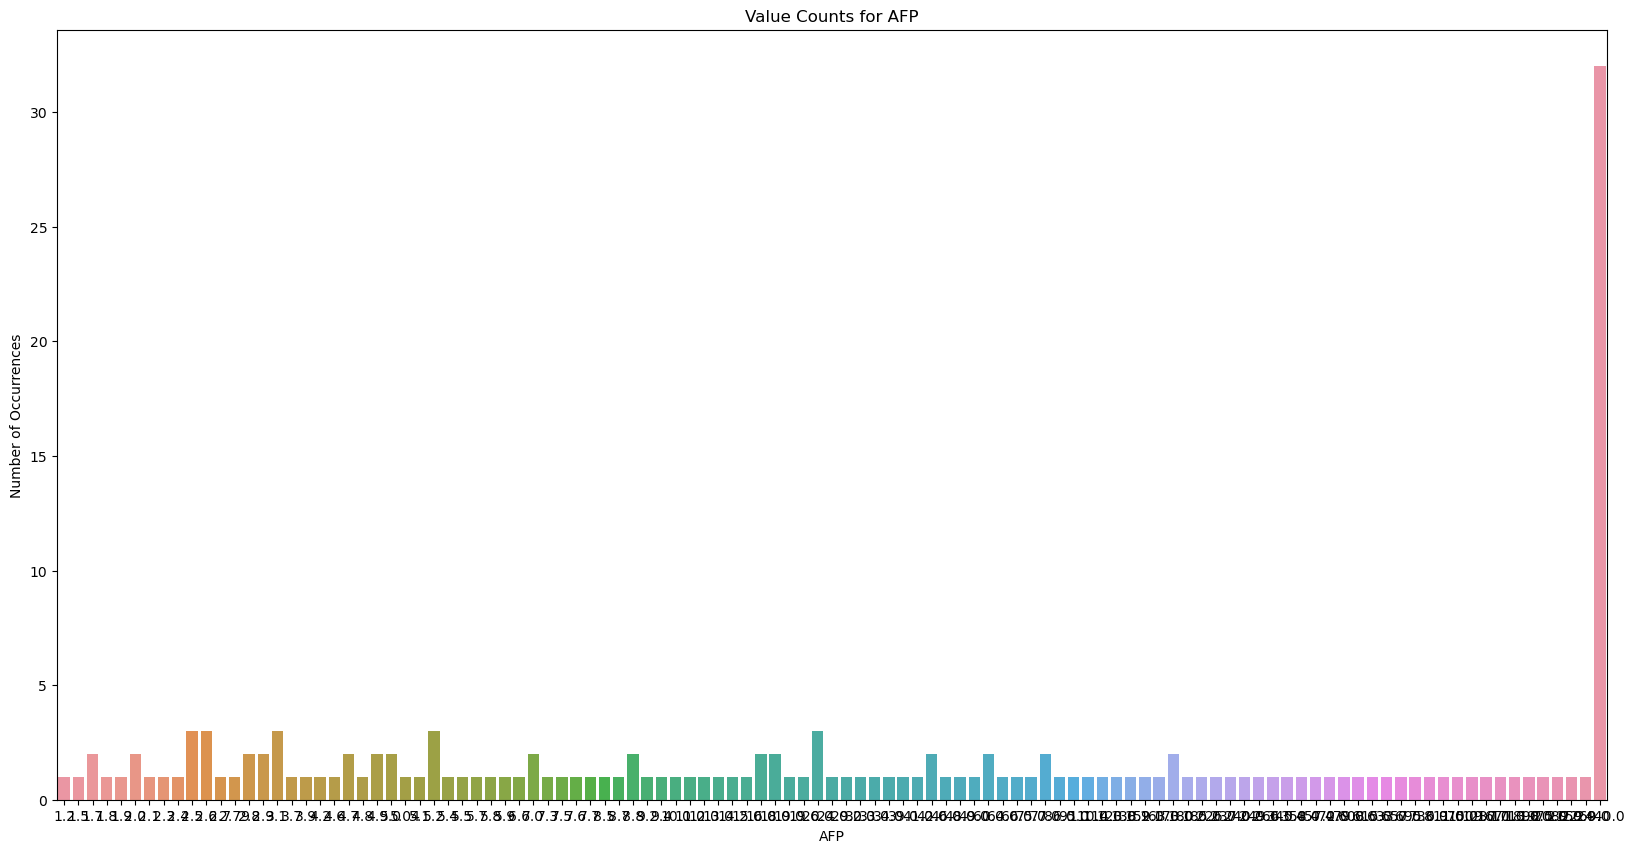

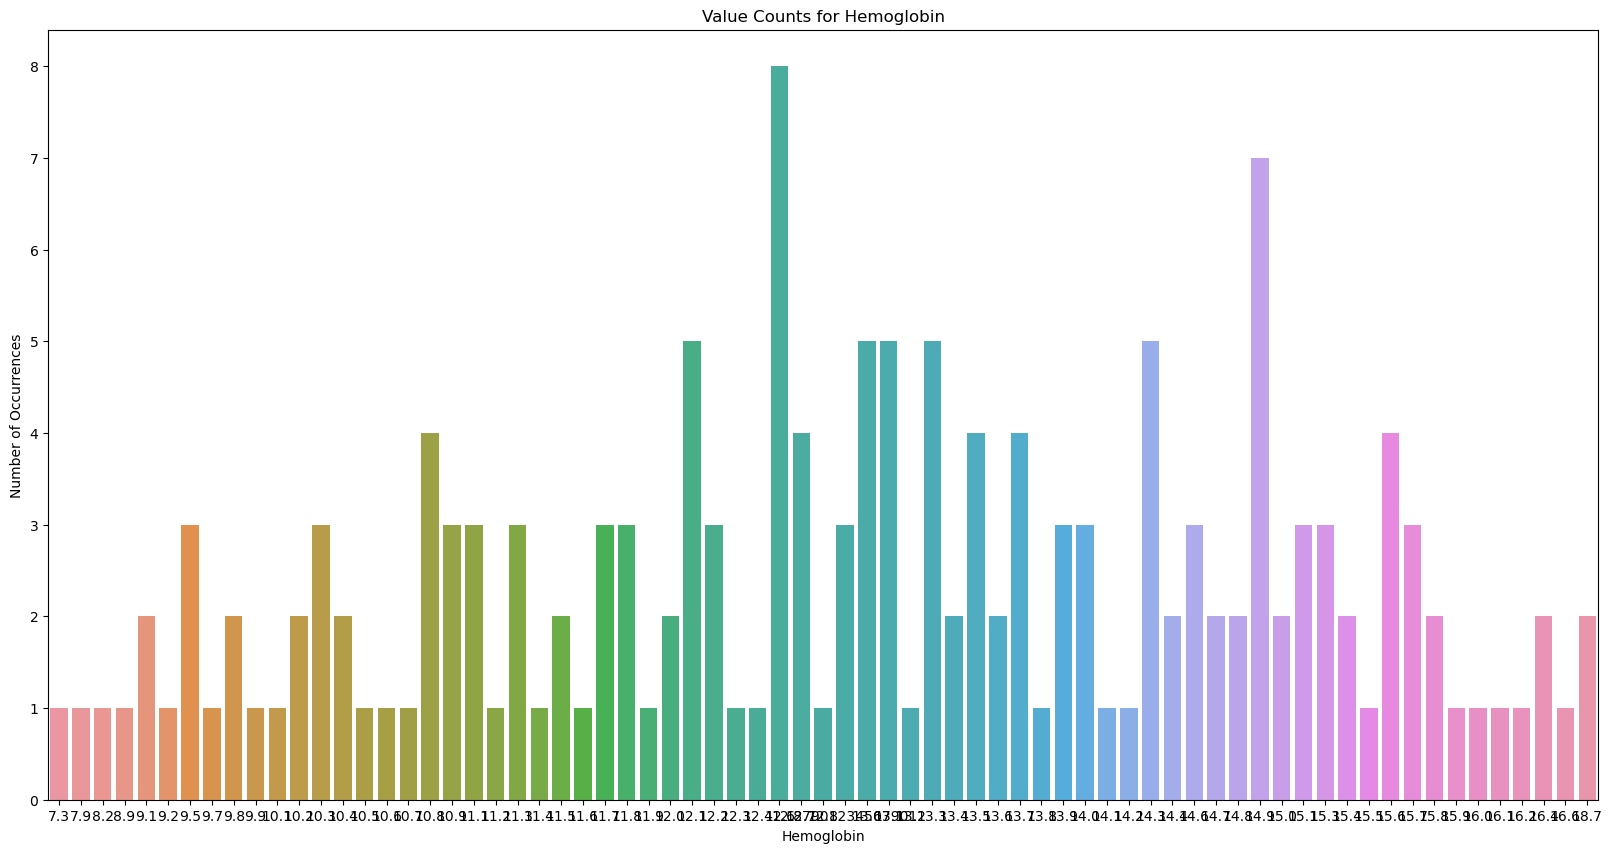

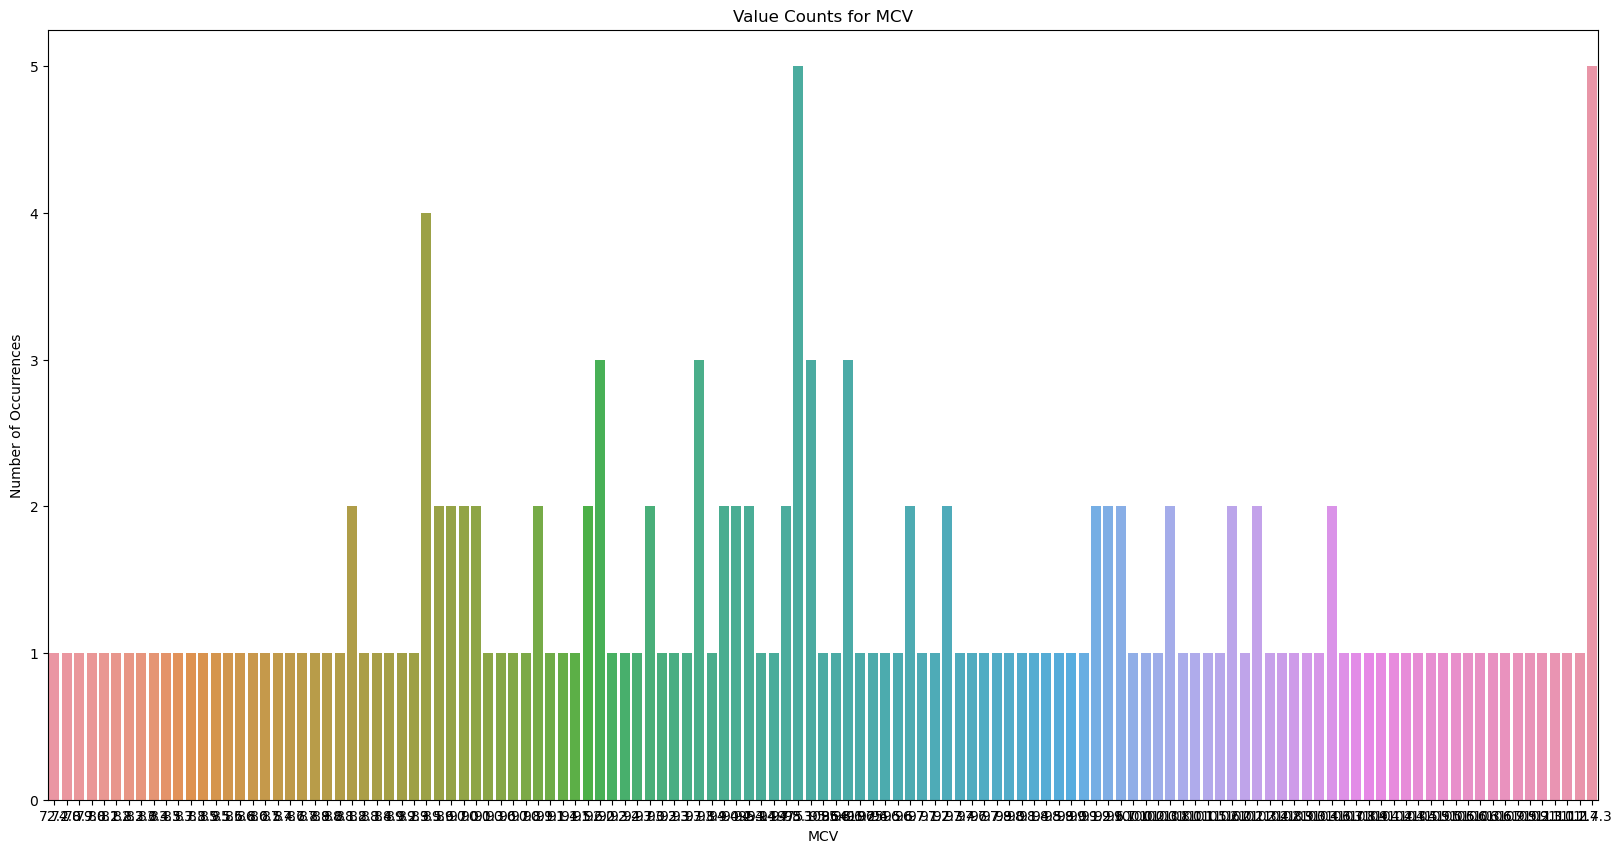

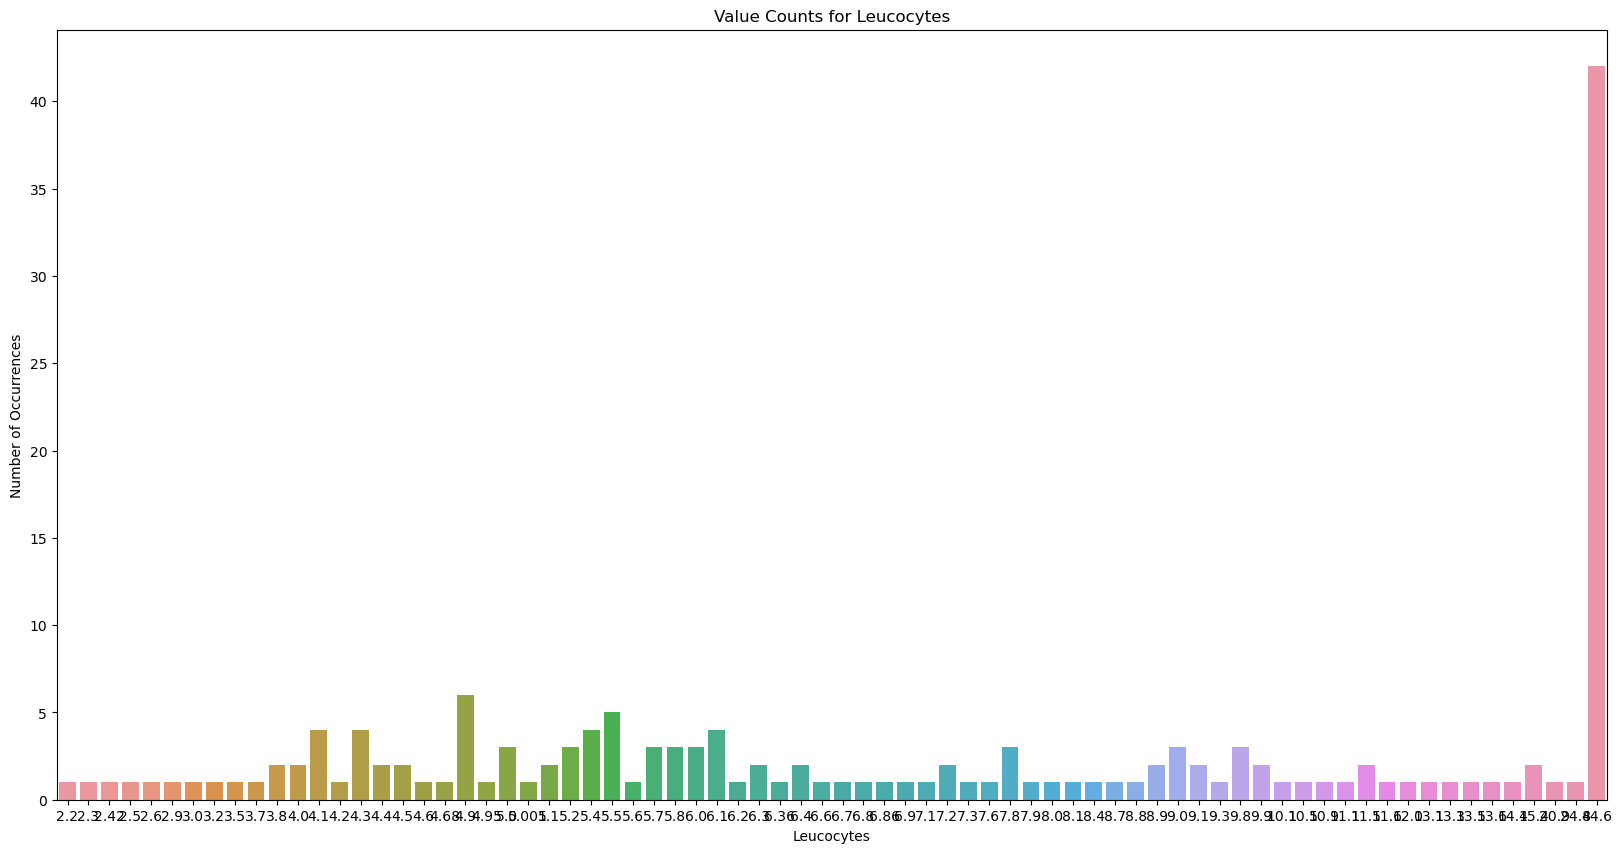

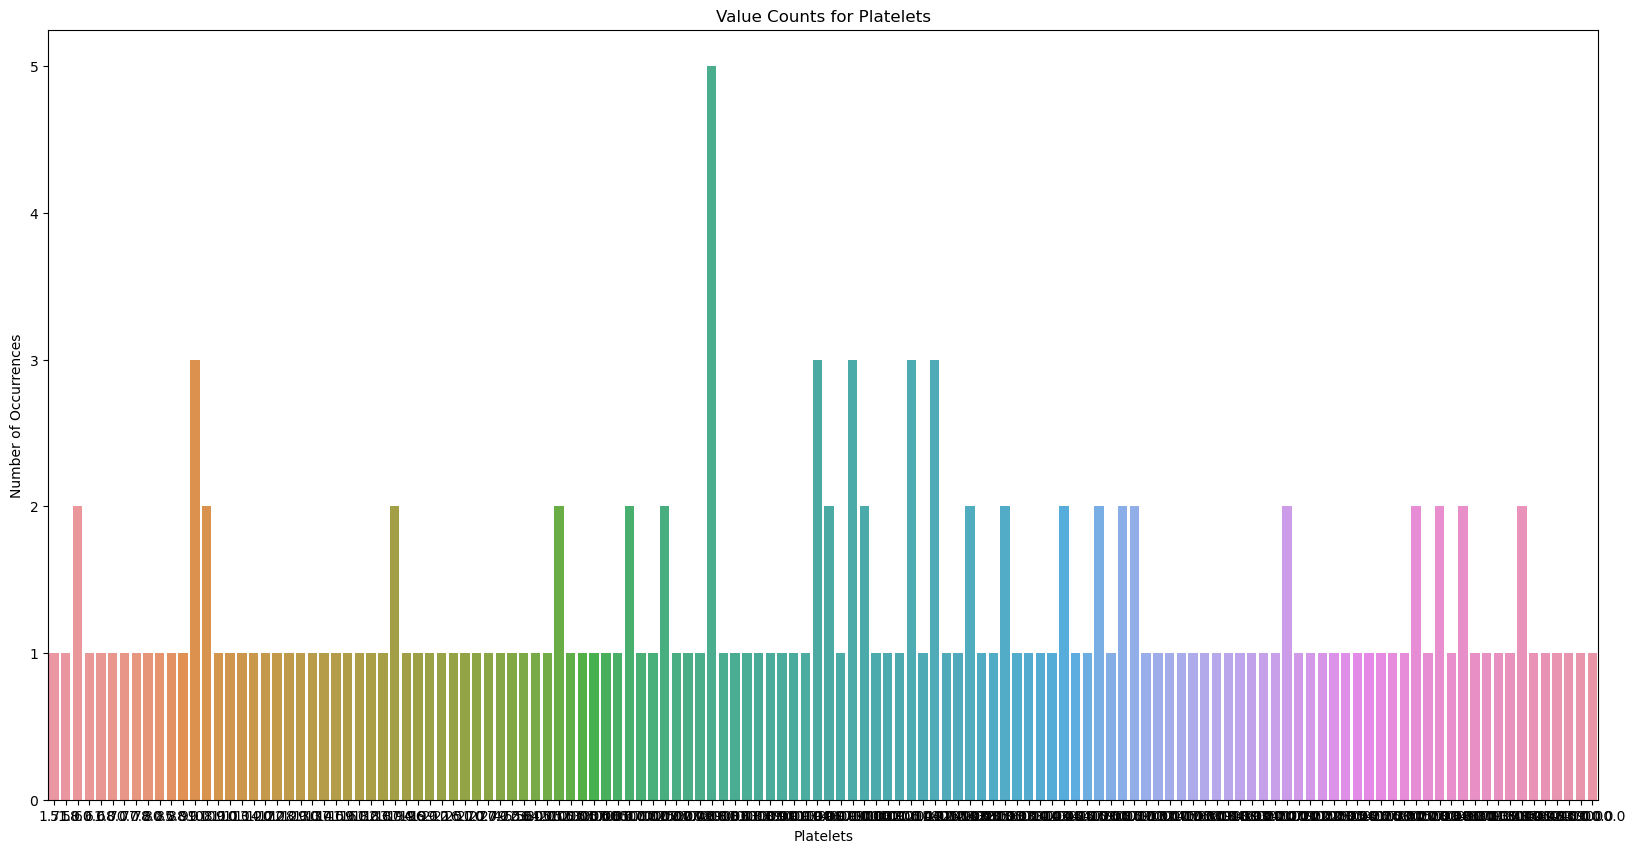

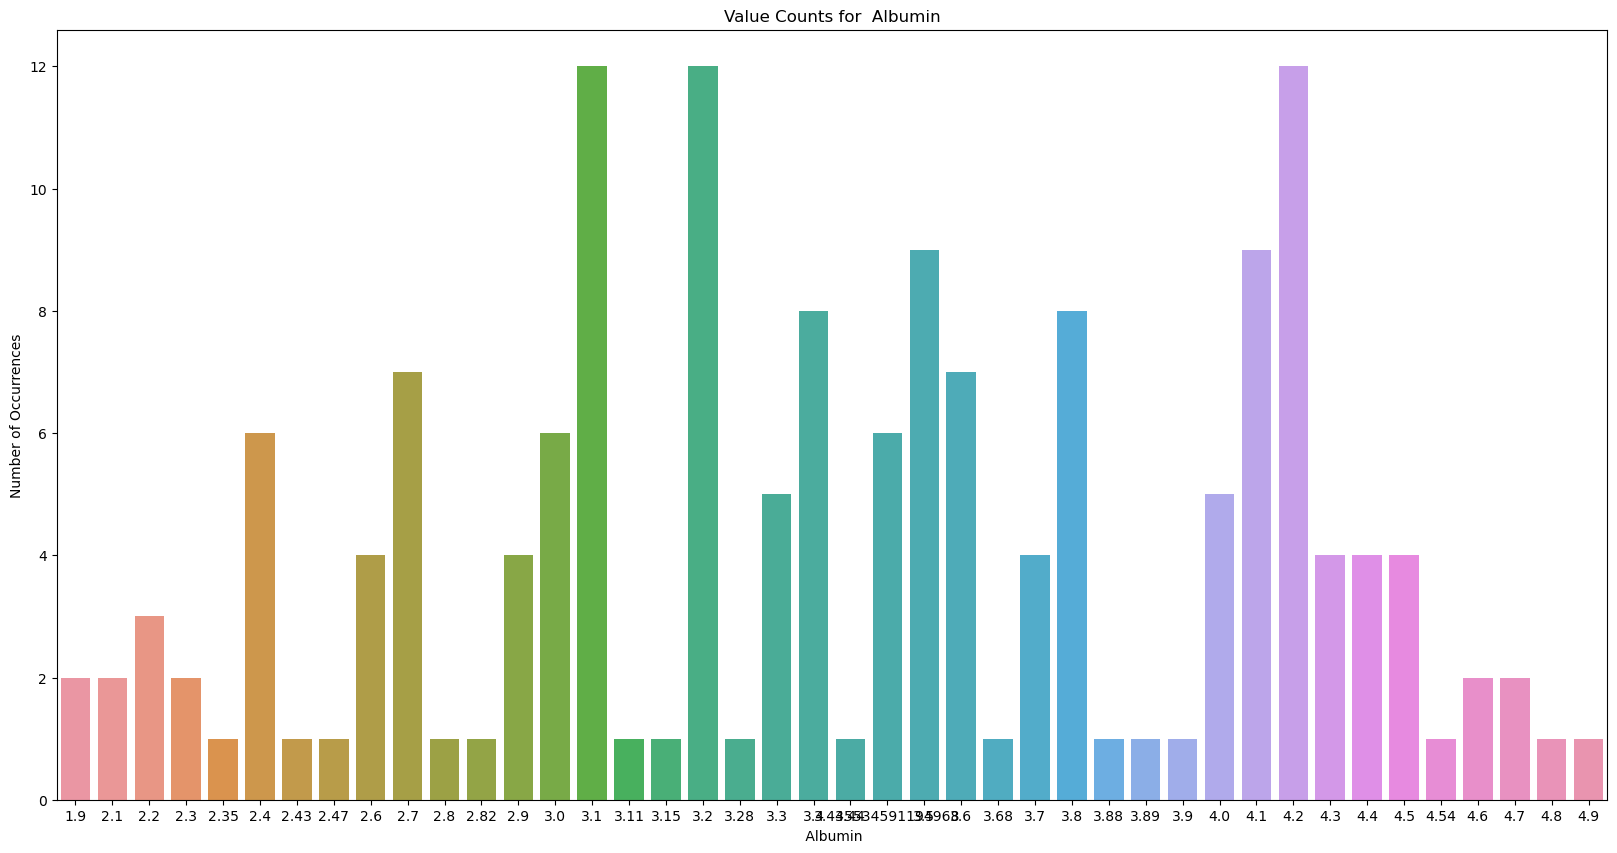

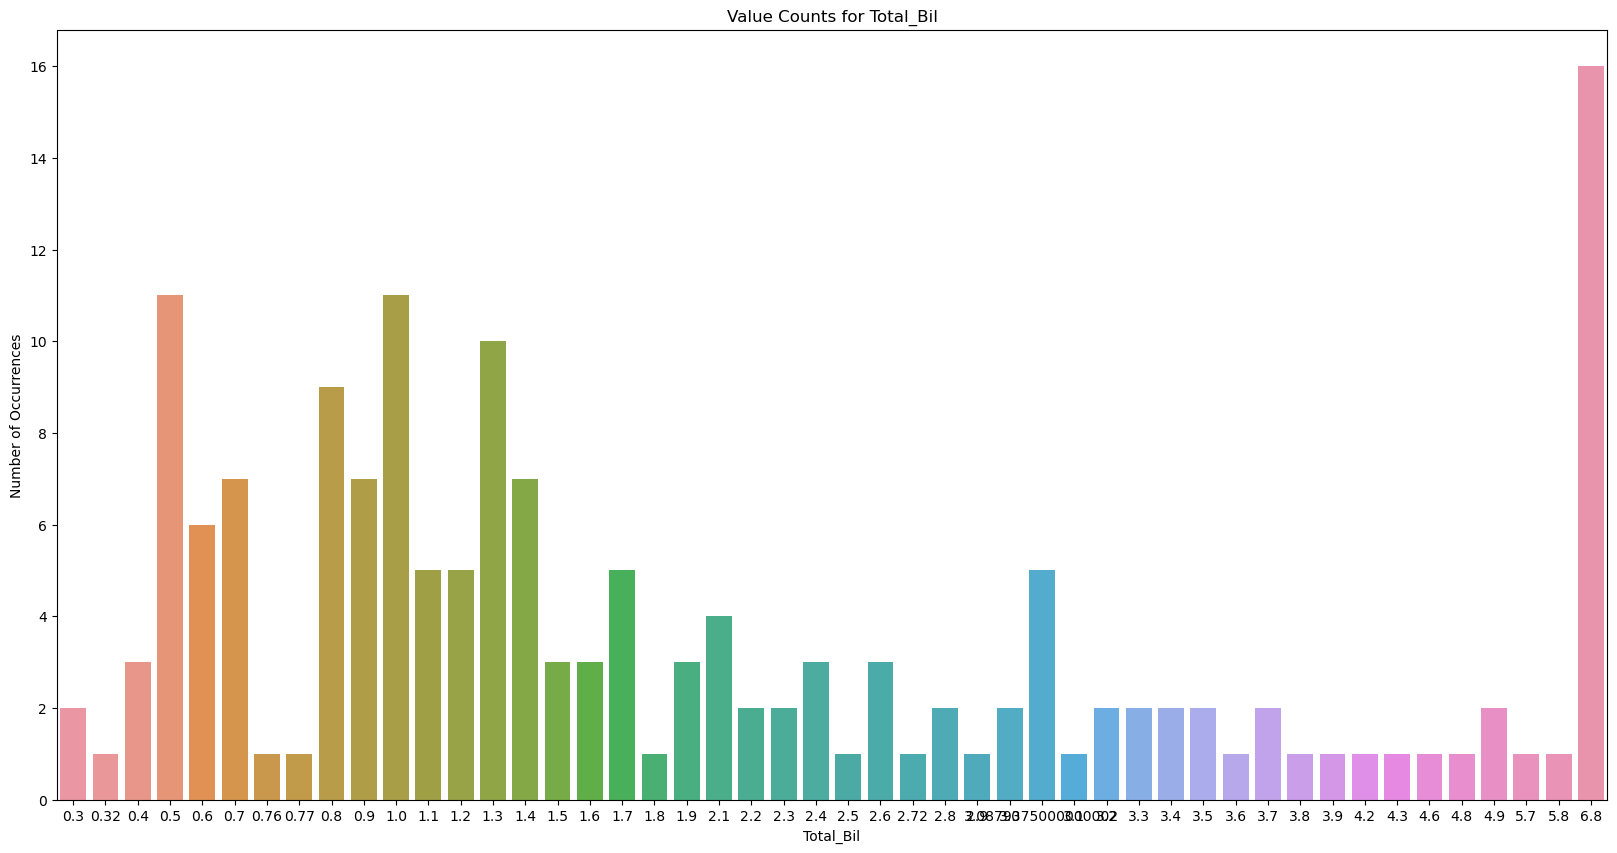

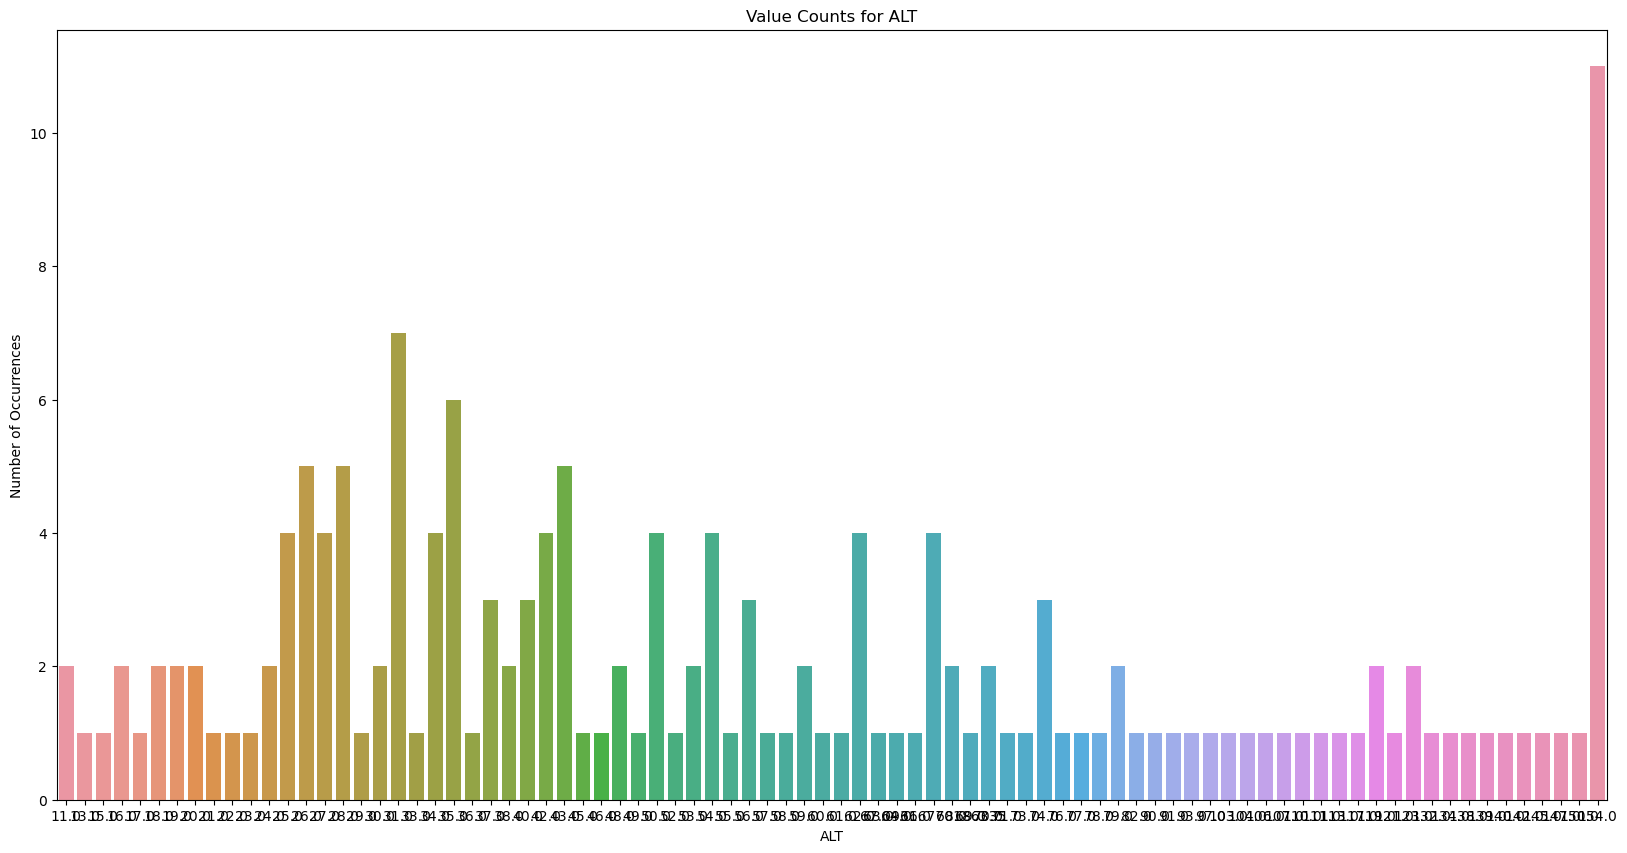

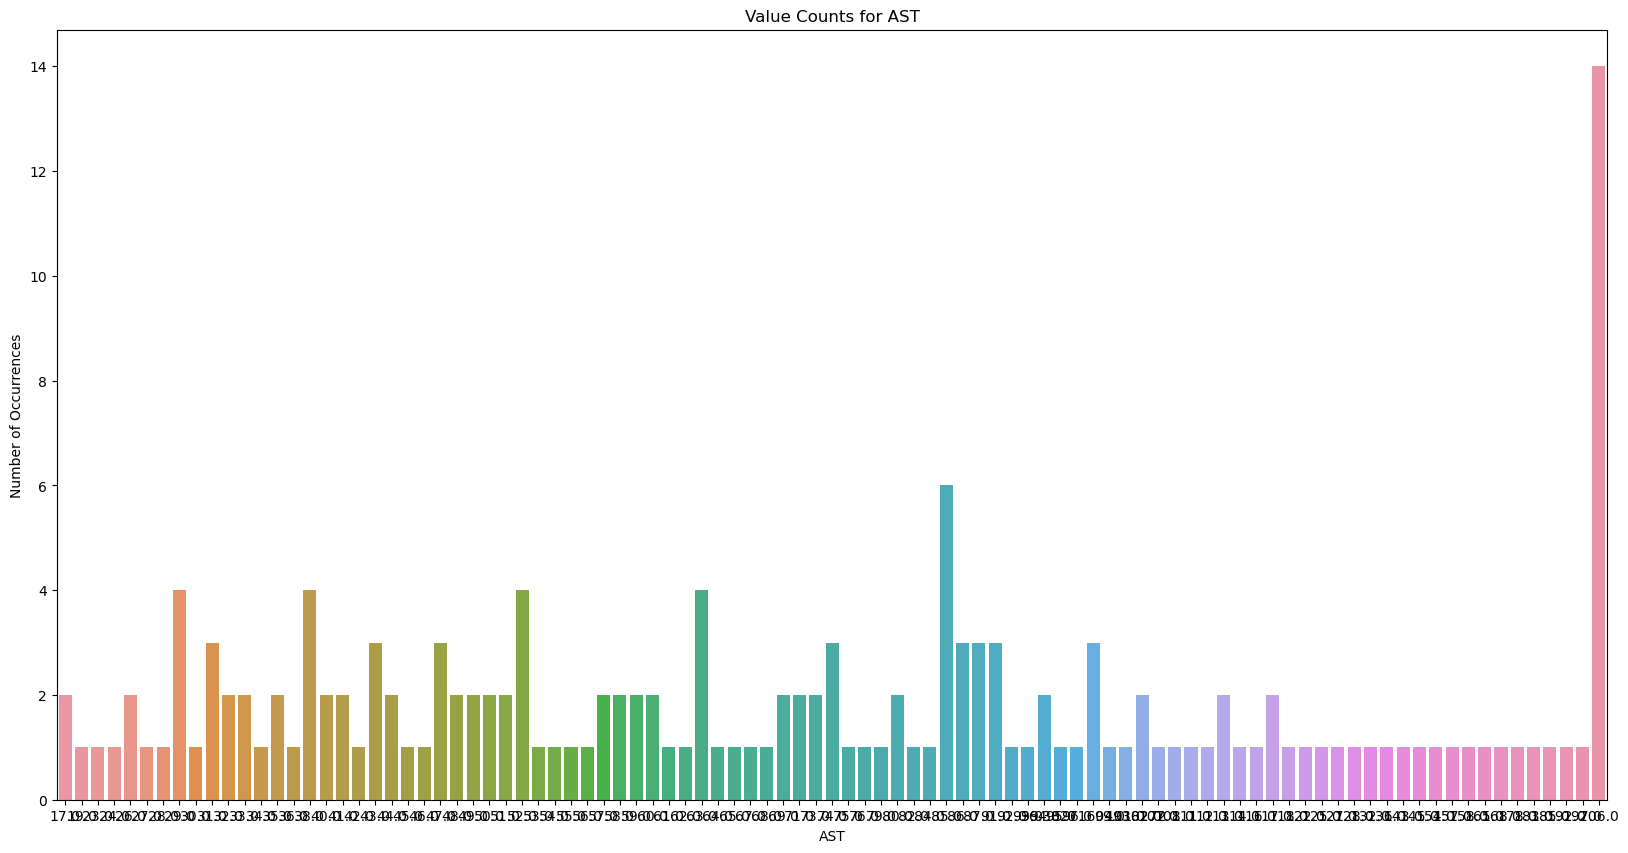

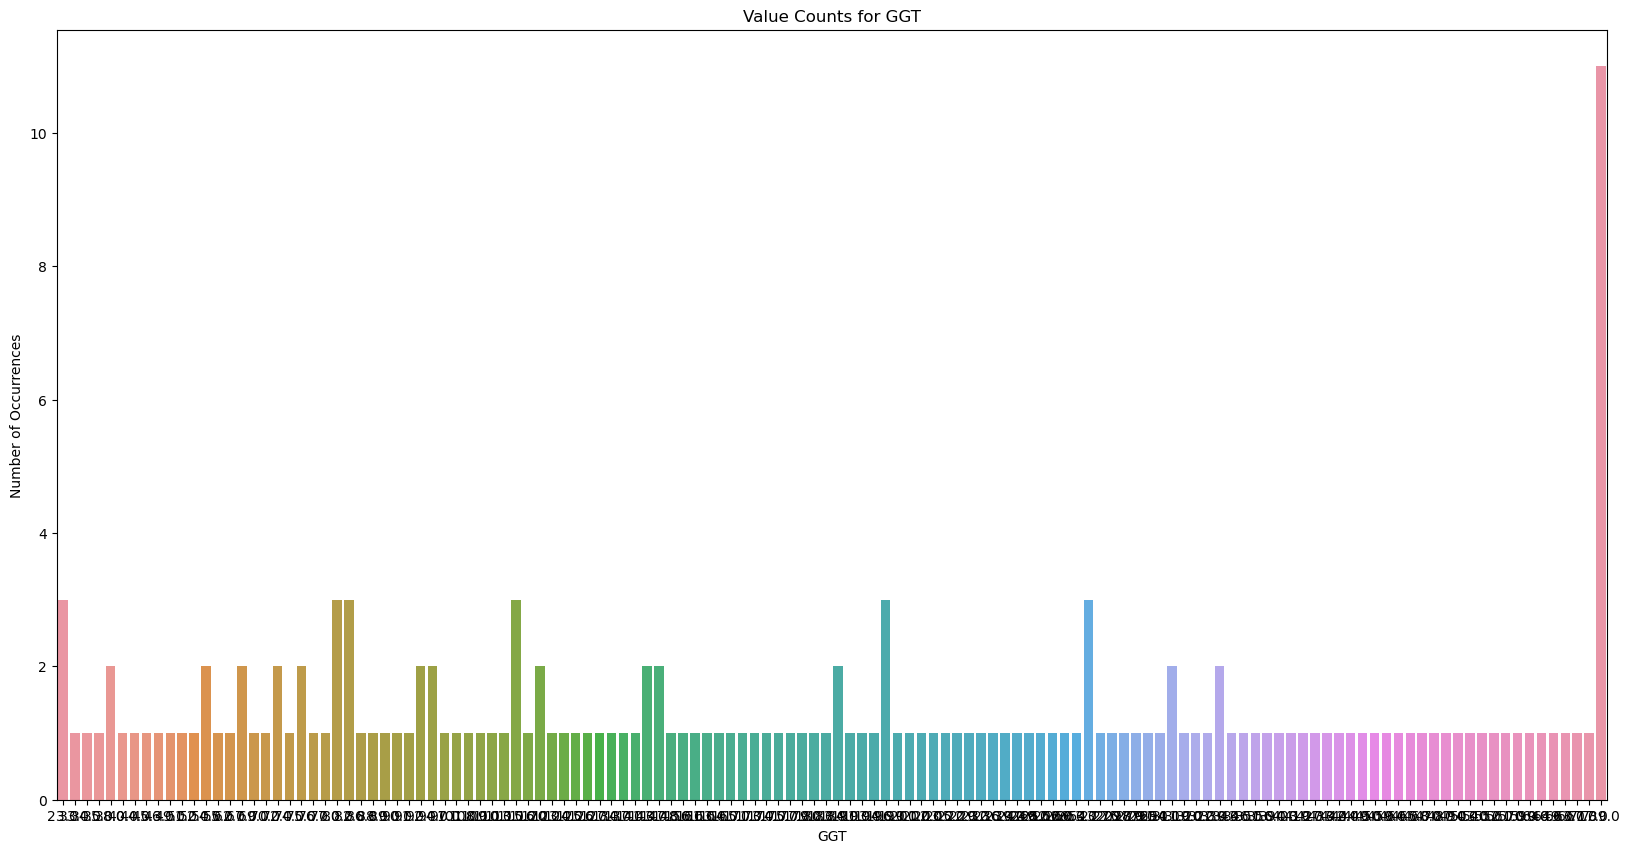

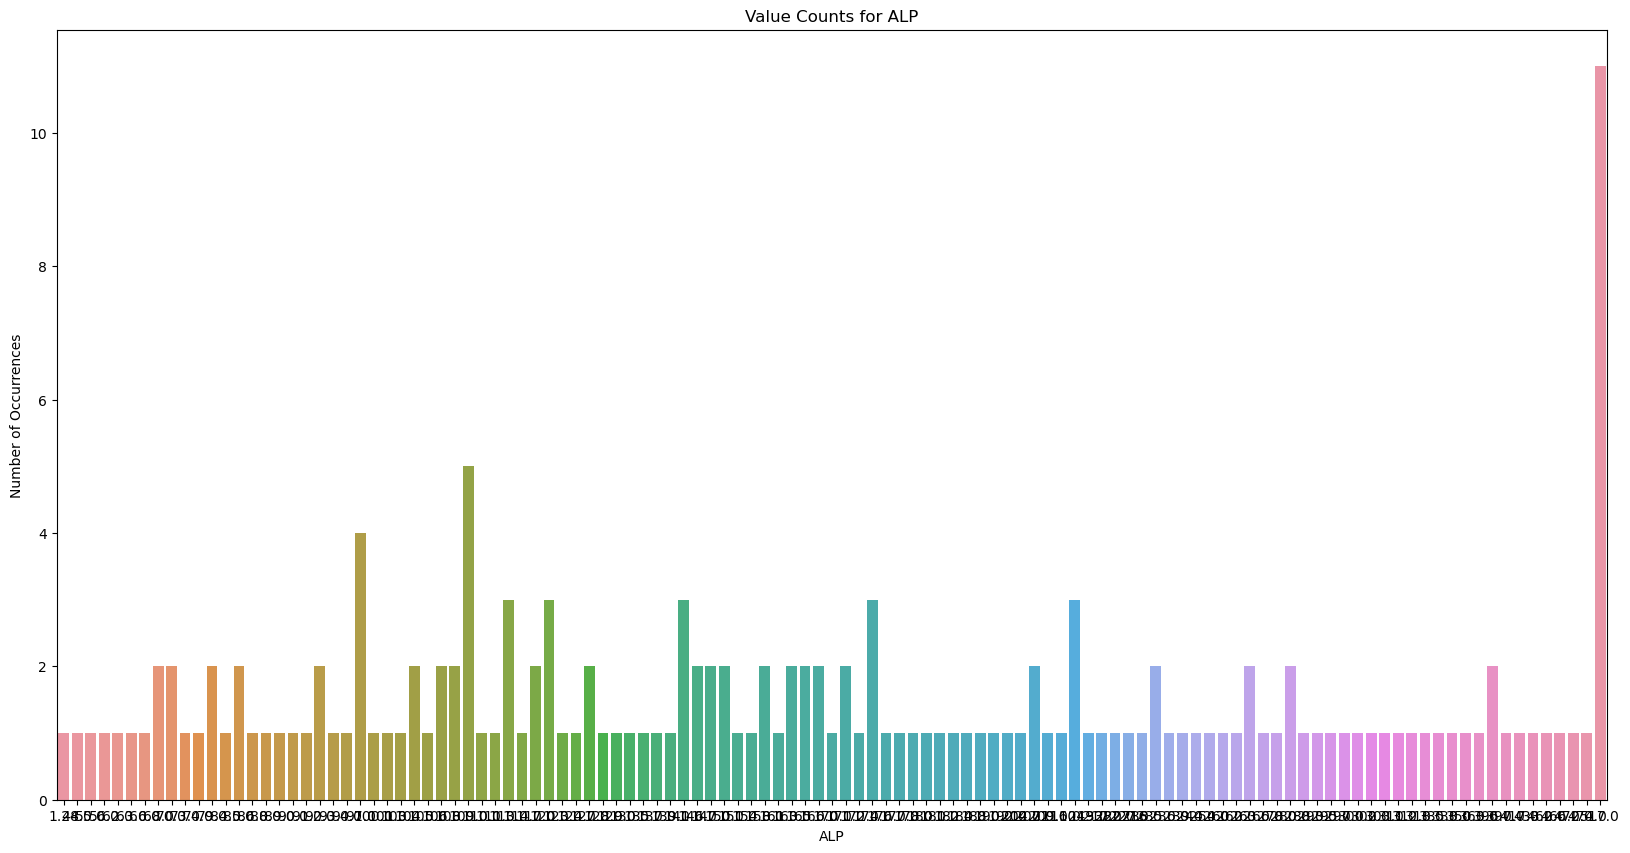

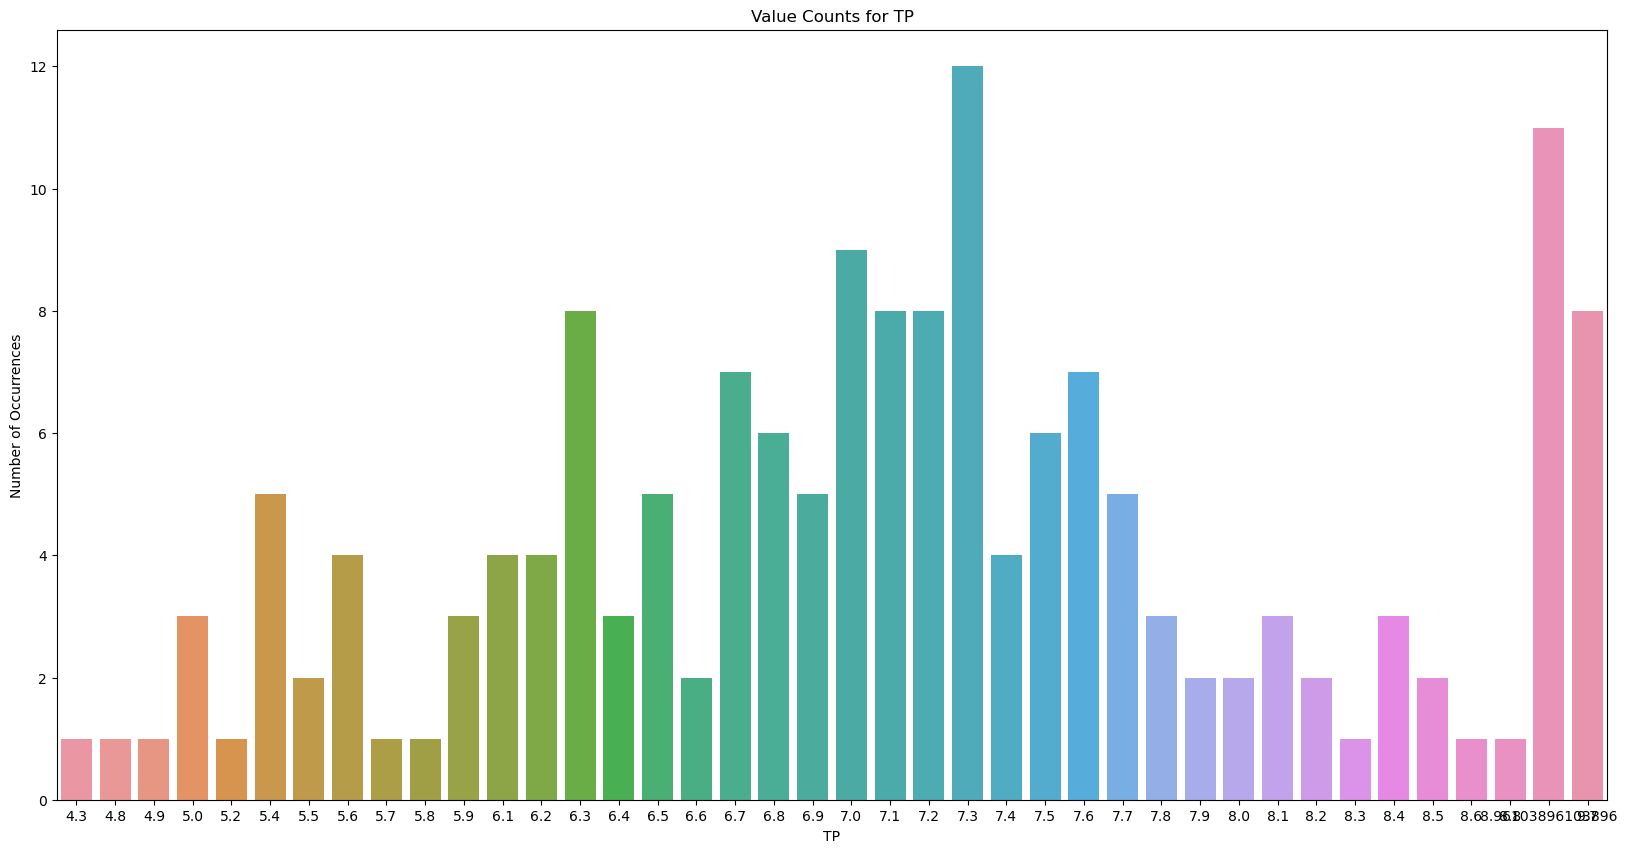

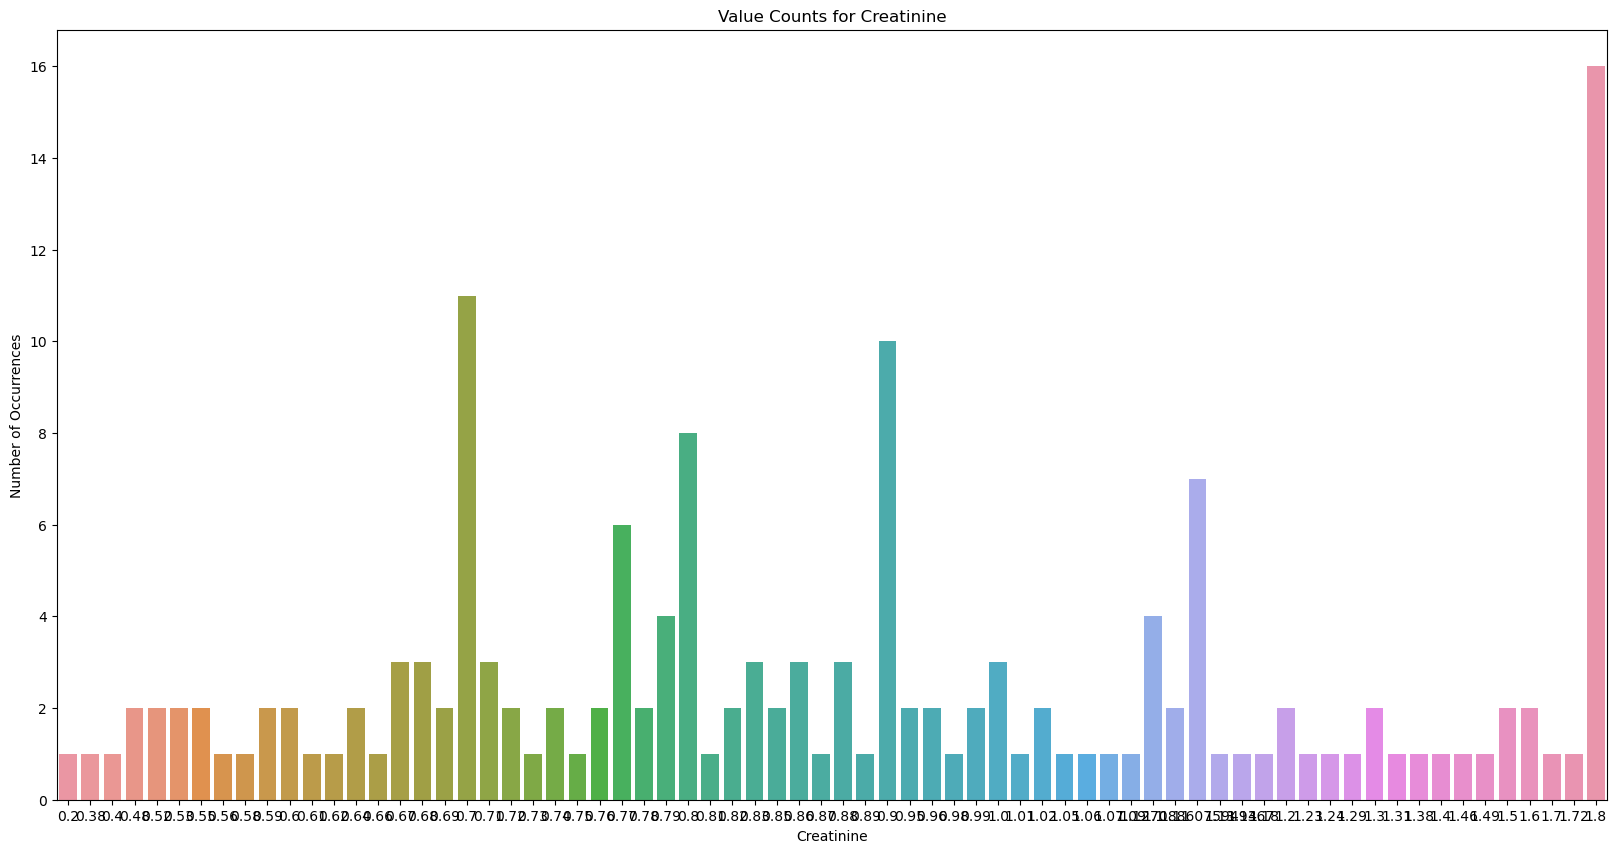

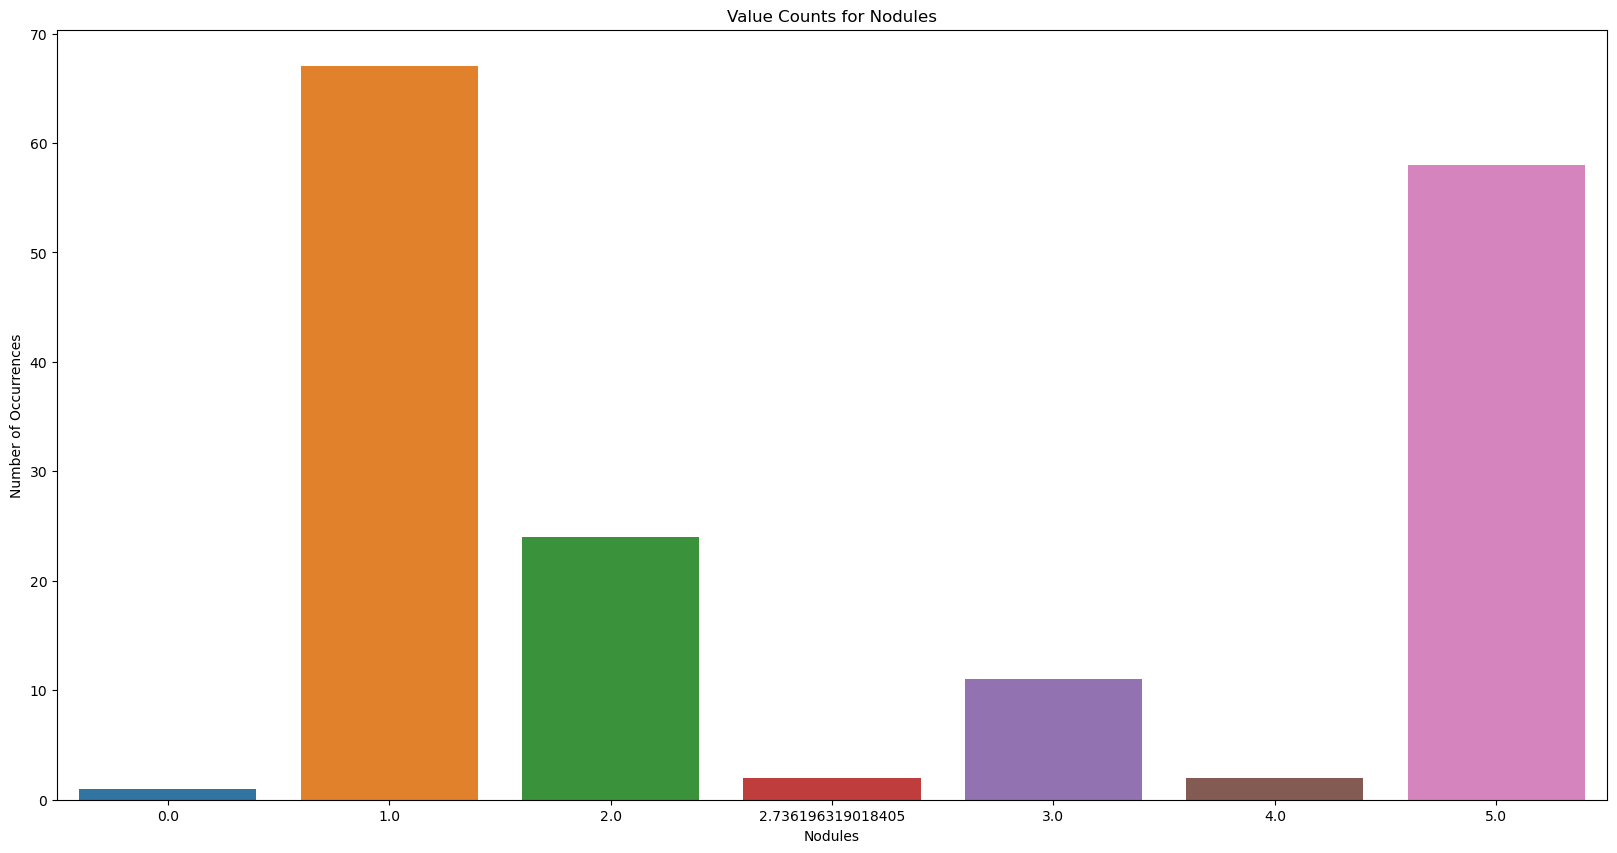

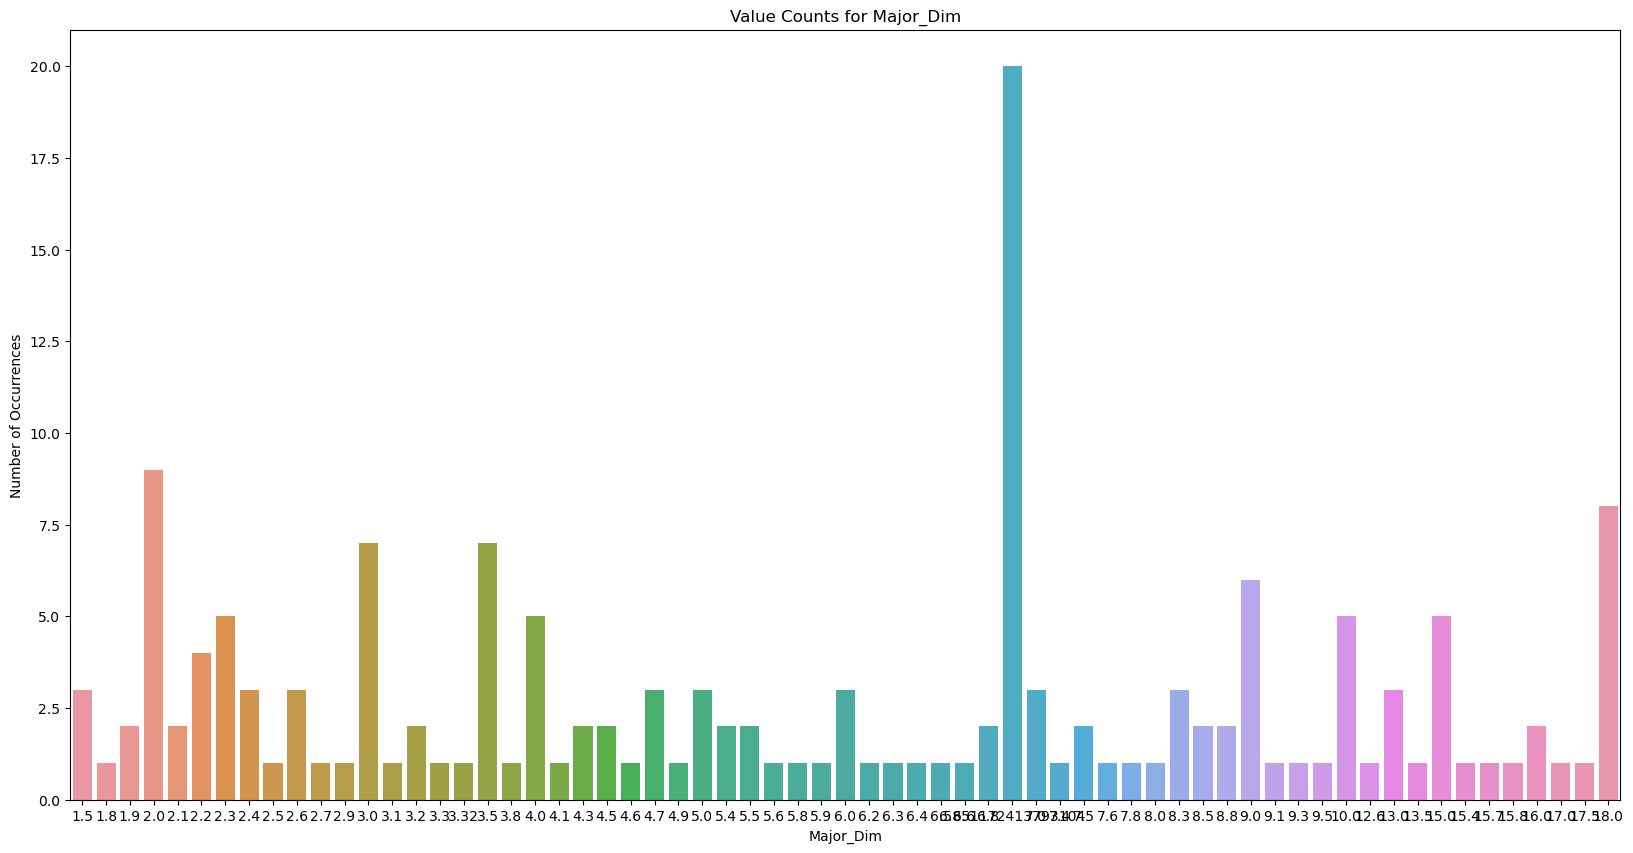

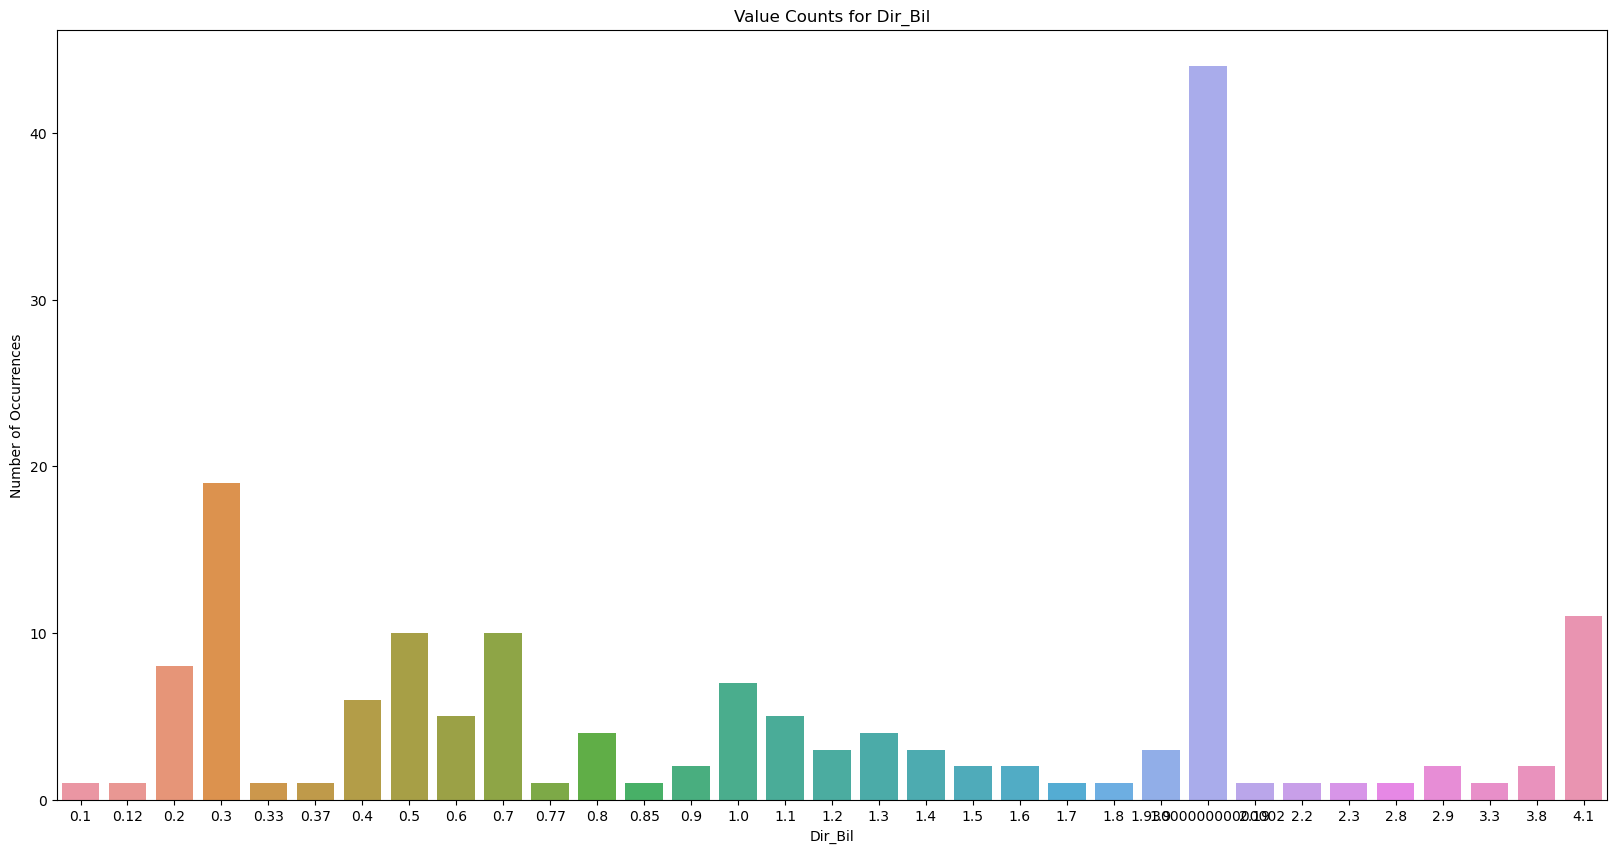

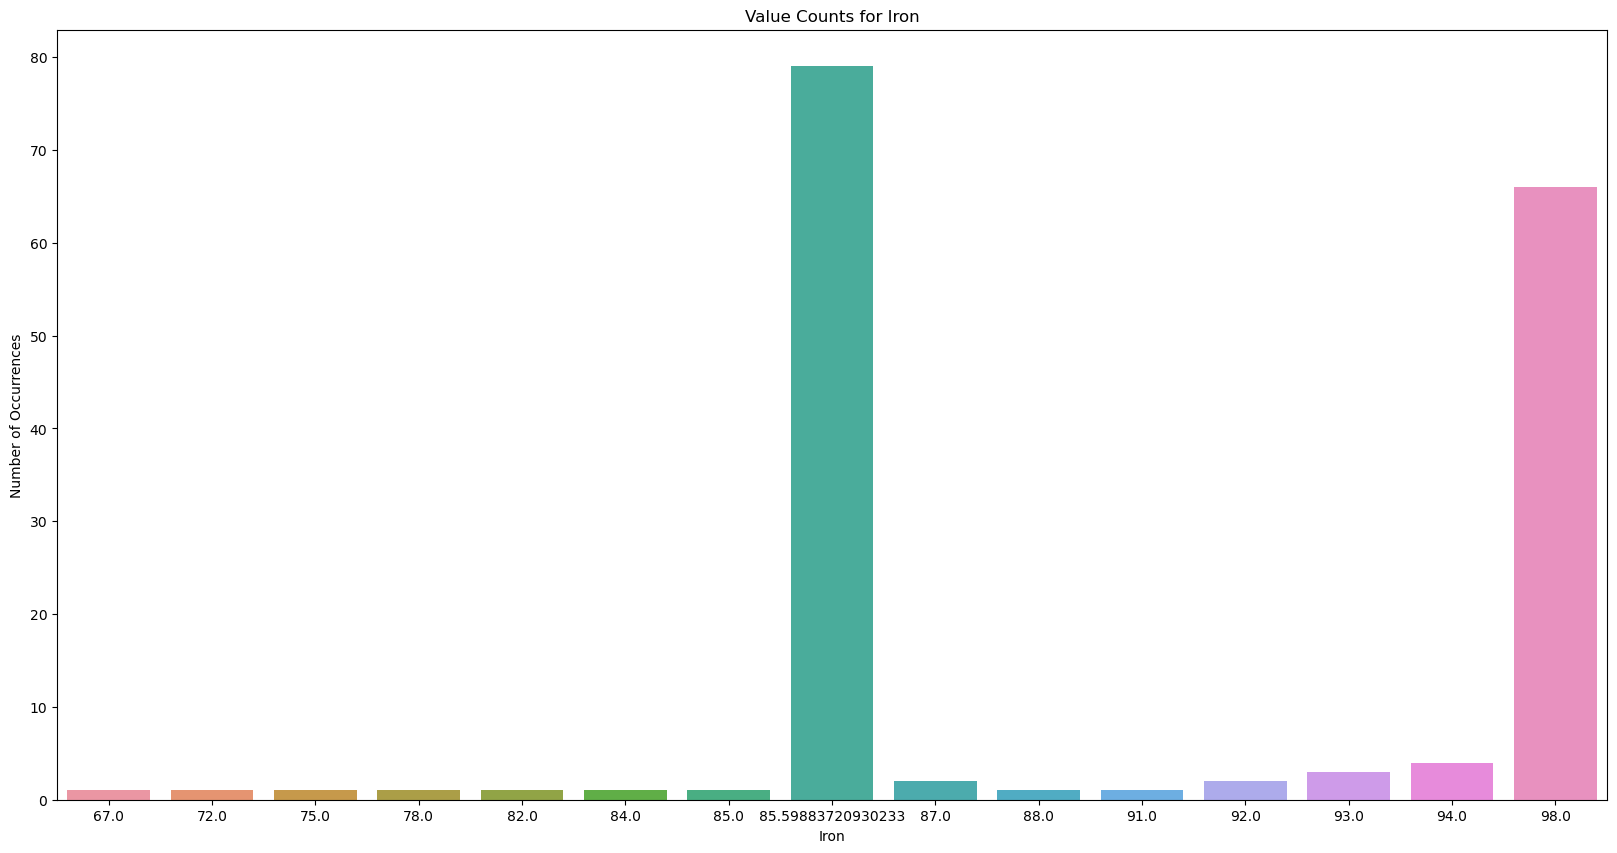

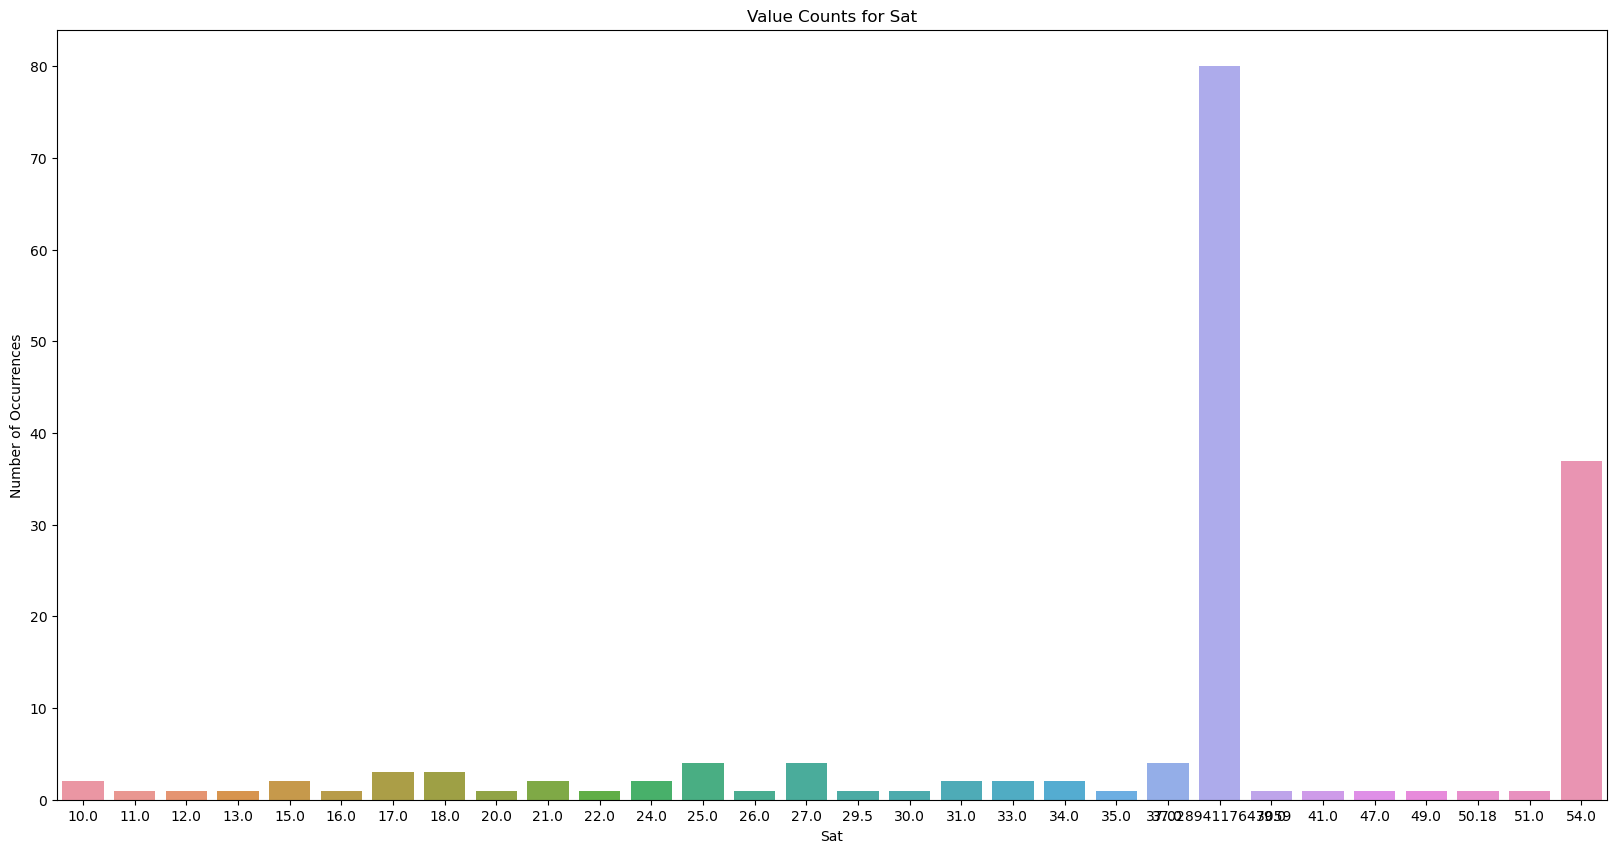

In [ ]:
def replace_outliers_with_max(df, column, mult):
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Calculate the lower and upper bounds
    lower_bound = Q1 - mult * IQR
    upper_bound = Q3 + mult * IQR
    
    # Identify the maximum value among the non-outliers
    max_non_outlier = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)][column].max()
    
    # Replace outliers with the maximum non-outlier value
    df.loc[df[column] > upper_bound, column] = max_non_outlier
    df.loc[df[column] < lower_bound, column] = max_non_outlier
    # Print the interval
    print(f"{column}:\n  Lower Bound: {lower_bound}\n  Upper Bound: {upper_bound}\n")
# Apply the function to each column in the DataFrame
for column in nf_clean.columns:
    replace_outliers_with_max(nf_clean, column, 1.75)

# Display the updated DataFrame
nf_clean.hist(figsize=(20,10), bins=60)

for column in nf_clean.columns:
    value_counts = nf_clean[column].value_counts().sort_index()

    # Plot the value counts
    plt.figure(figsize=(20, 10))
    sns.barplot(x=value_counts.index, y=value_counts.values)
    plt.title(f"Value Counts for {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Occurrences")
    plt.show()

In [ ]:
sf = pd.DataFrame(string_data)
sf = sf.replace("?",np.nan)

In [ ]:
for column in sf.columns:
    value_counts = sf[column].value_counts().sort_index()

    # Plot the value counts
    plt.figure(figsize=(25, 8))
    sns.barplot(x=value_counts.index, y=value_counts.values)
    plt.title(f"Value Counts for {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Occurrences")
    plt.show()

In [ ]:
def fill_missing_with_mode(df):
    for column in df.columns:
        mode_value = df[column].mode()[0]  # Get the most frequent value
        print(f"Mode of {column}: {mode_value}")
        df[column].fillna(mode_value, inplace=True)
sf_clean = copy.deepcopy(sf)
fill_missing_with_mode(sf_clean)


In [ ]:
for column in sf_clean.columns:
    value_counts = sf_clean[column].value_counts().sort_index()

    # Plot the value counts
    plt.figure(figsize=(12, 8))
    sns.barplot(x=value_counts.index, y=value_counts.values)
    plt.title(f"Value Counts for {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Occurrences")
    plt.show()

In [ ]:
patient_data_clean = pd.concat([nf_clean, sf_clean], axis=1)

In [ ]:
csv_file_path = 'patient_data_clean.csv'
patient_data_clean.to_csv(csv_file_path, index=False)

In [ ]:
data_for_test = patient_data_clean.copy()

In [ ]:
categorical_features = ['Gender', 'Symptoms', 'Alcohol', 'HBsAg', 'HBeAg', 'HBcAb', 'HCVAb', 'Cirrhosis', 'Endemic', 'Smoking', 'Diabetes', 'Obesity', 'Hemochro', 'AHT', 'CRI', 'HIV', 'NASH', 'Varices', 'Spleno', 'PHT', 'PVT', 'Metastasis', 'Hallmark', 'PS', 'Encephalopathy', 'Ascites']
numerical_features = ['Age', 'Grams_day', 'Packs_year', 'INR', 'AFP', 'Hemoglobin', 'MCV', 'Leucocytes', 'Platelets', 'Albumin', 'Total_Bil', 'ALT', 'AST', 'GGT', 'ALP', 'TP', 'Creatinine', 'Nodules', 'Major_Dim', 'Dir_Bil', 'Iron', 'Sat', 'Ferritin']
input_features = categorical_features + numerical_features
target_feature = 'Class'

In [ ]:
from sklearn.model_selection import train_test_split

x_bench = data_for_test[input_features]
y_bench = data_for_test[target_feature]
y_bench = y_bench.map({'Lives' : 1, 'Dies' : 0})

x_bench = pd.get_dummies(x_bench)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x_bench)
x_train_k = scaler.transform(x_bench)
x_test_k = scaler.transform(x_bench)

x_train_b, x_test_b, y_train_b, y_test_b = train_test_split(x_bench, y_bench, test_size=0.30, random_state=20)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(max_depth=10)
tree.fit(x_train_b, y_train_b)

In [ ]:
model_at_hand = tree

y_pred_b = model_at_hand.predict(x_test_b)

In [ ]:
from sklearn.metrics import classification_report
from sklearn.metrics import mean_absolute_error

print(classification_report(y_test_b, y_pred_b))
mae = mean_absolute_error(y_test_b, y_pred_b)
print("Mean Absolute Error:", mae)

from sklearn.datasets import make_classification
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from sklearn.svm import SVC
cm = confusion_matrix(y_test_b, y_pred_b)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
fpr, tpr, thresholds = roc_curve(y_test_b, y_pred_b)
roc_auc = roc_auc_score(y_test_b, y_pred_b)
print("AUC:", roc_auc)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

grid_model = DecisionTreeClassifier()

param_grid = {
    'max_depth': [10, 20, 30,],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2]
}
grid_search = GridSearchCV(estimator=grid_model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(x_train_b, y_train_b)
print(grid_search.best_params_)

In [ ]:
best_model = grid_search.best_estimator_
print(best_model)
y_pred_z = best_model.predict(x_test_b)

In [ ]:
mae = mean_absolute_error(y_test_b, y_pred_z)
print(classification_report(y_test_b, y_pred_z))
print("Mean Absolute Error:", mae)
cm = confusion_matrix(y_test_b, y_pred_z)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
fpr, tpr, thresholds = roc_curve(y_test_b, y_pred_z)
roc_auc = roc_auc_score(y_test_b, y_pred_z)
print("AUC:", roc_auc)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
x_train_k, x_test_k, y_train_k, y_test_k = train_test_split(x_bench, y_bench, test_size=0.33, random_state=20)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=3)
classifier.fit(x_train_k, y_train_k)

In [ ]:
y_pred_k = classifier.predict(x_test_k)

In [ ]:
print(classification_report(y_test_k, y_pred_k))
mae = mean_absolute_error(y_test_k, y_pred_k)
print("Mean Absolute Error:", mae)
cm = confusion_matrix(y_test_k, y_pred_k)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
fpr, tpr, thresholds = roc_curve(y_test_k, y_pred_k)
roc_auc = roc_auc_score(y_test_k, y_pred_k)
print("AUC:", roc_auc)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

x_train_g, x_test_g, y_train_g, y_test_g = train_test_split(x_bench, y_bench, test_size=0.33, random_state=20)

gboost = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42)
gboost.fit(x_train_g, y_train_g)

In [ ]:
y_pred_g = gboost.predict(x_test_g)

print(classification_report(y_test_g, y_pred_g))
mae = mean_absolute_error(y_test_g, y_pred_g)
print("Mean Absolute Error:", mae)
cm = confusion_matrix(y_test_g, y_pred_g)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
fpr, tpr, thresholds = roc_curve(y_test_g, y_pred_g)
roc_auc = roc_auc_score(y_test_g, y_pred_g)
print("AUC:", roc_auc)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rforest = RandomForestClassifier(n_estimators=100, random_state=42)

x_train_r, x_test_r, y_train_r, y_test_r = train_test_split(x_bench, y_bench, test_size=0.33, random_state=20)

rforest.fit(x_train_r, y_train_r)

y_pred_r = rforest.predict(x_test_r)

In [ ]:
print(classification_report(y_test_r, y_pred_r))
mae = mean_absolute_error(y_test_r, y_pred_r)
print("Mean Absolute Error:", mae)
cm = confusion_matrix(y_test_r, y_pred_r)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
fpr, tpr, thresholds = roc_curve(y_test_r, y_pred_r)
roc_auc = roc_auc_score(y_test_r, y_pred_r)
print("AUC:", roc_auc)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()